In [8]:
import pandas as pd
import os

current_dir = os.path.abspath('.')
root_dir = os.path.dirname(current_dir) 
file_path = os.path.join(root_dir, 'data', 'default of credit card clients.csv')
    
# Charger le CSV dans un DataFrame
df = pd.read_csv(file_path)


In [9]:
df = df.set_index('ID')
print(df.columns.tolist())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm']


In [10]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [11]:
import pandas as pd
import numpy as np

# --- CONFIGURATION ---
THRESHOLD = 1_000_000
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']

# 1. FILTRAGE DES LIGNES
mask_large_payment = df[payment_columns].ge(THRESHOLD).any(axis=1)
df_large_payments = df[mask_large_payment].copy()

print(f"--- RÉSULTATS ---")
print(f"Nombre total de lignes avec au moins un paiement >= {THRESHOLD:,} : {len(df_large_payments)}")

if len(df_large_payments) == 0:
    print("Aucune ligne trouvée. Vérifie l'échelle de tes données.")
else:
    # 2. AFFICHAGE CLASSIQUE (sans .T)
    print(f"\n--- Exemple de 10 lignes (format classique) ---")
    
    # On peut limiter le nombre de colonnes affichées si le dataframe est très large
    # Sinon, pandas l'affichera tel quel
    print(df_large_payments.head(10))


--- RÉSULTATS ---
Nombre total de lignes avec au moins un paiement >= 1,000,000 : 4

--- Exemple de 10 lignes (format classique) ---
       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  \
ID                                                                            
5297      500000    2          1         1   33     -2     -2     -1     -1   
25732      80000    2          3         1   37      0      0     -2     -2   
28004     510000    2          1         2   30     -1     -1     -1     -1   
28717     340000    2          1         3   42     -1     -1     -1     -1   

       PAY_5  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  \
ID            ...                                                        
5297      -2  ...     121757      97115     377217      4366   1684259   
25732     -2  ...        632        632     124542       215   1024516   
28004      0  ...     163628     117475     116656    493358   1227082   
28717     -1  ...     

Les paiements de +1M semblent incohérents avec leur contexte, les cartes voient leur plafond exploser.  
Même si ces 4 lignes seront un bruit imperceptibles pour les modèles, les répartitions et stats sont complètement déformées par ces anomalies.  
En terme de métier, il n'est pas impossible de dépasser le plafond maximum d'une carte de crédit d'un certain pourcentage, mais ici, on parle de plusieurs fois le plafond autorisé

In [12]:
import pandas as pd
import numpy as np

# --- CONFIGURATION ---
THRESHOLD = 500000
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']

# 1. FILTRAGE DES LIGNES
mask_large_payment = df[payment_columns].ge(THRESHOLD).any(axis=1)
df_large_payments = df[mask_large_payment].copy()

print(f"--- RÉSULTATS ---")
print(f"Nombre total de lignes avec au moins un paiement >= {THRESHOLD:,} : {len(df_large_payments)}")

if len(df_large_payments) == 0:
    print("Aucune ligne trouvée. Vérifie l'échelle de tes données.")
else:
    # 2. AFFICHAGE CLASSIQUE (sans .T)
    print(f"\n--- Exemple de 10 lignes (format classique) ---")
    
    # On peut limiter le nombre de colonnes affichées si le dataframe est très large
    # Sinon, pandas l'affichera tel quel
    print(df_large_payments.head(10))


--- RÉSULTATS ---
Nombre total de lignes avec au moins un paiement >= 500,000 : 9

--- Exemple de 10 lignes (format classique) ---
       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  \
ID                                                                            
2198     1000000    2          1         1   47      0      0      0     -1   
5297      500000    2          1         1   33     -2     -2     -1     -1   
12331     300000    1          2         1   37      1     -1      2      0   
14514     460000    2          1         1   43     -2     -2     -1      0   
24687     730000    1          2         1   37      0      0      0      0   
25732      80000    2          3         1   37      0      0     -2     -2   
27441     500000    1          1         1   35      2      0      0     -1   
28004     510000    2          1         2   30     -1     -1     -1     -1   
28717     340000    2          1         3   42     -1     -1     -1     -1   


Pour les paiements à +500 000 NT$, le constat est plus mitigé pour les lignes entre 500 00 et 1 000 000
**=> les montants de +1M nT$ ressemblent fortement à des anomalies, je supprime ces 4 lignes

In [13]:
import pandas as pd
import numpy as np

# 1. Définition des colonnes à filtrer
cols_pay = [f'PAY_AMT{i}' for i in range(1, 7)]
# Filtrer pour ne garder que celles qui existent dans le dataframe
cols_presentes = [c for c in cols_pay if c in df.columns]

if len(cols_presentes) > 0:
    # Seuil de suppression
    seuil_suppression = 1_000_000
    
    # 2. Identification des lignes à supprimer
    # On crée un masque qui est True si AU MOINS une colonne PAY_AMT dépasse le seuil
    is_outlier = False
    for col in cols_presentes:
        is_outlier = is_outlier | (df[col] > seuil_suppression)
        
    nb_lignes_avant = len(df)
    
    # 3. Suppression
    df_cleaned = df[~is_outlier].copy()
    nb_lignes_apres = len(df_cleaned)
    nb_supprimees = nb_lignes_avant - nb_lignes_apres
    
    print(f"--- Nettoyage des Paiements Anormaux (> 1M) ---")
    print(f"Lignes avant : {nb_lignes_avant}")
    print(f"Lignes supprimées : {nb_supprimees} ({(nb_supprimees/nb_lignes_avant)*100:.2f}%)")
    print(f"Lignes restantes : {nb_lignes_apres}")

    # Affichage des colonnes concernées pour vérifier qu'elles ont bien été nettoyées
    print("\nValeurs max par colonne PAY_AMT après nettoyage :")
    for col in cols_presentes:
        if col in df_cleaned.columns:
            print(f"{col}: {df_cleaned[col].max()}")

else:
    print("Aucune colonne PAY_AMT trouvée.")

df = df_cleaned

--- Nettoyage des Paiements Anormaux (> 1M) ---
Lignes avant : 30000
Lignes supprimées : 4 (0.01%)
Lignes restantes : 29996

Valeurs max par colonne PAY_AMT après nettoyage :
PAY_AMT1: 505000
PAY_AMT2: 580464
PAY_AMT3: 896040
PAY_AMT4: 528897
PAY_AMT5: 426529
PAY_AMT6: 528666


In [14]:
import pandas as pd

# 1. Définir les colonnes de montants payés
cols_paiements = [f'PAY_AMT{i}' for i in range(1, 7)]

# 2. Calculer le seuil : 2.1 fois la LIMIT_BAL pour chaque ligne (chaque client)
seuil_ridicule = df['LIMIT_BAL'] * 2.1

# 3. Créer un mask booléen : True si au moins un paiement dépasse ce seuil
# axis=1 signifie "par ligne"
mask_lignes_incohérentes = df[cols_paiements].ge(seuil_ridicule, axis=0).any(axis=1)

# 4. Extraire et compter ces lignes
lignes_incohérentes = df[mask_lignes_incohérentes]
nombre_lignes_incohérentes = len(lignes_incohérentes)

print(f"Nombre de lignes potentiellement incohérentes pour une limite à 2.1 x le plafond: {nombre_lignes_incohérentes}")

# 5. Visualisation rapide pour vérifier les valeurs
if nombre_lignes_incohérentes > 0:
    # On affiche les clients problématiques avec leurs montants pour inspection
    display(lignes_incohérentes[['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm']].head())
    
    # 2. Calculer le seuil : 2.1 fois la LIMIT_BAL pour chaque ligne (chaque client)
seuil_ridicule = df['LIMIT_BAL'] * 1.2

# 3. Créer un mask booléen : True si au moins un paiement dépasse ce seuil
# axis=1 signifie "par ligne"
mask_lignes_incohérentes = df[cols_paiements].ge(seuil_ridicule, axis=0).any(axis=1)

# 4. Extraire et compter ces lignes
lignes_incohérentes = df[mask_lignes_incohérentes]
nombre_lignes_incohérentes = len(lignes_incohérentes)

print(f"Nombre de lignes potentiellement incohérentes pour une limite à 1.2 x le plafond: {nombre_lignes_incohérentes}")

# 5. Visualisation rapide pour vérifier les valeurs
if nombre_lignes_incohérentes > 0:
    # On affiche les clients problématiques avec leurs montants pour inspection
    display(lignes_incohérentes[['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm']].head())
    
    # 2. Calculer le seuil : 2.1 fois la LIMIT_BAL pour chaque ligne (chaque client)
seuil_ridicule = df['LIMIT_BAL'] * 5

# 3. Créer un mask booléen : True si au moins un paiement dépasse ce seuil
# axis=1 signifie "par ligne"
mask_lignes_incohérentes = df[cols_paiements].ge(seuil_ridicule, axis=0).any(axis=1)

# 4. Extraire et compter ces lignes
lignes_incohérentes = df[mask_lignes_incohérentes]
nombre_lignes_incohérentes = len(lignes_incohérentes)

print(f"Nombre de lignes potentiellement incohérentes pour une limite à 5 x le plafond: {nombre_lignes_incohérentes}")

# 5. Visualisation rapide pour vérifier les valeurs
if nombre_lignes_incohérentes > 0:
    # On affiche les clients problématiques avec leurs montants pour inspection
    display(lignes_incohérentes[['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm']].head())

Nombre de lignes potentiellement incohérentes pour une limite à 2.1 x le plafond: 12


,LIMIT_BAL,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,
3554,40000,32228,38904,4235,87230,72647,65070,8040,4235,87230,3000,10000,4317,0
5844,10000,885,1475,780,390,780,390,1475,780,0,31250,0,0,0
7419,20000,-1213,30322,20033,19871,15410,18969,52082,15800,2000,20085,39070,25000,0
7640,20000,-739,-5978,16089,14457,20106,10258,0,42400,289,201,410,0,1
7667,20000,34213,30100,25871,21970,18669,19669,0,0,0,0,1000,53301,1


Nombre de lignes potentiellement incohérentes pour une limite à 1.2 x le plafond: 78


,LIMIT_BAL,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,
291,280000,898,898,325,898,325,-339603,898,325,898,325,0,345293,1
991,50000,58300,59727,142,29886,30510,31276,7876,161,74354,927,1089,9100,0
1740,20000,15789,21698,21054,20355,19980,3470,6500,0,0,10000,25065,177,0
1844,20000,18803,18376,19342,19081,19799,18718,36147,1281,658,1000,1000,760,1
3184,260000,200716,203751,205530,-170000,171696,174151,8812,9158,0,497000,10000,7000,0


Nombre de lignes potentiellement incohérentes pour une limite à 5 x le plafond: 0


In [15]:
import pandas as pd

# 1. Définition des colonnes concernées
cols_bill = [f'BILL_AMT{i}' for i in range(1, 7)]
col_plafond = 'LIMIT_BAL'

# Filtrer pour ne garder que les colonnes présentes dans le dataframe
cols_presentes = [c for c in cols_bill if c in df.columns]

if col_plafond not in df.columns:
    print(f"Attention : La colonne '{col_plafond}' est manquante.")
elif len(cols_presentes) == 0:
    print(f"Attention : Aucune colonne BILL_AMT trouvée.")
else:
    # 2. Calcul du seuil par ligne (2.1 * LIMIT_BAL)
    # On filtre d'abord les plafonds valides (> 0) pour éviter les divisions/errements logiques
    df_valide = df[df[col_plafond] > 0].copy()
    
    if len(df_valide) == 0:
        print("Aucune limite de crédit valide trouvée.")
    else:
        # On identifie les lignes où AU MOINS UN des BILL_AMT dépasse le seuil
        is_outlier = False
        for col in cols_presentes:
            # Condition : Valeur > 2.1 * LIMIT_BAL
            is_outlier = is_outlier | (df_valide[col] > (2.1 * df_valide[col_plafond]))
        
        # On ajoute la colonne 'Is_Outlier' au dataframe pour analyse détaillée si besoin
        df_valide['Depasse_Plafond_X2.1'] = is_outlier
        
        # 3. Comptage
        nb_lignes_totales = len(df)
        nb_depassements = is_outlier.sum()
        
        print(f"--- Analyse de Dépassement de Plafond ---")
        print(f"Total lignes dans le dataset : {nb_lignes_totales}")
        print(f"Lignes avec AU MOINS un BILL_AMT > 2.1 * LIMIT_BAL : {nb_depassements}")
        
        if nb_lignes_totales > 0:
            pourcentage = (nb_depassements / nb_lignes_totales) * 100
            print(f"Pourcentage de la population concernée : {pourcentage:.2f}%")

    # Optionnel : Afficher un échantillon des cas extrêmes pour vérifier leur nature
    if nb_depassements > 0:
        df_extremes = df_valide[(df_valide['Depasse_Plafond_X2.1'])].head(10)
        print("\nExemple de lignes dépassant le seuil (10 premiers cas) :")
        print(df_extremes.to_string())

--- Analyse de Dépassement de Plafond ---
Total lignes dans le dataset : 29996
Lignes avec AU MOINS un BILL_AMT > 2.1 * LIMIT_BAL : 40
Pourcentage de la population concernée : 0.13%

Exemple de lignes dépassant le seuil (10 premiers cas) :
      LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  dpnm  Depasse_Plafond_X2.1
ID                                                                                                                                                                                                                                                
671       30000    2          2         2   34      2     -1      2      2      2      2      99568      32326      31840      37075      37662      36904     33000     33000      5810      1325         0      3095     0                  True
969       20000    2          2

Dans le domaine des crédits renouvelables, il est rare de dépasser son plafond de plus de 100% mais c'est possible. Ce qui est compliqué, c'est de dépasser 120% du plafond.  Les valeurs supérieures à cette limite sont probablement erronnées.  
Cependant dans ce dataset, on voit des clients payer en avance, des décalages de comptabilisation dans les paiements, des clients qui remboursent intégralement leur carte chaque mois ; alors la limite de 120% (dépassée pour 78 clients) devient sévère.  
Fixer une limite raisonnable à 2 fois la limite en ajoutant une petite marge sécurise sur le nettoyage et garantit de vraiment éliminer les lignes contenant des erreurs de type (montant compté x 100, montants saisis plusieurs fois par erreur).  La seule explication à ceci serait un abaissement du plafond sur la période mais il est impossible d'avoir la moindre information sur la temporalité de ce montant maximum autorisé.  
L'analyse des lignes ne montre pas d'aberrations dans les montants
Si j'applique le même filtre sur les encours et que j'observe un échantillon de quelques lignes, je ne détecte pas d'anormalité de comportement dans les paiements et les encours utilisés, on remarque en effet une envolée de l'encours mais rien n'indique une erreur de montant. Supprimer ces lignes de fort dépassement du plafong supprimerait une catégorie de clients non justifiée ici.  
La raison la plus probable ici semble être une baisse du plafond autorisé.  
=> **je ne nettoie pas ces lignes qui ne présentent pas suffisamment d'anomalies**

In [16]:
# Créer la liste des colonnes à analyser
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== ANALYSE DES RETARDS DE PAIEMENT ===")

# Analyser chaque colonne de paiement
results = {}
total_records = len(df)

for col in pay_columns:
    # Compter les valeurs strictement inférieures à -1
    count_less_than_neg1 = (df[col] < -1).sum()
    percentage_less_than_neg1 = (count_less_than_neg1 / total_records) * 100
    
    # Compter les valeurs égales à 0
    count_zeros = (df[col] == 0).sum()
    percentage_zeros = (count_zeros / total_records) * 100
    
    # Statistiques générales
    min_val = df[col].min()
    max_val = df[col].max()
    mean_val = df[col].mean()
    
    results[col] = {
        'count_less_than_neg1': count_less_than_neg1,
        'percentage_less_than_neg1': percentage_less_than_neg1,
        'count_zeros': count_zeros,
        'percentage_zeros': percentage_zeros,
        'min': min_val,
        'max': max_val,
        'mean': mean_val
    }
    
    print(f"\n{col}:")
    print(f"  - Nombre de valeurs < -1: {count_less_than_neg1}")
    print(f"  - Pourcentage < -1: {percentage_less_than_neg1:.2f}%")
    print(f"  - Nombre de valeurs = 0: {count_zeros}")
    print(f"  - Pourcentage = 0: {percentage_zeros:.2f}%")
    print(f"  - Valeur minimale: {min_val}")
    print(f"  - Valeur maximale: {max_val}")
    print(f"  - Moyenne: {mean_val:.2f}")
    
    # Afficher quelques exemples de valeurs < -1
    if count_less_than_neg1 > 0:
        negative_values = df[df[col] < -1][col].head()
        print(f"  - Exemples (< -1): {negative_values.tolist()}")

print("\n=== ANALYSE SPÉCIFIQUE ===")
print("Nombre de valeurs strictement inférieures à -1 dans chaque colonne :")

total_negative = 0
total_zeros = 0

for col in pay_columns:
    count_negative = (df[col] < -1).sum()
    count_zero = (df[col] == 0).sum()
    
    total_negative += count_negative
    total_zeros += count_zero
    
    print(f"  {col}: {count_negative} valeurs < -1, {count_zero} valeurs = 0")

print(f"\nTotal de toutes les valeurs < -1: {total_negative}")
print(f"Total de toutes les valeurs = 0: {total_zeros}")
    

=== ANALYSE DES RETARDS DE PAIEMENT ===

PAY_1:
  - Nombre de valeurs < -1: 2758
  - Pourcentage < -1: 9.19%
  - Nombre de valeurs = 0: 14736
  - Pourcentage = 0: 49.13%
  - Valeur minimale: -2
  - Valeur maximale: 8
  - Moyenne: -0.02
  - Exemples (< -1): [-2, -2, -2, -2, -2]

PAY_2:
  - Nombre de valeurs < -1: 3781
  - Pourcentage < -1: 12.61%
  - Nombre de valeurs = 0: 15729
  - Pourcentage = 0: 52.44%
  - Valeur minimale: -2
  - Valeur maximale: 8
  - Moyenne: -0.13
  - Exemples (< -1): [-2, -2, -2, -2, -2]

PAY_3:
  - Nombre de valeurs < -1: 4084
  - Pourcentage < -1: 13.62%
  - Nombre de valeurs = 0: 15764
  - Pourcentage = 0: 52.55%
  - Valeur minimale: -2
  - Valeur maximale: 8
  - Moyenne: -0.17
  - Exemples (< -1): [-2, -2, -2, -2, -2]

PAY_4:
  - Nombre de valeurs < -1: 4347
  - Pourcentage < -1: 14.49%
  - Nombre de valeurs = 0: 16455
  - Pourcentage = 0: 54.86%
  - Valeur minimale: -2
  - Valeur maximale: 8
  - Moyenne: -0.22
  - Exemples (< -1): [-2, -2, -2, -2, -2]

PAY_

In [17]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec uniquement des -2
count_all_neg2 = df[pay_columns].eq(-2).all(axis=1).sum()
print(f"Nombre de lignes contenant uniquement des -2 : {count_all_neg2}")

Nombre de lignes contenant uniquement des -2 : 2109


In [18]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec au moins un -2
count_at_least_one_neg2 = df[pay_columns].eq(-2).any(axis=1).sum()
print(f"Nombre de lignes contenant au moins un -2 : {count_at_least_one_neg2}")

Nombre de lignes contenant au moins un -2 : 6559


In [19]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec uniquement des -2
count_all_neg1 = df[pay_columns].eq(-1).all(axis=1).sum()
print(f"Nombre de lignes contenant uniquement des -1 : {count_all_neg1}")

Nombre de lignes contenant uniquement des -1 : 1992


In [20]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec au moins un -2
count_at_least_one_neg1 = df[pay_columns].eq(-2).any(axis=1).sum()
print(f"Nombre de lignes contenant au moins un -1 : {count_at_least_one_neg1}")

Nombre de lignes contenant au moins un -1 : 6559


In [21]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec uniquement des -2
count_all_0 = df[pay_columns].eq(0).all(axis=1).sum()
print(f"Nombre de lignes contenant uniquement des 0 : {count_all_0}")

Nombre de lignes contenant uniquement des 0 : 9821


In [22]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
# Compter le nombre de lignes avec au moins un -2
count_at_least_one_0 = df[pay_columns].eq(0).any(axis=1).sum()
print(f"Nombre de lignes contenant au moins un 0 : {count_at_least_one_0}")

Nombre de lignes contenant au moins un 0 : 21170


### approche de compréhention  
Je cherche à comprendre à quoi correspondent les valeurs '-2', '-1' et '0' des colonnes 'PAY_n'.  
Ces 3 valeurs signifient-elles la même chose ? Représentent-elles des retards mal saisis ?  
Selon la documentation du dataset, '-1' signifie client à jour et des entiers positifs représentent le nombre de mois de retard de paiement  
Je regarde pour ces 3 valeurs à quoi cela peut correspondre en terme de paiements et d'encours

In [23]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
pay_amt_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print("=== ANALYSE DES VALEURS DE PAIEMENT ===")
print("Correspondance entre les valeurs de PAY_n et les moyennes de BILL_AMT_n")

# Pour chaque paire de colonnes
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    print(f"\n--- {pay_col} vs {bill_amt_col} ---")
    
    # Calculer les moyennes pour chaque valeur spécifique
    # Valeur 0
    if (df[pay_col] == 0).sum() > 0:
        mean_for_zero = df[df[pay_col] == 0][bill_amt_col].mean()
        print(f"  Moyenne de {bill_amt_col} quand {pay_col} = 0 : {mean_for_zero:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = 0")
    
    # Valeur -1
    if (df[pay_col] == -1).sum() > 0:
        mean_for_neg1 = df[df[pay_col] == -1][bill_amt_col].mean()
        print(f"  Moyenne de {bill_amt_col} quand {pay_col} = -1 : {mean_for_neg1:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = -1")
    
    # Valeur -2
    if (df[pay_col] == -2).sum() > 0:
        mean_for_neg2 = df[df[pay_col] == -2][bill_amt_col].mean()
        print(f"  Moyenne de {bill_amt_col} quand {pay_col} = -2 : {mean_for_neg2:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = -2")
    
    # Afficher quelques exemples pour chaque valeur
    print("  Exemples de valeurs dans la colonne BILL_AMT :")
    if (df[pay_col] == 0).sum() > 0:
        examples_zero = df[df[pay_col] == 0][bill_amt_col].head(3)
        print(f"    Valeurs {bill_amt_col} pour {pay_col} = 0 : {examples_zero.tolist()}")
    
    if (df[pay_col] == -1).sum() > 0:
        examples_neg1 = df[df[pay_col] == -1][bill_amt_col].head(3)
        print(f"    Valeurs {bill_amt_col} pour {pay_col} = -1 : {examples_neg1.tolist()}")
    
    if (df[pay_col] == -2).sum() > 0:
        examples_neg2 = df[df[pay_col] == -2][bill_amt_col].head(3)
        print(f"    Valeurs {bill_amt_col} pour {pay_col} = -2 : {examples_neg2.tolist()}")

print("\n=== ANALYSE DES VALEURS DE PAIEMENT (PAY_AMT) ===")
print("Correspondance entre les valeurs de PAY_n et les moyennes de PAY_AMT_n")

# Pour chaque paire de colonnes PAY_AMT
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    pay_amt_col = pay_amt_columns[i]
    
    print(f"\n--- {pay_col} vs {pay_amt_col} ---")
    
    # Calculer les moyennes pour chaque valeur spécifique
    # Valeur 0
    if (df[pay_col] == 0).sum() > 0:
        mean_for_zero = df[df[pay_col] == 0][pay_amt_col].mean()
        print(f"  Moyenne de {pay_amt_col} quand {pay_col} = 0 : {mean_for_zero:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = 0")
    
    # Valeur -1
    if (df[pay_col] == -1).sum() > 0:
        mean_for_neg1 = df[df[pay_col] == -1][pay_amt_col].mean()
        print(f"  Moyenne de {pay_amt_col} quand {pay_col} = -1 : {mean_for_neg1:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = -1")
    
    # Valeur -2
    if (df[pay_col] == -2).sum() > 0:
        mean_for_neg2 = df[df[pay_col] == -2][pay_amt_col].mean()
        print(f"  Moyenne de {pay_amt_col} quand {pay_col} = -2 : {mean_for_neg2:.2f}")
    else:
        print(f"  Aucune valeur {pay_col} = -2")
    
    # Afficher quelques exemples pour chaque valeur
    print("  Exemples de valeurs dans la colonne PAY_AMT :")
    if (df[pay_col] == 0).sum() > 0:
        examples_zero = df[df[pay_col] == 0][pay_amt_col].head(3)
        print(f"    Valeurs {pay_amt_col} pour {pay_col} = 0 : {examples_zero.tolist()}")
    
    if (df[pay_col] == -1).sum() > 0:
        examples_neg1 = df[df[pay_col] == -1][pay_amt_col].head(3)
        print(f"    Valeurs {pay_amt_col} pour {pay_col} = -1 : {examples_neg1.tolist()}")
    
    if (df[pay_col] == -2).sum() > 0:
        examples_neg2 = df[df[pay_col] == -2][pay_amt_col].head(3)
        print(f"    Valeurs {pay_amt_col} pour {pay_col} = -2 : {examples_neg2.tolist()}")

print("\n=== STATISTIQUES GÉNÉRALES ===")
# Afficher les statistiques générales pour chaque colonne
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    print(f"\n{pay_col} :")
    print(f"  - Moyenne de {bill_amt_col} : {df[bill_amt_col].mean():.2f}")
    print(f"  - Écart-type de {bill_amt_col} : {df[bill_amt_col].std():.2f}")
    print(f"  - Nombre total de valeurs : {len(df)}")

=== ANALYSE DES VALEURS DE PAIEMENT ===
Correspondance entre les valeurs de PAY_n et les moyennes de BILL_AMT_n

--- PAY_1 vs BILL_AMT2 ---
  Moyenne de BILL_AMT2 quand PAY_1 = 0 : 74243.24
  Moyenne de BILL_AMT2 quand PAY_1 = -1 : 10926.87
  Moyenne de BILL_AMT2 quand PAY_1 = -2 : 8620.00
  Exemples de valeurs dans la colonne BILL_AMT :
    Valeurs BILL_AMT2 pour PAY_1 = 0 : [14027, 48233, 57069]
    Valeurs BILL_AMT2 pour PAY_1 = -1 : [1725, 5670, 21670]
    Valeurs BILL_AMT2 pour PAY_1 = -2 : [0, 19420, 4152]

--- PAY_2 vs BILL_AMT3 ---
  Moyenne de BILL_AMT3 quand PAY_2 = 0 : 69475.20
  Moyenne de BILL_AMT3 quand PAY_2 = -1 : 11464.68
  Moyenne de BILL_AMT3 quand PAY_2 = -2 : 6187.23
  Exemples de valeurs dans la colonne BILL_AMT :
    Valeurs BILL_AMT3 pour PAY_2 = 0 : [13559, 49291, 35835]
    Valeurs BILL_AMT3 pour PAY_2 = -1 : [601, 9966, 316]
    Valeurs BILL_AMT3 pour PAY_2 = -2 : [0, 0, 0]

--- PAY_3 vs BILL_AMT4 ---
  Moyenne de BILL_AMT4 quand PAY_3 = 0 : 64280.66
  Moyenn

Tendances à ce que les montants payés baissent quand PAY_n = -2  
C'est plus marquant sur l'encours, il diminue drastiquement en moyenne à mesure que PAY_n est négatif  
Je regarde la proportion de 0 ou négatifs dans les encours et les paiements

In [24]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
pay_amt_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print("=== ANALYSE DES PROPORTIONS DE VALEURS NULLES ===")
print("Proportion de valeurs égales à 0 dans PAY_AMT et BILL_AMT pour chaque valeur de PAY_n")

# Analyse pour chaque colonne PAY_n
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    pay_amt_col = pay_amt_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    total_records = len(df)
    
    print(f"\n--- {pay_col} ---")
    
    # Pour chaque valeur de PAY_n, calculer la proportion de 0 dans PAY_AMT
    print(f"Proportion de 0 dans {pay_amt_col} :")
    if (df[pay_col] == 0).sum() > 0:
        count_zeros = (df[(df[pay_col] == 0) & (df[pay_amt_col] == 0)]).shape[0]
        total_with_zero_pay = (df[pay_col] == 0).sum()
        percentage_zeros = (count_zeros / total_with_zero_pay) * 100 if total_with_zero_pay > 0 else 0
        print(f"  Quand {pay_col} = 0 : {count_zeros} sur {total_with_zero_pay} ({percentage_zeros:.2f}%) de valeurs nulles dans {pay_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = 0")
    
    if (df[pay_col] == -1).sum() > 0:
        count_zeros = (df[(df[pay_col] == -1) & (df[pay_amt_col] == 0)]).shape[0]
        total_with_neg1_pay = (df[pay_col] == -1).sum()
        percentage_zeros = (count_zeros / total_with_neg1_pay) * 100 if total_with_neg1_pay > 0 else 0
        print(f"  Quand {pay_col} = -1 : {count_zeros} sur {total_with_neg1_pay} ({percentage_zeros:.2f}%) de valeurs nulles dans {pay_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = -1")
    
    if (df[pay_col] == -2).sum() > 0:
        count_zeros = (df[(df[pay_col] == -2) & (df[pay_amt_col] == 0)]).shape[0]
        total_with_neg2_pay = (df[pay_col] == -2).sum()
        percentage_zeros = (count_zeros / total_with_neg2_pay) * 100 if total_with_neg2_pay > 0 else 0
        print(f"  Quand {pay_col} = -2 : {count_zeros} sur {total_with_neg2_pay} ({percentage_zeros:.2f}%) de valeurs nulles dans {pay_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = -2")
    
    # Même analyse pour BILL_AMT
    print(f"Proportion de <=0 dans {bill_amt_col} :")
    if (df[pay_col] == 0).sum() > 0:
        count_zeros = (df[(df[pay_col] == 0) & (df[bill_amt_col] <= 0)]).shape[0]
        total_with_zero_pay = (df[pay_col] == 0).sum()
        percentage_zeros = (count_zeros / total_with_zero_pay) * 100 if total_with_zero_pay > 0 else 0
        print(f"  Quand {pay_col} = 0 : {count_zeros} sur {total_with_zero_pay} ({percentage_zeros:.2f}%) de valeurs <=0 dans {bill_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = 0")
    
    if (df[pay_col] == -1).sum() > 0:
        count_zeros = (df[(df[pay_col] == -1) & (df[bill_amt_col] <= 0)]).shape[0]
        total_with_neg1_pay = (df[pay_col] == -1).sum()
        percentage_zeros = (count_zeros / total_with_neg1_pay) * 100 if total_with_neg1_pay > 0 else 0
        print(f"  Quand {pay_col} = -1 : {count_zeros} sur {total_with_neg1_pay} ({percentage_zeros:.2f}%) de valeurs <=0 dans {bill_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = -1")
    
    if (df[pay_col] == -2).sum() > 0:
        count_zeros = (df[(df[pay_col] == -2) & (df[bill_amt_col] <= 0)]).shape[0]
        total_with_neg2_pay = (df[pay_col] == -2).sum()
        percentage_zeros = (count_zeros / total_with_neg2_pay) * 100 if total_with_neg2_pay > 0 else 0
        print(f"  Quand {pay_col} = -2 : {count_zeros} sur {total_with_neg2_pay} ({percentage_zeros:.2f}%) de valeurs <=0 dans {bill_amt_col}")
    else:
        print(f"  Aucune valeur {pay_col} = -2")

print("\n=== ANALYSE COMPARATIVE ===")
print("Résumé des proportions de 0 pour chaque situation")

# Résumé par situation
situations = ['0', '-1', '-2']
for situation in situations:
    print(f"\n--- Situation {situation} ---")
    
    for i in range(len(pay_columns)):
        pay_col = pay_columns[i]
        pay_amt_col = pay_amt_columns[i]
        bill_amt_col = bill_amt_columns[i]
        
        if situation == '0':
            condition = df[pay_col] == 0
        elif situation == '-1':
            condition = df[pay_col] == -1
        else:  # situation == '-2'
            condition = df[pay_col] == -2
        
        total_with_situation = condition.sum()
        
        if total_with_situation > 0:
            # Pour PAY_AMT
            zeros_in_pay_amt = (condition & (df[pay_amt_col] == 0)).sum()
            percentage_pay_amt = (zeros_in_pay_amt / total_with_situation) * 100
            
            # Pour BILL_AMT
            zeros_in_bill_amt = (condition & (df[bill_amt_col] == 0)).sum()
            percentage_bill_amt = (zeros_in_bill_amt / total_with_situation) * 100
            
            print(f"  {pay_col}: PAY_AMT={percentage_pay_amt:.2f}%, BILL_AMT={percentage_bill_amt:.2f}%")

=== ANALYSE DES PROPORTIONS DE VALEURS NULLES ===
Proportion de valeurs égales à 0 dans PAY_AMT et BILL_AMT pour chaque valeur de PAY_n

--- PAY_1 ---
Proportion de 0 dans PAY_AMT1 :
  Quand PAY_1 = 0 : 261 sur 14736 (1.77%) de valeurs nulles dans PAY_AMT1
  Quand PAY_1 = -1 : 1022 sur 5684 (17.98%) de valeurs nulles dans PAY_AMT1
  Quand PAY_1 = -2 : 912 sur 2758 (33.07%) de valeurs nulles dans PAY_AMT1
Proportion de <=0 dans BILL_AMT2 :
  Quand PAY_1 = 0 : 281 sur 14736 (1.91%) de valeurs <=0 dans BILL_AMT2
  Quand PAY_1 = -1 : 703 sur 5684 (12.37%) de valeurs <=0 dans BILL_AMT2
  Quand PAY_1 = -2 : 951 sur 2758 (34.48%) de valeurs <=0 dans BILL_AMT2

--- PAY_2 ---
Proportion de 0 dans PAY_AMT2 :
  Quand PAY_2 = 0 : 1000 sur 15729 (6.36%) de valeurs nulles dans PAY_AMT2
  Quand PAY_2 = -1 : 1195 sur 6048 (19.76%) de valeurs nulles dans PAY_AMT2
  Quand PAY_2 = -2 : 1822 sur 3781 (48.19%) de valeurs nulles dans PAY_AMT2
Proportion de <=0 dans BILL_AMT3 :
  Quand PAY_2 = 0 : 542 sur 15

  Quand PAY_5 = 0 : 941 sur 16946 (5.55%) de valeurs <=0 dans BILL_AMT6
  Quand PAY_5 = -1 : 936 sur 5538 (16.90%) de valeurs <=0 dans BILL_AMT6
  Quand PAY_5 = -2 : 2770 sur 4544 (60.96%) de valeurs <=0 dans BILL_AMT6

=== ANALYSE COMPARATIVE ===
Résumé des proportions de 0 pour chaque situation

--- Situation 0 ---
  PAY_1: PAY_AMT=1.77%, BILL_AMT=1.59%
  PAY_2: PAY_AMT=6.36%, BILL_AMT=2.93%
  PAY_3: PAY_AMT=6.90%, BILL_AMT=2.81%
  PAY_4: PAY_AMT=8.46%, BILL_AMT=3.02%
  PAY_5: PAY_AMT=10.18%, BILL_AMT=4.66%

--- Situation -1 ---
  PAY_1: PAY_AMT=17.98%, BILL_AMT=9.25%
  PAY_2: PAY_AMT=19.76%, BILL_AMT=11.77%
  PAY_3: PAY_AMT=21.58%, BILL_AMT=11.74%
  PAY_4: PAY_AMT=23.91%, BILL_AMT=12.63%
  PAY_5: PAY_AMT=23.67%, BILL_AMT=13.94%

--- Situation -2 ---
  PAY_1: PAY_AMT=33.07%, BILL_AMT=26.72%
  PAY_2: PAY_AMT=48.19%, BILL_AMT=41.13%
  PAY_3: PAY_AMT=54.24%, BILL_AMT=47.18%
  PAY_4: PAY_AMT=57.03%, BILL_AMT=50.86%
  PAY_5: PAY_AMT=59.90%, BILL_AMT=53.06%


La proportion d'encours non utilisé augmente fortement à mesure que PAY_n est négatif  
Regardons à l'inverse : quelles valeurs de PAY_n quand PAY_AMT = 0 ou BIL_AMT <=0

In [25]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
pay_amt_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print("=== ANALYSE DES TRANSITIONS INVERSES ===")
print("Répartition des valeurs de PAY_n-1 quand BILL_AMTn <= 0 ou PAY_AMTn-1 = 0")

# Analyse pour chaque paire de colonnes
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    pay_amt_col = pay_amt_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    # Pour chaque colonne PAY_n, on regarde la répartition des valeurs de la colonne précédente
    print(f"\n--- {pay_col} ---")
    
    # Analyse quand BILL_AMT_n <= 0
    print(f"Répartition de {pay_col} quand {bill_amt_col} <= 0 :")
    mask_bill_zero = df[bill_amt_col] <= 0
    count_with_bill_zero = mask_bill_zero.sum()
    
    if count_with_bill_zero > 0:
        # Compter la répartition des valeurs de la colonne précédente
        value_counts = df[mask_bill_zero][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / count_with_bill_zero) * 100
            print(f"  - {pay_col} = {value} : {count} sur {count_with_bill_zero} ({percentage:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} <= 0")
    
    # Analyse quand PAY_AMT_n-1 = 0
    print(f"Répartition de {pay_col} quand {pay_amt_col} = 0 :")
    mask_pay_zero = df[pay_amt_col] == 0
    count_with_pay_zero = mask_pay_zero.sum()
    
    if count_with_pay_zero > 0:
        # Compter la répartition des valeurs de la colonne précédente
        value_counts = df[mask_pay_zero][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / count_with_pay_zero) * 100
            print(f"  - {pay_col} = {value} : {count} sur {count_with_pay_zero} ({percentage:.2f}%)")
    else:
        print(f"  Aucune valeur {pay_amt_col} = 0")
       


=== ANALYSE DES TRANSITIONS INVERSES ===
Répartition des valeurs de PAY_n-1 quand BILL_AMTn <= 0 ou PAY_AMTn-1 = 0

--- PAY_1 ---
Répartition de PAY_1 quand BILL_AMT2 <= 0 :
  - PAY_1 = -2 : 951 sur 3173 (29.97%)
  - PAY_1 = -1 : 703 sur 3173 (22.16%)
  - PAY_1 = 0 : 281 sur 3173 (8.86%)
  - PAY_1 = 1 : 1175 sur 3173 (37.03%)
  - PAY_1 = 2 : 63 sur 3173 (1.99%)
Répartition de PAY_1 quand PAY_AMT1 = 0 :
  - PAY_1 = -2 : 912 sur 5249 (17.37%)
  - PAY_1 = -1 : 1022 sur 5249 (19.47%)
  - PAY_1 = 0 : 261 sur 5249 (4.97%)
  - PAY_1 = 1 : 2190 sur 5249 (41.72%)
  - PAY_1 = 2 : 545 sur 5249 (10.38%)
  - PAY_1 = 3 : 199 sur 5249 (3.79%)
  - PAY_1 = 4 : 58 sur 5249 (1.10%)
  - PAY_1 = 5 : 23 sur 5249 (0.44%)
  - PAY_1 = 6 : 11 sur 5249 (0.21%)
  - PAY_1 = 7 : 9 sur 5249 (0.17%)
  - PAY_1 = 8 : 19 sur 5249 (0.36%)

--- PAY_2 ---
Répartition de PAY_2 quand BILL_AMT3 <= 0 :
  - PAY_2 = -2 : 1873 sur 3525 (53.13%)
  - PAY_2 = -1 : 920 sur 3525 (26.10%)
  - PAY_2 = 0 : 542 sur 3525 (15.38%)
  - PAY_2

Un phénomène incohérent au premier abord est visible ici : un retard est constaté alors qu'il n'y a pas d'encours, surtout en PAY_1. Le niveau de retard ne dépasse cependant jamais 2 mois, 2 possibilités à exploiter :
- anomalie dans la colonne PAY_n
- anomalie dans la colonne BILL_AMTn-1  
Pour ajuster mes théories, je vais regarder uniquement BILL_AMTn-1 == 0 et BILL_AMTn-1 < 0

In [26]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print("=== ANALYSE DES TRANSITIONS INVERSES ===")
print("Répartition des valeurs de PAY_n-1 quand BILL_AMTn = 0")

# Analyse pour chaque paire de colonnes
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    # Pour chaque colonne PAY_n, on regarde la répartition des valeurs de la colonne précédente
    print(f"\n--- {pay_col} ---")
    
    # Analyse quand BILL_AMT_n <= 0
    print(f"Répartition de {pay_col} quand {bill_amt_col} = 0 :")
    mask_bill_zero = df[bill_amt_col] == 0
    count_with_bill_zero = mask_bill_zero.sum()
    
    if count_with_bill_zero > 0:
        # Compter la répartition des valeurs de la colonne précédente
        value_counts = df[mask_bill_zero][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / count_with_bill_zero) * 100
            print(f"  - {pay_col} = {value} : {count} sur {count_with_bill_zero} ({percentage:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} = 0")
    
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print('----------------------------------------------')
print("=== ANALYSE DES TRANSITIONS INVERSES ===")
print("Répartition des valeurs de PAY_n-1 quand BILL_AMTn < 0")

# Analyse pour chaque paire de colonnes
for i in range(len(pay_columns)):
    pay_col = pay_columns[i]
    bill_amt_col = bill_amt_columns[i]
    
    # Pour chaque colonne PAY_n, on regarde la répartition des valeurs de la colonne précédente
    print(f"\n--- {pay_col} ---")
    
    # Analyse quand BILL_AMT_n <= 0
    print(f"Répartition de {pay_col} quand {bill_amt_col} < 0 :")
    mask_bill_zero = df[bill_amt_col] == 0
    count_with_bill_zero = mask_bill_zero.sum()
    
    if count_with_bill_zero > 0:
        # Compter la répartition des valeurs de la colonne précédente
        value_counts = df[mask_bill_zero][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / count_with_bill_zero) * 100
            print(f"  - {pay_col} = {value} : {count} sur {count_with_bill_zero} ({percentage:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} < 0")


=== ANALYSE DES TRANSITIONS INVERSES ===
Répartition des valeurs de PAY_n-1 quand BILL_AMTn = 0

--- PAY_1 ---
Répartition de PAY_1 quand BILL_AMT2 = 0 :
  - PAY_1 = -2 : 737 sur 2506 (29.41%)
  - PAY_1 = -1 : 526 sur 2506 (20.99%)
  - PAY_1 = 0 : 234 sur 2506 (9.34%)
  - PAY_1 = 1 : 957 sur 2506 (38.19%)
  - PAY_1 = 2 : 52 sur 2506 (2.08%)

--- PAY_2 ---
Répartition de PAY_2 quand BILL_AMT3 = 0 :
  - PAY_2 = -2 : 1555 sur 2870 (54.18%)
  - PAY_2 = -1 : 712 sur 2870 (24.81%)
  - PAY_2 = 0 : 461 sur 2870 (16.06%)
  - PAY_2 = 1 : 5 sur 2870 (0.17%)
  - PAY_2 = 2 : 137 sur 2870 (4.77%)

--- PAY_3 ---
Répartition de PAY_3 quand BILL_AMT4 = 0 :
  - PAY_3 = -2 : 1927 sur 3195 (60.31%)
  - PAY_3 = -1 : 697 sur 3195 (21.82%)
  - PAY_3 = 0 : 443 sur 3195 (13.87%)
  - PAY_3 = 2 : 128 sur 3195 (4.01%)

--- PAY_4 ---
Répartition de PAY_4 quand BILL_AMT5 = 0 :
  - PAY_4 = -2 : 2211 sur 3506 (63.06%)
  - PAY_4 = -1 : 718 sur 3506 (20.48%)
  - PAY_4 = 0 : 497 sur 3506 (14.18%)
  - PAY_4 = 2 : 80 sur 

Pour aller plus loin, j'ai besoin de voir les valeurs de PAY_n antérieures (<= 0 [à jour] ou > 0 [retard])

In [27]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# 1. Analyse pour BILL_AMT = 0
print("=== ANALYSE DES TRANSITIONS INVERSES : BILL_AMT = 0 ===")
for pay_col, bill_amt_col in zip(pay_columns, bill_amt_columns):
    print(f"\n--- {pay_col} ---")
    mask = df[bill_amt_col] == 0
    total = mask.sum()
    print(f"Répartition de {pay_col} quand {bill_amt_col} = 0 :")
    if total > 0:
        value_counts = df[mask][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / total) * 100
            print(f"  - {pay_col} = {value} : {count} sur {total} ({percentage:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} = 0")

# 2. Analyse pour BILL_AMT < 0
print("\n----------------------------------------------")
print("=== ANALYSE DES TRANSITIONS INVERSES : BILL_AMT < 0 ===")
for pay_col, bill_amt_col in zip(pay_columns, bill_amt_columns):
    print(f"\n--- {pay_col} ---")
    mask = df[bill_amt_col] < 0  # Correction : ajout du < 0
    total = mask.sum()
    print(f"Répartition de {pay_col} quand {bill_amt_col} < 0 :")
    if total > 0:
        value_counts = df[mask][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / total) * 100
            print(f"  - {pay_col} = {value} : {count} sur {total} ({percentage:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} < 0")

=== ANALYSE DES TRANSITIONS INVERSES : BILL_AMT = 0 ===

--- PAY_1 ---
Répartition de PAY_1 quand BILL_AMT2 = 0 :
  - PAY_1 = -2 : 737 sur 2506 (29.41%)
  - PAY_1 = -1 : 526 sur 2506 (20.99%)
  - PAY_1 = 0 : 234 sur 2506 (9.34%)
  - PAY_1 = 1 : 957 sur 2506 (38.19%)
  - PAY_1 = 2 : 52 sur 2506 (2.08%)

--- PAY_2 ---
Répartition de PAY_2 quand BILL_AMT3 = 0 :
  - PAY_2 = -2 : 1555 sur 2870 (54.18%)
  - PAY_2 = -1 : 712 sur 2870 (24.81%)
  - PAY_2 = 0 : 461 sur 2870 (16.06%)
  - PAY_2 = 1 : 5 sur 2870 (0.17%)
  - PAY_2 = 2 : 137 sur 2870 (4.77%)

--- PAY_3 ---
Répartition de PAY_3 quand BILL_AMT4 = 0 :
  - PAY_3 = -2 : 1927 sur 3195 (60.31%)
  - PAY_3 = -1 : 697 sur 3195 (21.82%)
  - PAY_3 = 0 : 443 sur 3195 (13.87%)
  - PAY_3 = 2 : 128 sur 3195 (4.01%)

--- PAY_4 ---
Répartition de PAY_4 quand BILL_AMT5 = 0 :
  - PAY_4 = -2 : 2211 sur 3506 (63.06%)
  - PAY_4 = -1 : 718 sur 3506 (20.48%)
  - PAY_4 = 0 : 497 sur 3506 (14.18%)
  - PAY_4 = 2 : 80 sur 3506 (2.28%)

--- PAY_5 ---
Répartition 

nouvelle approche : regarder la valeur antérieure de PAY_n dans ces cas précis  

In [28]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
bill_amt_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# 1. Analyse pour BILL_AMT = 0
print("=== ANALYSE DES TRANSITIONS INVERSES : BILL_AMT = 0 ===")
for i, (pay_col, bill_amt_col) in enumerate(zip(pay_columns, bill_amt_columns)):
    print(f"\n--- {pay_col} ---")
    mask = df[bill_amt_col] == 0
    total = mask.sum()
    print(f"Répartition de {pay_col} quand {bill_amt_col} = 0 :")
    
    if total > 0:
        value_counts = df[mask][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / total) * 100
            print(f"  - {pay_col} = {value} : {count} sur {total} ({percentage:.2f}%)")
            
            # Ajout de l'analyse de PAY_{n+1} si possible
            if i < len(pay_columns) - 1:  # Si ce n'est pas la dernière colonne
                next_pay_col = pay_columns[i + 1]
                print(f"    Proportions de {next_pay_col} pour les lignes où {pay_col} = {value} :")
                
                # Filtrer les lignes avec la valeur spécifique
                specific_mask = (df[bill_amt_col] == 0) & (df[pay_col] == value)
                next_total = specific_mask.sum()
                
                if next_total > 0:
                    # Calculer les proportions > 0 et <= 0 pour PAY_{n+1}
                    next_values = df[specific_mask][next_pay_col]
                    count_greater_zero = (next_values > 0).sum()
                    count_less_equal_zero = (next_values <= 0).sum()
                    
                    percentage_greater_zero = (count_greater_zero / next_total) * 100
                    percentage_less_equal_zero = (count_less_equal_zero / next_total) * 100
                    
                    print(f"      - {next_pay_col} > 0 : {count_greater_zero} sur {next_total} ({percentage_greater_zero:.2f}%)")
                    print(f"      - {next_pay_col} <= 0 : {count_less_equal_zero} sur {next_total} ({percentage_less_equal_zero:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} = 0")

print("\n----------------------------------------------")
print("=== ANALYSE DES TRANSITIONS INVERSES : BILL_AMT < 0 ===")

# 2. Analyse pour BILL_AMT < 0
for i, (pay_col, bill_amt_col) in enumerate(zip(pay_columns, bill_amt_columns)):
    print(f"\n--- {pay_col} ---")
    mask = df[bill_amt_col] < 0  # Correction : masque pour les valeurs strictement négatives
    total = mask.sum()
    print(f"Répartition de {pay_col} quand {bill_amt_col} < 0 :")
    
    if total > 0:
        value_counts = df[mask][pay_col].value_counts().sort_index()
        for value, count in value_counts.items():
            percentage = (count / total) * 100
            print(f"  - {pay_col} = {value} : {count} sur {total} ({percentage:.2f}%)")
            
            # Ajout de l'analyse de PAY_{n+1} si possible
            if i < len(pay_columns) - 1:  # Si ce n'est pas la dernière colonne
                next_pay_col = pay_columns[i + 1]
                print(f"    Proportions de {next_pay_col} pour les lignes où {pay_col} = {value} :")
                
                # Filtrer les lignes avec la valeur spécifique
                specific_mask = (df[bill_amt_col] < 0) & (df[pay_col] == value)
                next_total = specific_mask.sum()
                
                if next_total > 0:
                    # Calculer les proportions > 0 et <= 0 pour PAY_{n+1}
                    next_values = df[specific_mask][next_pay_col]
                    count_greater_zero = (next_values > 0).sum()
                    count_less_equal_zero = (next_values <= 0).sum()
                    
                    percentage_greater_zero = (count_greater_zero / next_total) * 100
                    percentage_less_equal_zero = (count_less_equal_zero / next_total) * 100
                    
                    print(f"      - {next_pay_col} > 0 : {count_greater_zero} sur {next_total} ({percentage_greater_zero:.2f}%)")
                    print(f"      - {next_pay_col} <= 0 : {count_less_equal_zero} sur {next_total} ({percentage_less_equal_zero:.2f}%)")
    else:
        print(f"  Aucune valeur {bill_amt_col} < 0")

=== ANALYSE DES TRANSITIONS INVERSES : BILL_AMT = 0 ===

--- PAY_1 ---
Répartition de PAY_1 quand BILL_AMT2 = 0 :
  - PAY_1 = -2 : 737 sur 2506 (29.41%)
    Proportions de PAY_2 pour les lignes où PAY_1 = -2 :
      - PAY_2 > 0 : 0 sur 737 (0.00%)
      - PAY_2 <= 0 : 737 sur 737 (100.00%)
  - PAY_1 = -1 : 526 sur 2506 (20.99%)
    Proportions de PAY_2 pour les lignes où PAY_1 = -1 :
      - PAY_2 > 0 : 0 sur 526 (0.00%)
      - PAY_2 <= 0 : 526 sur 526 (100.00%)
  - PAY_1 = 0 : 234 sur 2506 (9.34%)
    Proportions de PAY_2 pour les lignes où PAY_1 = 0 :
      - PAY_2 > 0 : 0 sur 234 (0.00%)
      - PAY_2 <= 0 : 234 sur 234 (100.00%)
  - PAY_1 = 1 : 957 sur 2506 (38.19%)
    Proportions de PAY_2 pour les lignes où PAY_1 = 1 :
      - PAY_2 > 0 : 6 sur 957 (0.63%)
      - PAY_2 <= 0 : 951 sur 957 (99.37%)
  - PAY_1 = 2 : 52 sur 2506 (2.08%)
    Proportions de PAY_2 pour les lignes où PAY_1 = 2 :
      - PAY_2 > 0 : 52 sur 52 (100.00%)
      - PAY_2 <= 0 : 0 sur 52 (0.00%)

--- PAY_2 ---

In [29]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== RÉPARTITION DES VALEURS DANS LES COLONNES PAY_N ===")

# Calcul de la répartition pour chaque colonne
for col in pay_columns:
    print(f"\n--- {col} ---")
    value_counts = df[col].value_counts().sort_index()
    
    for value, count in value_counts.items():
        percentage = (count / len(df)) * 100
        print(f"  - Valeur {value} : {count} sur {len(df)} ({percentage:.2f}%)")

print(f"\n=== RÉPARTITION CUMULÉE DE TOUTES LES COLONNES PAY_N ===")

# Répartition cumulative de toutes les valeurs
all_values = []
value_counts_cumul = {}

for col in pay_columns:
    values = df[col].value_counts()
    for value, count in values.items():
        if value not in value_counts_cumul:
            value_counts_cumul[value] = 0
        value_counts_cumul[value] += count

# Afficher la répartition cumulative
total_rows = len(df)
for value in sorted(value_counts_cumul.keys()):
    percentage = (value_counts_cumul[value] / total_rows) * 100 /6
    print(f"  - Valeur {value} : {value_counts_cumul[value]} sur {total_rows} ({percentage:.2f}%)")

=== RÉPARTITION DES VALEURS DANS LES COLONNES PAY_N ===

--- PAY_1 ---
  - Valeur -2 : 2758 sur 29996 (9.19%)
  - Valeur -1 : 5684 sur 29996 (18.95%)
  - Valeur 0 : 14736 sur 29996 (49.13%)
  - Valeur 1 : 3688 sur 29996 (12.29%)
  - Valeur 2 : 2667 sur 29996 (8.89%)
  - Valeur 3 : 322 sur 29996 (1.07%)
  - Valeur 4 : 76 sur 29996 (0.25%)
  - Valeur 5 : 26 sur 29996 (0.09%)
  - Valeur 6 : 11 sur 29996 (0.04%)
  - Valeur 7 : 9 sur 29996 (0.03%)
  - Valeur 8 : 19 sur 29996 (0.06%)

--- PAY_2 ---
  - Valeur -2 : 3781 sur 29996 (12.61%)
  - Valeur -1 : 6048 sur 29996 (20.16%)
  - Valeur 0 : 15729 sur 29996 (52.44%)
  - Valeur 1 : 28 sur 29996 (0.09%)
  - Valeur 2 : 3927 sur 29996 (13.09%)
  - Valeur 3 : 326 sur 29996 (1.09%)
  - Valeur 4 : 99 sur 29996 (0.33%)
  - Valeur 5 : 25 sur 29996 (0.08%)
  - Valeur 6 : 12 sur 29996 (0.04%)
  - Valeur 7 : 20 sur 29996 (0.07%)
  - Valeur 8 : 1 sur 29996 (0.00%)

--- PAY_3 ---
  - Valeur -2 : 4084 sur 29996 (13.62%)
  - Valeur -1 : 5935 sur 29996 (19.7

Ici, le taux de défaut (codification 2) est divisé par 2,5 en cas d'encours nul ou négatif.  


J'ai besoin de 'voir' des lignes de données pour comprendre le fonctionnement de ce dataset, de la banque

In [30]:
mask = (df['PAY_5'] == 2) & (df['BILL_AMT6'] <= 0)
df[mask].head(15)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,,,,,,,,
1289,20000,2,3,1,48,1,2,2,3,2,...,17055,10400,0,2700,1400,0,0,0,0,1
1630,50000,1,3,2,31,0,0,0,0,2,...,38286,37543,0,1566,2000,3800,0,1546,0,0
4982,240000,1,3,1,43,-1,-1,2,2,2,...,2500,2500,0,2500,0,0,0,0,0,1
5513,200000,2,3,1,69,2,2,2,2,2,...,2500,0,0,0,0,0,0,0,0,1
5732,200000,2,1,2,48,-2,-2,-2,-1,2,...,5000,5000,0,0,0,5000,0,0,0,0
6156,30000,2,1,2,24,-1,-1,-1,-1,2,...,323,158,-1027,165,165,323,0,0,5527,1
7323,360000,1,2,1,30,2,2,2,2,2,...,2500,0,0,0,0,0,0,0,0,1
8106,500000,2,1,1,34,-2,-2,-1,2,2,...,3500,0,0,0,3500,0,0,0,0,1
9692,130000,2,1,2,29,-1,3,2,2,2,...,78,78,-121,0,0,0,0,0,0,0


La mise à jour de PAY_n lors d'un incident ou d'une régularisation ne semble pas toujours immédiate

In [31]:
df.head(20)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
6,50000,1,1,2,37,0,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
7,500000,1,1,2,29,0,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
8,100000,2,2,2,23,0,-1,-1,0,0,...,221,-159,567,380,601,0,581,1687,1542,0
9,140000,2,3,1,28,0,0,2,0,0,...,12211,11793,3719,3329,0,432,1000,1000,1000,0


=== HISTOGRAMMES DES VALEURS PAY_N ===


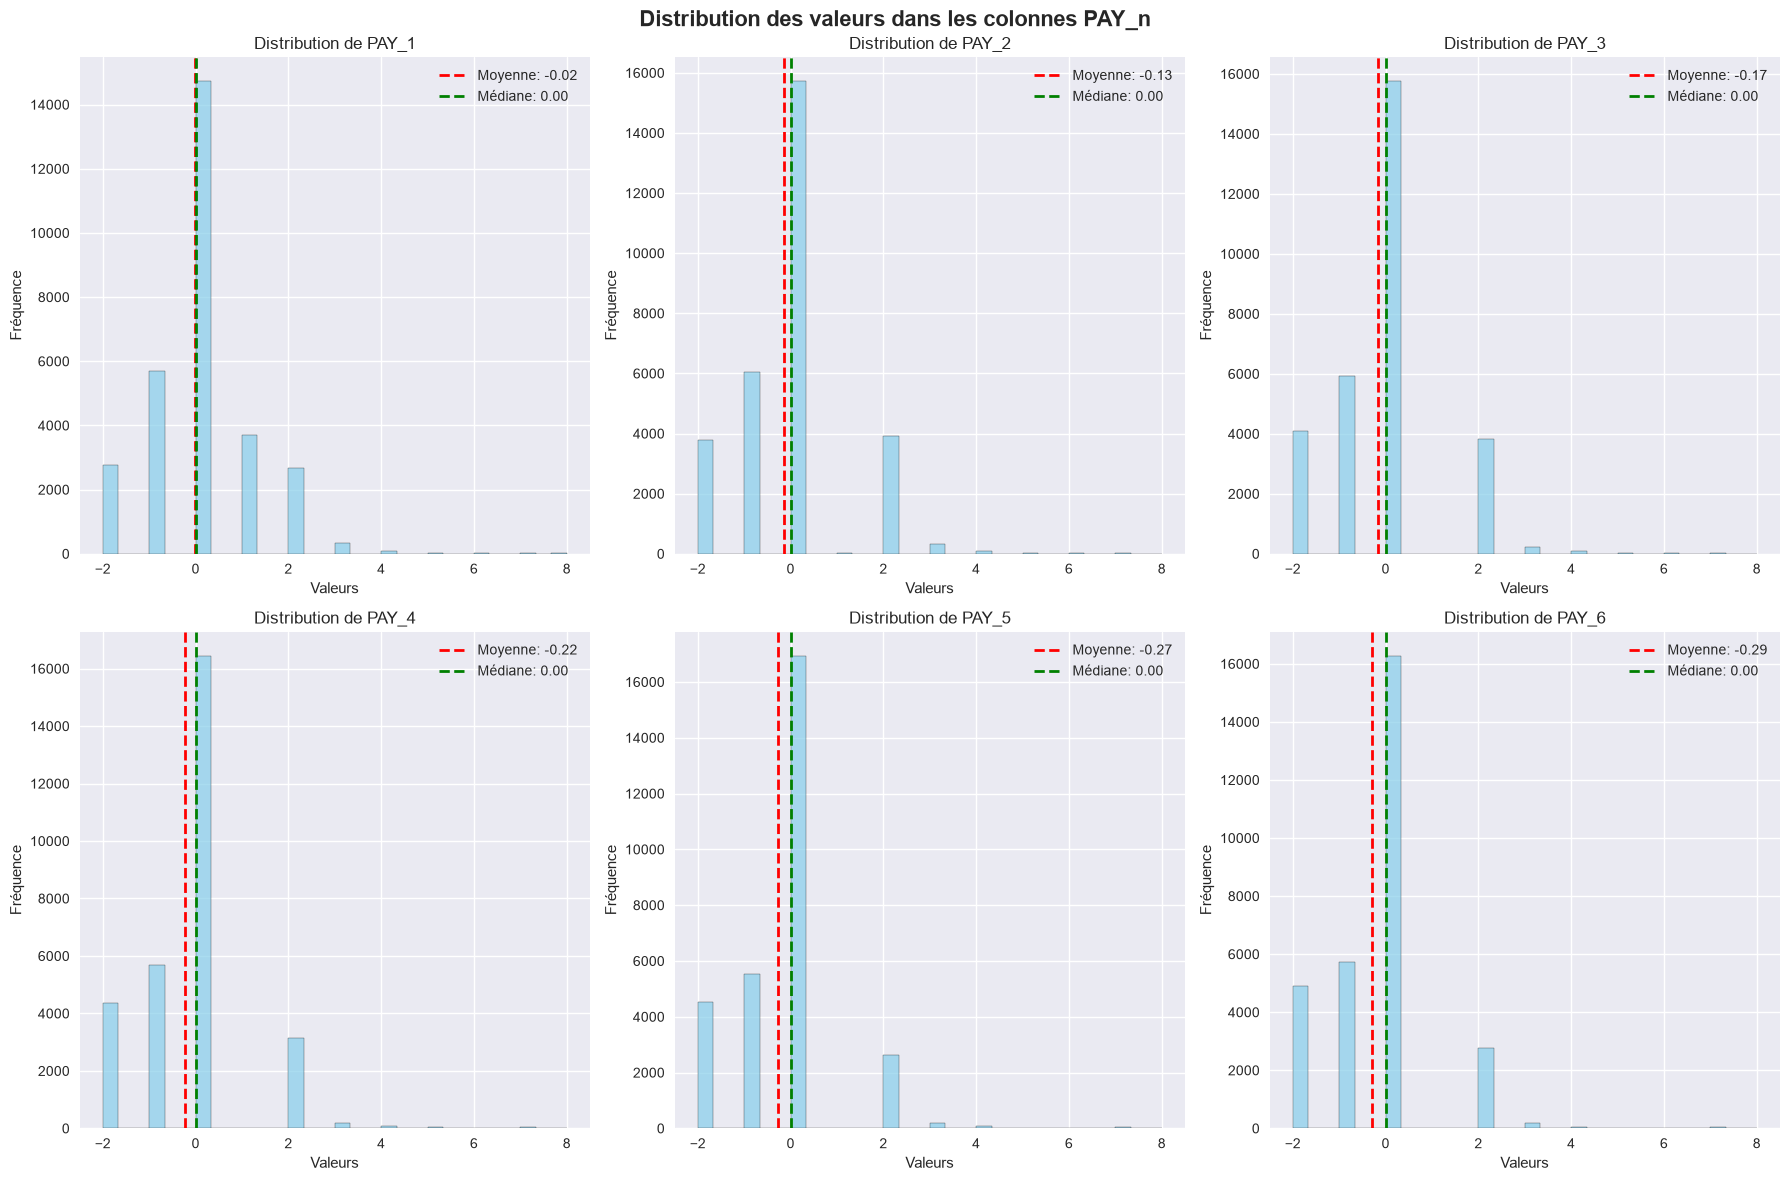


=== HISTOGRAMME CUMULÉ ===


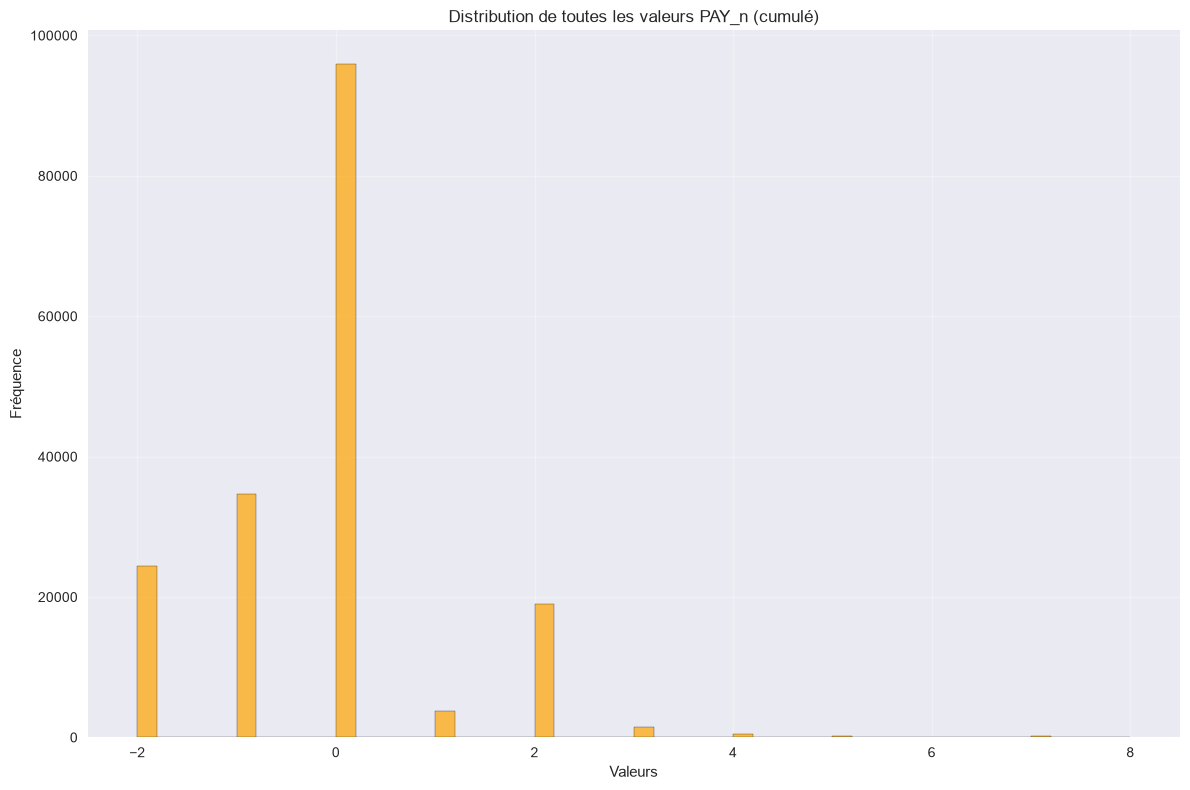

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== HISTOGRAMMES DES VALEURS PAY_N ===")

# Configuration du style
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribution des valeurs dans les colonnes PAY_n', fontsize=16, fontweight='bold')

# Création des histogrammes pour chaque colonne
for i, col in enumerate(pay_columns):
    row = i // 3
    col_idx = i % 3
    
    # Filtrer les valeurs non nulles pour l'histogramme
    data = df[col].dropna()
    
    axes[row, col_idx].hist(data, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[row, col_idx].set_title(f'Distribution de {col}')
    axes[row, col_idx].set_xlabel('Valeurs')
    axes[row, col_idx].set_ylabel('Fréquence')
    
    # Ajout des statistiques
    mean_val = data.mean()
    median_val = data.median()
    axes[row, col_idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                              label=f'Moyenne: {mean_val:.2f}')
    axes[row, col_idx].axvline(median_val, color='green', linestyle='--', linewidth=2, 
                              label=f'Médiane: {median_val:.2f}')
    axes[row, col_idx].legend()

# Cacher l'axe vide si nécessaire
if len(pay_columns) < 6:
    axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

print("\n=== HISTOGRAMME CUMULÉ ===")
# Histogramme cumulé de toutes les colonnes - CORRECTION
fig, ax = plt.subplots(figsize=(12, 8))

# Rassembler toutes les valeurs (pas de cumulative=True)
all_values = []
for col in pay_columns:
    all_values.extend(df[col].dropna())

# Créer l'histogramme standard avec toutes les données
ax.hist(all_values, bins=50, alpha=0.7, color='orange', edgecolor='black')
ax.set_title('Distribution de toutes les valeurs PAY_n (cumulé)')
ax.set_xlabel('Valeurs')
ax.set_ylabel('Fréquence')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

la valeur '1' dans PAY_n est clairement sous représentée  
quelques exemples dans le dataset au dessus montre qu'un dossier sain passe en incident directement à 2  
2 dossiers sains sans encours passent également au statut 'incident 1', ce qui semble être une réelle anomalie

In [33]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
mask = (df[pay_columns] == 1).any(axis=1)
df[mask].head(20)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,,,,,,,,
14,70000,1,2,2,30,1,2,2,0,0,...,66782,36137,36894,3200,0,3000,3000,1500,0,1
16,50000,2,3,3,23,1,2,0,0,0,...,28771,29531,30211,0,1500,1100,1200,1300,1100,0
19,360000,2,1,1,49,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
20,180000,2,1,2,29,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
27,60000,1,1,2,27,1,-2,-1,-1,-1,...,-57,127,-189,0,1000,0,500,0,1000,1
39,50000,1,1,2,25,1,-1,-1,-2,-2,...,0,0,0,780,0,0,0,0,0,1
51,70000,1,3,2,42,1,2,2,2,2,...,39423,38659,39362,0,3100,2000,0,1500,1500,1
54,180000,2,1,2,25,1,2,0,0,0,...,43510,44420,45319,1300,2010,1762,1762,1790,1622,0
69,130000,2,3,2,29,1,-2,-2,-1,2,...,10311,10161,7319,0,0,20161,0,7319,13899,0


In [34]:
pay_columns = ['PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
mask = (df[pay_columns] == 1).any(axis=1)
df[mask]

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
ID,,,,,,,,,,,,,,,,,,,,,
892,400000,1,2,2,37,1,1,1,2,0,...,12599,18599,12284,3019,5014,3,7040,2006,2005,0
1967,90000,1,2,1,29,1,1,1,0,0,...,2442,48063,48186,3100,1000,770,48012,1756,1894,0
5645,500000,1,1,1,42,1,1,0,0,0,...,163299,159110,135658,1054,177080,4425,5666,4825,100225,0
6025,210000,2,2,2,29,1,1,-2,-2,-1,...,-1987,1697,4347,0,0,2000,4000,3000,5000,0
6118,80000,1,1,2,26,1,1,-2,-2,-2,...,0,0,0,5000,0,0,0,0,0,0
6783,500000,1,1,1,32,1,1,1,1,0,...,64178,64992,50722,20000,20012,10036,15000,10000,50000,0
8616,270000,2,2,2,53,1,1,-2,-2,-2,...,-4,-19205,42418,2,2,6002,2,64446,5002,0
9120,50000,1,2,2,40,1,1,-1,-1,0,...,29148,30270,22814,0,2931,30000,5270,2814,3089,0
11013,20000,2,2,2,45,1,1,-1,0,-1,...,8005,3034,9287,700,21400,1005,3034,9287,85,0


In [35]:
# Compte le nombre de '1' dans chaque colonne PAY_n
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== COMPTAGE DES VALEURS '1' DANS CHAQUE COLONNE PAY_N ===")

# Compter le nombre de 1 dans chaque colonne
column_counts = {}
total_ones = 0

for col in pay_columns:
    count = (df[col] == 1).sum()
    column_counts[col] = count
    total_ones += count
    percentage = (count / len(df)) * 100
    print(f"{col} : {count} sur {len(df)} ({percentage:.2f}%)")


=== COMPTAGE DES VALEURS '1' DANS CHAQUE COLONNE PAY_N ===
PAY_1 : 3688 sur 29996 (12.29%)
PAY_2 : 28 sur 29996 (0.09%)
PAY_3 : 4 sur 29996 (0.01%)
PAY_4 : 2 sur 29996 (0.01%)
PAY_5 : 0 sur 29996 (0.00%)
PAY_6 : 0 sur 29996 (0.00%)


PAY_1 contient beaucoup de '1' alors que cette valeur est qausi absente des autres colonnes, et nombre d'entre eux ne sont pas justifiés  
Avant de tenter un nettoyage, je constate une tendance de codification légèrement différente de ce qui est décrit dans la documentation  
Si on écarte les erreurs humaines, informatiques et autres, il se dégage une certaine tendance concernant les valeurs de PAY_n :
- -2 correspond à des comptes majoritairement inactifs
- -1 et 0 correspondent à des comptes ayant un fonctionnement sain ne présentant pas de retard
- 1 correspond à une sorte d'alerte sur le compte (fin d'un retard, activation ou réactivation d'un compte), il ne semble pas forcemment correspondre à une échéance de retard
- 2 et + correspondent à des comptes avec retards, en effet un incident fait basculer la note directement à 2
Ces indications sont très importantes pour la représentation des ensembles et la creéations des features pour les futurs modèles de prédiction  
Dans le cas ou 1 signifie que la banque a reçu une information interne ou externe concernant le compte, il apparaît délicat de corriger cette colonne.

Le défaut de paiement futur 'dpnm' est de 22% dans le dataset.  
Une banque ne survivrait pas plusieurs mois avec un taux de défaillance aussi élevé, on peut s'interroger sur l'origine du dataset et de son éventuel biais, surtout mis en relation avec la forte proportion de PAY_1 = 1.  
Ceci est à mettre dans le contexte suivant : une crise importante a eu lieu en 2005 à Taïwan sur le crédit avec un emballement soudain de son usage et du taux de défaut.

In [36]:
# Afficher la proportion de dpnm == 1 alors que BILL_AMT1 <= 0
print("=== ANALYSE DE dpnm LORSQUE BILL_AMT1 <= 0 ===")

# Création des masques
mask_bill_zero = df['BILL_AMT1'] <= 0
total_with_bill_zero = mask_bill_zero.sum()

print(f"Nombre total de lignes où BILL_AMT1 <= 0 : {total_with_bill_zero}")

if total_with_bill_zero > 0:
    # Proportion de dpnm == 1 dans ces lignes
    mask_dpnm_one = (df['BILL_AMT1'] <= 0) & (df['dpnm'] == 1)
    count_dpnm_one = mask_dpnm_one.sum()
    
    percentage_dpnm_one = (count_dpnm_one / total_with_bill_zero) * 100
    
    print(f"Nombre de lignes où BILL_AMT1 <= 0 ET dpnm == 1 : {count_dpnm_one}")
    print(f"Proportion de dpnm == 1 parmi les lignes où BILL_AMT1 <= 0 : {percentage_dpnm_one:.2f}%")
    
    # Répartition complète de dpnm dans ces lignes
    dpnm_distribution = df[mask_bill_zero]['dpnm'].value_counts().sort_index()
    print(f"\nRépartition complète de dpnm pour les lignes où BILL_AMT1 <= 0 :")
    for value, count in dpnm_distribution.items():
        percentage = (count / total_with_bill_zero) * 100
        print(f"  - dpnm = {value} : {count} sur {total_with_bill_zero} ({percentage:.2f}%)")
    
    # Comparaison avec l'ensemble du dataset
    total_dataset = len(df)
    dpnm_global = df['dpnm'].value_counts().sort_index()
    
    print(f"\n=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===")
    print(f"Nombre total de lignes : {total_dataset}")
    print(f"Répartition globale de dpnm :")
    for value, count in dpnm_global.items():
        percentage = (count / total_dataset) * 100
        print(f"  - dpnm = {value} : {count} sur {total_dataset} ({percentage:.2f}%)")
    
    print(f"\n=== ANALYSE DÉTAILLÉE ===")
    # Calcul des proportions dans les deux cas
    if total_with_bill_zero > 0:
        print(f"Pourcentage de dpnm = 1 dans les lignes avec BILL_AMT1 <= 0 : {percentage_dpnm_one:.2f}%")
        print(f"Pourcentage de dpnm = 1 dans l'ensemble du dataset : {(dpnm_global.get(1, 0) / total_dataset * 100):.2f}%")
        
        # Calcul de l'impact
        global_dpnm_1 = (dpnm_global.get(1, 0) / total_dataset) * 100
        if global_dpnm_1 > 0:
            impact = percentage_dpnm_one - global_dpnm_1
            print(f"Écart par rapport à la moyenne : {impact:.2f}%")
    
    # Afficher quelques exemples de lignes
    print(f"\n=== EXEMPLES DE LIGNES ===")
    sample_rows = df[mask_bill_zero].head(5)
    print("Premières lignes où BILL_AMT1 <= 0 :")
    print(sample_rows[['BILL_AMT1', 'dpnm']])
    
else:
    print("Aucune ligne ne correspond à la condition BILL_AMT1 <= 0")

print("\n=== ANALYSE COMPARATIVE ===")
# Comparaison avec d'autres conditions
conditions = [
    ("BILL_AMT1 <= 0", df['BILL_AMT1'] <= 0),
    ("BILL_AMT1 > 0", df['BILL_AMT1'] > 0),
    ("BILL_AMT1 < 0", df['BILL_AMT1'] < 0)
]

for condition_name, condition_mask in conditions:
    if condition_mask.sum() > 0:
        dpnm_counts = df[condition_mask]['dpnm'].value_counts()
        print(f"\n{condition_name} :")
        for value, count in dpnm_counts.items():
            percentage = (count / condition_mask.sum()) * 100
            print(f"  - dpnm = {value} : {count} sur {condition_mask.sum()} ({percentage:.2f}%)")

=== ANALYSE DE dpnm LORSQUE BILL_AMT1 <= 0 ===
Nombre total de lignes où BILL_AMT1 <= 0 : 2598
Nombre de lignes où BILL_AMT1 <= 0 ET dpnm == 1 : 643
Proportion de dpnm == 1 parmi les lignes où BILL_AMT1 <= 0 : 24.75%

Répartition complète de dpnm pour les lignes où BILL_AMT1 <= 0 :
  - dpnm = 0 : 1955 sur 2598 (75.25%)
  - dpnm = 1 : 643 sur 2598 (24.75%)

=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===
Nombre total de lignes : 29996
Répartition globale de dpnm :
  - dpnm = 0 : 23360 sur 29996 (77.88%)
  - dpnm = 1 : 6636 sur 29996 (22.12%)

=== ANALYSE DÉTAILLÉE ===
Pourcentage de dpnm = 1 dans les lignes avec BILL_AMT1 <= 0 : 24.75%
Pourcentage de dpnm = 1 dans l'ensemble du dataset : 22.12%
Écart par rapport à la moyenne : 2.63%

=== EXEMPLES DE LIGNES ===
Premières lignes où BILL_AMT1 <= 0 :
    BILL_AMT1  dpnm
ID                 
10          0     0
19          0     0
20          0     0
27       -109     1
39          0     1

=== ANALYSE COMPARATIVE ===

BILL_AMT1 <= 0 :
  - dpn

Ces résultats sont extrêmement illogiques, une banque ne peut pas avoir un incident de paiement futur sans encours.  
Cela est surtout un bruit conséquent que les modèles ne pourront pas atténuer. De plus, pour une banque, c'est la sécurisation de l'encours réel qui compte

In [37]:
# Afficher la proportion de dpnm == 1 alors que TOUS les BILL_AMTn < 0
print("=== ANALYSE DE dpnm LORSQUE TOUS LES BILL_AMTn < 0 ===")

# Création des listes de colonnes
bill_amt_columns = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Trouver les lignes où TOUS les BILL_AMTn sont < 0
mask_all_bill_neg = df[bill_amt_columns].lt(0).all(axis=1)
total_with_all_bill_neg = mask_all_bill_neg.sum()

print(f"Nombre total de lignes où TOUS les BILL_AMTn < 0 : {total_with_all_bill_neg}")

if total_with_all_bill_neg > 0:
    # Proportion de dpnm == 1 dans ces lignes
    mask_dpnm_one = (df[bill_amt_columns].lt(0).all(axis=1)) & (df['dpnm'] == 1)
    count_dpnm_one = mask_dpnm_one.sum()
    
    percentage_dpnm_one = (count_dpnm_one / total_with_all_bill_neg) * 100
    
    print(f"Nombre de lignes où TOUS les BILL_AMTn < 0 ET dpnm == 1 : {count_dpnm_one}")
    print(f"Proportion de dpnm == 1 parmi les lignes où TOUS les BILL_AMTn < 0 : {percentage_dpnm_one:.2f}%")
    
    # Répartition complète de dpnm dans ces lignes
    dpnm_distribution = df[mask_all_bill_neg]['dpnm'].value_counts().sort_index()
    print(f"\nRépartition complète de dpnm pour les lignes où TOUS les BILL_AMTn < 0 :")
    for value, count in dpnm_distribution.items():
        percentage = (count / total_with_all_bill_neg) * 100
        print(f"  - dpnm = {value} : {count} sur {total_with_all_bill_neg} ({percentage:.2f}%)")
    
    # Comparaison avec l'ensemble du dataset
    total_dataset = len(df)
    dpnm_global = df['dpnm'].value_counts().sort_index()
    
    print(f"\n=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===")
    print(f"Nombre total de lignes : {total_dataset}")
    print(f"Répartition globale de dpnm :")
    for value, count in dpnm_global.items():
        percentage = (count / total_dataset) * 100
        print(f"  - dpnm = {value} : {count} sur {total_dataset} ({percentage:.2f}%)")
    
    print(f"\n=== ANALYSE DÉTAILLÉE ===")
    # Calcul des proportions dans les deux cas
    if total_with_all_bill_neg > 0:
        print(f"Pourcentage de dpnm = 1 dans les lignes avec TOUS les BILL_AMTn < 0 : {percentage_dpnm_one:.2f}%")
        print(f"Pourcentage de dpnm = 1 dans l'ensemble du dataset : {(dpnm_global.get(1, 0) / total_dataset * 100):.2f}%")
        
        # Calcul de l'impact
        global_dpnm_1 = (dpnm_global.get(1, 0) / total_dataset) * 100
        if global_dpnm_1 > 0:
            impact = percentage_dpnm_one - global_dpnm_1
            print(f"Écart par rapport à la moyenne : {impact:.2f}%")
    
    # Afficher quelques exemples de lignes
    print(f"\n=== EXEMPLES DE LIGNES ===")
    sample_rows = df[mask_all_bill_neg].head(5)
    print("Premières lignes où TOUS les BILL_AMTn < 0 :")
    print(sample_rows[['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'dpnm']])
else:
    print("Aucune ligne ne correspond à la condition TOUS les BILL_AMTn < 0")

print("\n=== ANALYSE COMPARATIVE ===")
# Comparaison avec d'autres conditions
conditions = [
    ("TOUS les BILL_AMTn < 0", df[bill_amt_columns].lt(0).all(axis=1)),
    ("AU MOINS UN BILL_AMTn < 0", df[bill_amt_columns].lt(0).any(axis=1)),
    ("TOUS les BILL_AMTn > 0", df[bill_amt_columns].gt(0).all(axis=1))
]

for condition_name, condition_mask in conditions:
    if condition_mask.sum() > 0:
        dpnm_counts = df[condition_mask]['dpnm'].value_counts()
        print(f"\n{condition_name} :")
        for value, count in dpnm_counts.items():
            percentage = (count / condition_mask.sum()) * 100
            print(f"  - dpnm = {value} : {count} sur {condition_mask.sum()} ({percentage:.2f}%)")

=== ANALYSE DE dpnm LORSQUE TOUS LES BILL_AMTn < 0 ===
Nombre total de lignes où TOUS les BILL_AMTn < 0 : 88
Nombre de lignes où TOUS les BILL_AMTn < 0 ET dpnm == 1 : 26
Proportion de dpnm == 1 parmi les lignes où TOUS les BILL_AMTn < 0 : 29.55%

Répartition complète de dpnm pour les lignes où TOUS les BILL_AMTn < 0 :
  - dpnm = 0 : 62 sur 88 (70.45%)
  - dpnm = 1 : 26 sur 88 (29.55%)

=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===
Nombre total de lignes : 29996
Répartition globale de dpnm :
  - dpnm = 0 : 23360 sur 29996 (77.88%)
  - dpnm = 1 : 6636 sur 29996 (22.12%)

=== ANALYSE DÉTAILLÉE ===
Pourcentage de dpnm = 1 dans les lignes avec TOUS les BILL_AMTn < 0 : 29.55%
Pourcentage de dpnm = 1 dans l'ensemble du dataset : 22.12%
Écart par rapport à la moyenne : 7.42%

=== EXEMPLES DE LIGNES ===
Premières lignes où TOUS les BILL_AMTn < 0 :
     BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  dpnm
ID                                                              
110       -103    

In [38]:
# Afficher la proportion de dpnm == 1 alors que TOUS les BILL_AMTn == 0
print("=== ANALYSE DE dpnm LORSQUE TOUS LES BILL_AMTn == 0 ===")

# Création des listes de colonnes
bill_amt_columns = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Trouver les lignes où TOUS les BILL_AMTn sont == 0
mask_all_bill_zero = df[bill_amt_columns].eq(0).all(axis=1)
total_with_all_bill_zero = mask_all_bill_zero.sum()

print(f"Nombre total de lignes où TOUS les BILL_AMTn == 0 : {total_with_all_bill_zero}")

if total_with_all_bill_zero > 0:
    # Proportion de dpnm == 1 dans ces lignes
    mask_dpnm_one = (df[bill_amt_columns].eq(0).all(axis=1)) & (df['dpnm'] == 1)
    count_dpnm_one = mask_dpnm_one.sum()
    
    percentage_dpnm_one = (count_dpnm_one / total_with_all_bill_zero) * 100
    
    print(f"Nombre de lignes où TOUS les BILL_AMTn == 0 ET dpnm == 1 : {count_dpnm_one}")
    print(f"Proportion de dpnm == 1 parmi les lignes où TOUS les BILL_AMTn == 0 : {percentage_dpnm_one:.2f}%")
    
    # Répartition complète de dpnm dans ces lignes
    dpnm_distribution = df[mask_all_bill_zero]['dpnm'].value_counts().sort_index()
    print(f"\nRépartition complète de dpnm pour les lignes où TOUS les BILL_AMTn == 0 :")
    for value, count in dpnm_distribution.items():
        percentage = (count / total_with_all_bill_zero) * 100
        print(f"  - dpnm = {value} : {count} sur {total_with_all_bill_zero} ({percentage:.2f}%)")
    
    # Comparaison avec l'ensemble du dataset
    total_dataset = len(df)
    dpnm_global = df['dpnm'].value_counts().sort_index()
    
    print(f"\n=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===")
    print(f"Nombre total de lignes : {total_dataset}")
    print(f"Répartition globale de dpnm :")
    for value, count in dpnm_global.items():
        percentage = (count / total_dataset) * 100
        print(f"  - dpnm = {value} : {count} sur {total_dataset} ({percentage:.2f}%)")
    
    print(f"\n=== ANALYSE DÉTAILLÉE ===")
    # Calcul des proportions dans les deux cas
    if total_with_all_bill_zero > 0:
        print(f"Pourcentage de dpnm = 1 dans les lignes avec TOUS les BILL_AMTn == 0 : {percentage_dpnm_one:.2f}%")
        print(f"Pourcentage de dpnm = 1 dans l'ensemble du dataset : {(dpnm_global.get(1, 0) / total_dataset * 100):.2f}%")
        
        # Calcul de l'impact
        global_dpnm_1 = (dpnm_global.get(1, 0) / total_dataset) * 100
        if global_dpnm_1 > 0:
            impact = percentage_dpnm_one - global_dpnm_1
            print(f"Écart par rapport à la moyenne : {impact:.2f}%")
    
    # Afficher quelques exemples de lignes
    print(f"\n=== EXEMPLES DE LIGNES ===")
    sample_rows = df[mask_all_bill_zero].head(5)
    print("Premières lignes où TOUS les BILL_AMTn == 0 :")
    print(sample_rows[['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'dpnm']])
    
else:
    print("Aucune ligne ne correspond à la condition TOUS les BILL_AMTn == 0")

print("\n=== ANALYSE COMPARATIVE ===")
# Comparaison avec d'autres conditions
conditions = [
    ("TOUS les BILL_AMTn == 0", df[bill_amt_columns].eq(0).all(axis=1)),
    ("TOUS les BILL_AMTn <= 0", df[bill_amt_columns].le(0).all(axis=1)),
    ("AU MOINS UN BILL_AMTn == 0", df[bill_amt_columns].eq(0).any(axis=1)),
    ("TOUS les BILL_AMTn > 0", df[bill_amt_columns].gt(0).all(axis=1))
]

for condition_name, condition_mask in conditions:
    if condition_mask.sum() > 0:
        dpnm_counts = df[condition_mask]['dpnm'].value_counts()
        print(f"\n{condition_name} :")
        for value, count in dpnm_counts.items():
            percentage = (count / condition_mask.sum()) * 100
            print(f"  - dpnm = {value} : {count} sur {condition_mask.sum()} ({percentage:.2f}%)")

=== ANALYSE DE dpnm LORSQUE TOUS LES BILL_AMTn == 0 ===
Nombre total de lignes où TOUS les BILL_AMTn == 0 : 866
Nombre de lignes où TOUS les BILL_AMTn == 0 ET dpnm == 1 : 317
Proportion de dpnm == 1 parmi les lignes où TOUS les BILL_AMTn == 0 : 36.61%

Répartition complète de dpnm pour les lignes où TOUS les BILL_AMTn == 0 :
  - dpnm = 0 : 549 sur 866 (63.39%)
  - dpnm = 1 : 317 sur 866 (36.61%)

=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===
Nombre total de lignes : 29996
Répartition globale de dpnm :
  - dpnm = 0 : 23360 sur 29996 (77.88%)
  - dpnm = 1 : 6636 sur 29996 (22.12%)

=== ANALYSE DÉTAILLÉE ===
Pourcentage de dpnm = 1 dans les lignes avec TOUS les BILL_AMTn == 0 : 36.61%
Pourcentage de dpnm = 1 dans l'ensemble du dataset : 22.12%
Écart par rapport à la moyenne : 14.48%

=== EXEMPLES DE LIGNES ===
Premières lignes où TOUS les BILL_AMTn == 0 :
     BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  dpnm
ID                                                              
19  

Aucune information n'existe sur internet ni dans l'étude originelle de 2009 sur ces incidents de paiement qui ne semblent pas concerner un encours. Si on raisonne logique métier, nous cherchons à sécuriser un encours et à prévoir le défaut de paiement réel.  
Il conviendra donc de ne pas inclure ces comptes inactifs dans les modèles d'apprentissage et de ne pas prédire le risque de défaut sur un crédit non utilisé.

Je repars sur la codification '1' dans PAY_n pour comprendre la logique et éventuellement envisager un nettoyage.  
Je regarde ce qui précède PAY_n = 1 et ce qui suit PAY_n = 1

In [39]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== RÉPARTITION DES VALEURS DE PAY_n+1 QUAND PAY_n = 1 ===")

# Pour chaque colonne PAY_n (sauf la dernière)
for i in range(len(pay_columns) - 1):
    current_pay = pay_columns[i]
    next_pay = pay_columns[i + 1]
    
    print(f"\n--- {current_pay} = 1 → {next_pay} ---")
    
    # Créer le masque pour les lignes où PAY_n = 1
    mask = df[current_pay] == 1
    total_with_current_pay_one = mask.sum()
    
    if total_with_current_pay_one > 0:
        print(f"Nombre de lignes où {current_pay} = 1 : {total_with_current_pay_one}")
        
        # Calculer la répartition des valeurs de PAY_{n+1}
        value_counts = df[mask][next_pay].value_counts().sort_index()
        
        print(f"Répartition de {next_pay} dans ces lignes :")
        for value, count in value_counts.items():
            percentage = (count / total_with_current_pay_one) * 100
            print(f"  - {next_pay} = {value} : {count} sur {total_with_current_pay_one} ({percentage:.2f}%)")
        
        # Afficher quelques statistiques supplémentaires
        next_values = df[mask][next_pay]
        print(f"  - Moyenne de {next_pay} : {next_values.mean():.2f}")
        print(f"  - Médiane de {next_pay} : {next_values.median():.2f}")
        print(f"  - Écart-type de {next_pay} : {next_values.std():.2f}")
        
    else:
        print(f"Aucune ligne où {current_pay} = 1")

print("\n=== ANALYSE COMPARATIVE ===")
print("Comparaison des répartitions entre les différents mois")

# Comparaison des répartitions
for i in range(len(pay_columns) - 1):
    current_pay = pay_columns[i]
    next_pay = pay_columns[i + 1]
    
    # Calculer la proportion de chaque valeur de PAY_{n+1} parmi les lignes où PAY_n = 1
    mask = df[current_pay] == 1
    total_with_current_pay_one = mask.sum()
    
    if total_with_current_pay_one > 0:
        value_counts = df[mask][next_pay].value_counts().sort_index()
        print(f"\n{current_pay} = 1 → {next_pay} :")
        for value, count in value_counts.items():
            percentage = (count / total_with_current_pay_one) * 100
            print(f"  - {value} : {percentage:.2f}%")

print("\n=== RÉSUMÉ GLOBAL ===")
print("Nombre de lignes avec PAY_n = 1 pour chaque colonne :")

# Afficher le nombre de lignes avec chaque valeur de PAY_n
for pay_col in pay_columns:
    count = (df[pay_col] == 1).sum()
    percentage = (count / len(df)) * 100
    print(f"  {pay_col} = 1 : {count} sur {len(df)} ({percentage:.2f}%)")

=== RÉPARTITION DES VALEURS DE PAY_n+1 QUAND PAY_n = 1 ===

--- PAY_1 = 1 → PAY_2 ---
Nombre de lignes où PAY_1 = 1 : 3688
Répartition de PAY_2 dans ces lignes :
  - PAY_2 = -2 : 1221 sur 3688 (33.11%)
  - PAY_2 = -1 : 612 sur 3688 (16.59%)
  - PAY_2 = 0 : 3 sur 3688 (0.08%)
  - PAY_2 = 1 : 28 sur 3688 (0.76%)
  - PAY_2 = 2 : 1672 sur 3688 (45.34%)
  - PAY_2 = 3 : 109 sur 3688 (2.96%)
  - PAY_2 = 4 : 32 sur 3688 (0.87%)
  - PAY_2 = 5 : 7 sur 3688 (0.19%)
  - PAY_2 = 6 : 2 sur 3688 (0.05%)
  - PAY_2 = 7 : 1 sur 3688 (0.03%)
  - PAY_2 = 8 : 1 sur 3688 (0.03%)
  - Moyenne de PAY_2 : 0.23
  - Médiane de PAY_2 : 1.00
  - Écart-type de PAY_2 : 1.94

--- PAY_2 = 1 → PAY_3 ---
Nombre de lignes où PAY_2 = 1 : 28
Répartition de PAY_3 dans ces lignes :
  - PAY_3 = -2 : 12 sur 28 (42.86%)
  - PAY_3 = -1 : 9 sur 28 (32.14%)
  - PAY_3 = 0 : 1 sur 28 (3.57%)
  - PAY_3 = 1 : 4 sur 28 (14.29%)
  - PAY_3 = 2 : 2 sur 28 (7.14%)
  - Moyenne de PAY_3 : -0.89
  - Médiane de PAY_3 : -1.00
  - Écart-type de P

In [40]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== RÉPARTITION DES VALEURS DE PAY_n-1 QUAND PAY_n = 1 ===")

# Pour chaque colonne PAY_n (sauf la première)
for i in range(1, len(pay_columns)):  # Commence à 1 pour pouvoir accéder à PAY_{n-1}
    current_pay = pay_columns[i]
    prev_pay = pay_columns[i - 1]
    
    print(f"\n--- {current_pay} = 1 → {prev_pay} ---")
    
    # Créer le masque pour les lignes où PAY_n = 1
    mask = df[current_pay] == 1
    total_with_current_pay_one = mask.sum()
    
    if total_with_current_pay_one > 0:
        print(f"Nombre de lignes où {current_pay} = 1 : {total_with_current_pay_one}")
        
        # Calculer la répartition des valeurs de PAY_{n-1}
        value_counts = df[mask][prev_pay].value_counts().sort_index()
        
        print(f"Répartition de {prev_pay} dans ces lignes :")
        for value, count in value_counts.items():
            percentage = (count / total_with_current_pay_one) * 100
            print(f"  - {prev_pay} = {value} : {count} sur {total_with_current_pay_one} ({percentage:.2f}%)")
        
        # Afficher quelques statistiques supplémentaires
        prev_values = df[mask][prev_pay]
        print(f"  - Moyenne de {prev_pay} : {prev_values.mean():.2f}")
        print(f"  - Médiane de {prev_pay} : {prev_values.median():.2f}")
        print(f"  - Écart-type de {prev_pay} : {prev_values.std():.2f}")
        
    else:
        print(f"Aucune ligne où {current_pay} = 1")

print("\n=== RÉSUMÉ GLOBAL ===")
print("Nombre de lignes avec PAY_n = 1 pour chaque colonne :")

# Afficher le nombre de lignes avec chaque valeur de PAY_n
for pay_col in pay_columns:
    count = (df[pay_col] == 1).sum()
    percentage = (count / len(df)) * 100
    print(f"  {pay_col} = 1 : {count} sur {len(df)} ({percentage:.2f}%)")



=== RÉPARTITION DES VALEURS DE PAY_n-1 QUAND PAY_n = 1 ===

--- PAY_2 = 1 → PAY_1 ---
Nombre de lignes où PAY_2 = 1 : 28
Répartition de PAY_1 dans ces lignes :
  - PAY_1 = 1 : 28 sur 28 (100.00%)
  - Moyenne de PAY_1 : 1.00
  - Médiane de PAY_1 : 1.00
  - Écart-type de PAY_1 : 0.00

--- PAY_3 = 1 → PAY_2 ---
Nombre de lignes où PAY_3 = 1 : 4
Répartition de PAY_2 dans ces lignes :
  - PAY_2 = 1 : 4 sur 4 (100.00%)
  - Moyenne de PAY_2 : 1.00
  - Médiane de PAY_2 : 1.00
  - Écart-type de PAY_2 : 0.00

--- PAY_4 = 1 → PAY_3 ---
Nombre de lignes où PAY_4 = 1 : 2
Répartition de PAY_3 dans ces lignes :
  - PAY_3 = 1 : 2 sur 2 (100.00%)
  - Moyenne de PAY_3 : 1.00
  - Médiane de PAY_3 : 1.00
  - Écart-type de PAY_3 : 0.00

--- PAY_5 = 1 → PAY_4 ---
Aucune ligne où PAY_5 = 1

--- PAY_6 = 1 → PAY_5 ---
Aucune ligne où PAY_6 = 1

=== RÉSUMÉ GLOBAL ===
Nombre de lignes avec PAY_n = 1 pour chaque colonne :
  PAY_1 = 1 : 3688 sur 29996 (12.29%)
  PAY_2 = 1 : 28 sur 29996 (0.09%)
  PAY_3 = 1 : 4 sur

PAY_n = 1 apparait majoritairement sur des comptes inactifs ou en impayés  
Quand PAY_n =1, PAY_n-1 = 1  
Cela confirme le statut de valeur d'alerte ou pré alerte. Cela peut être aussi un compte en instance de fermeture, de gel...

In [41]:
print("=== TAUX DE dpnm = 1 QUAND PAY_1 = 1 ===")

# Analyse pour PAY_1 = 1
current_pay = 'PAY_1'
mask = df[current_pay] == 1
total_with_current_pay_one = mask.sum()

print(f"Nombre total de lignes où {current_pay} = 1 : {total_with_current_pay_one}")

if total_with_current_pay_one > 0:
    # Calcul du taux de dpnm = 1
    mask_dpnm_one = (df[current_pay] == 1) & (df['dpnm'] == 1)
    count_dpnm_one = mask_dpnm_one.sum()
    
    percentage_dpnm_one = (count_dpnm_one / total_with_current_pay_one) * 100
    
    print(f"Nombre de lignes où {current_pay} = 1 ET dpnm = 1 : {count_dpnm_one}")
    print(f"Taux de dpnm = 1 parmi les lignes où {current_pay} = 1 : {percentage_dpnm_one:.2f}%")
    
    # Répartition complète de dpnm dans ces lignes
    dpnm_distribution = df[mask]['dpnm'].value_counts().sort_index()
    print(f"\nRépartition complète de dpnm pour les lignes où {current_pay} = 1 :")
    for value, count in dpnm_distribution.items():
        percentage = (count / total_with_current_pay_one) * 100
        print(f"  - dpnm = {value} : {count} sur {total_with_current_pay_one} ({percentage:.2f}%)")
    
    # Comparaison avec l'ensemble du dataset
    total_dataset = len(df)
    dpnm_global = df['dpnm'].value_counts().sort_index()
    
    print(f"\n=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===")
    # Calcul des proportions dans les deux cas
    if total_with_current_pay_one > 0:
        print(f"Taux de dpnm = 1 dans les lignes où {current_pay} = 1 : {percentage_dpnm_one:.2f}%")
        print(f"Taux de dpnm = 1 dans l'ensemble du dataset : {(dpnm_global.get(1, 0) / total_dataset * 100):.2f}%")
        
        # Calcul de l'impact
        global_dpnm_1 = (dpnm_global.get(1, 0) / total_dataset) * 100
        if global_dpnm_1 > 0:
            impact = percentage_dpnm_one - global_dpnm_1
            print(f"Écart par rapport à la moyenne : {impact:.2f}%")
       
else:
    print(f"Aucune ligne ne correspond à la condition {current_pay} = 1")

print("\n=== RÉSUMÉ DES RÉPARTITIONS ===")
# Répartition globale des valeurs de PAY_1
pay1_distribution = df['PAY_1'].value_counts().sort_index()
print("Répartition de PAY_1 :")
for value, count in pay1_distribution.items():
    percentage = (count / len(df)) * 100
    print(f"  - PAY_1 = {value} : {count} sur {len(df)} ({percentage:.2f}%)")

=== TAUX DE dpnm = 1 QUAND PAY_1 = 1 ===
Nombre total de lignes où PAY_1 = 1 : 3688
Nombre de lignes où PAY_1 = 1 ET dpnm = 1 : 1252
Taux de dpnm = 1 parmi les lignes où PAY_1 = 1 : 33.95%

Répartition complète de dpnm pour les lignes où PAY_1 = 1 :
  - dpnm = 0 : 2436 sur 3688 (66.05%)
  - dpnm = 1 : 1252 sur 3688 (33.95%)

=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===
Taux de dpnm = 1 dans les lignes où PAY_1 = 1 : 33.95%
Taux de dpnm = 1 dans l'ensemble du dataset : 22.12%
Écart par rapport à la moyenne : 11.82%

=== RÉSUMÉ DES RÉPARTITIONS ===
Répartition de PAY_1 :
  - PAY_1 = -2 : 2758 sur 29996 (9.19%)
  - PAY_1 = -1 : 5684 sur 29996 (18.95%)
  - PAY_1 = 0 : 14736 sur 29996 (49.13%)
  - PAY_1 = 1 : 3688 sur 29996 (12.29%)
  - PAY_1 = 2 : 2667 sur 29996 (8.89%)
  - PAY_1 = 3 : 322 sur 29996 (1.07%)
  - PAY_1 = 4 : 76 sur 29996 (0.25%)
  - PAY_1 = 5 : 26 sur 29996 (0.09%)
  - PAY_1 = 6 : 11 sur 29996 (0.04%)
  - PAY_1 = 7 : 9 sur 29996 (0.03%)
  - PAY_1 = 8 : 19 sur 29996 (0.06%)

Un tableau de dispersion ici n'a pas beaucoup d'intéret.  
Je fais un heatmap.  

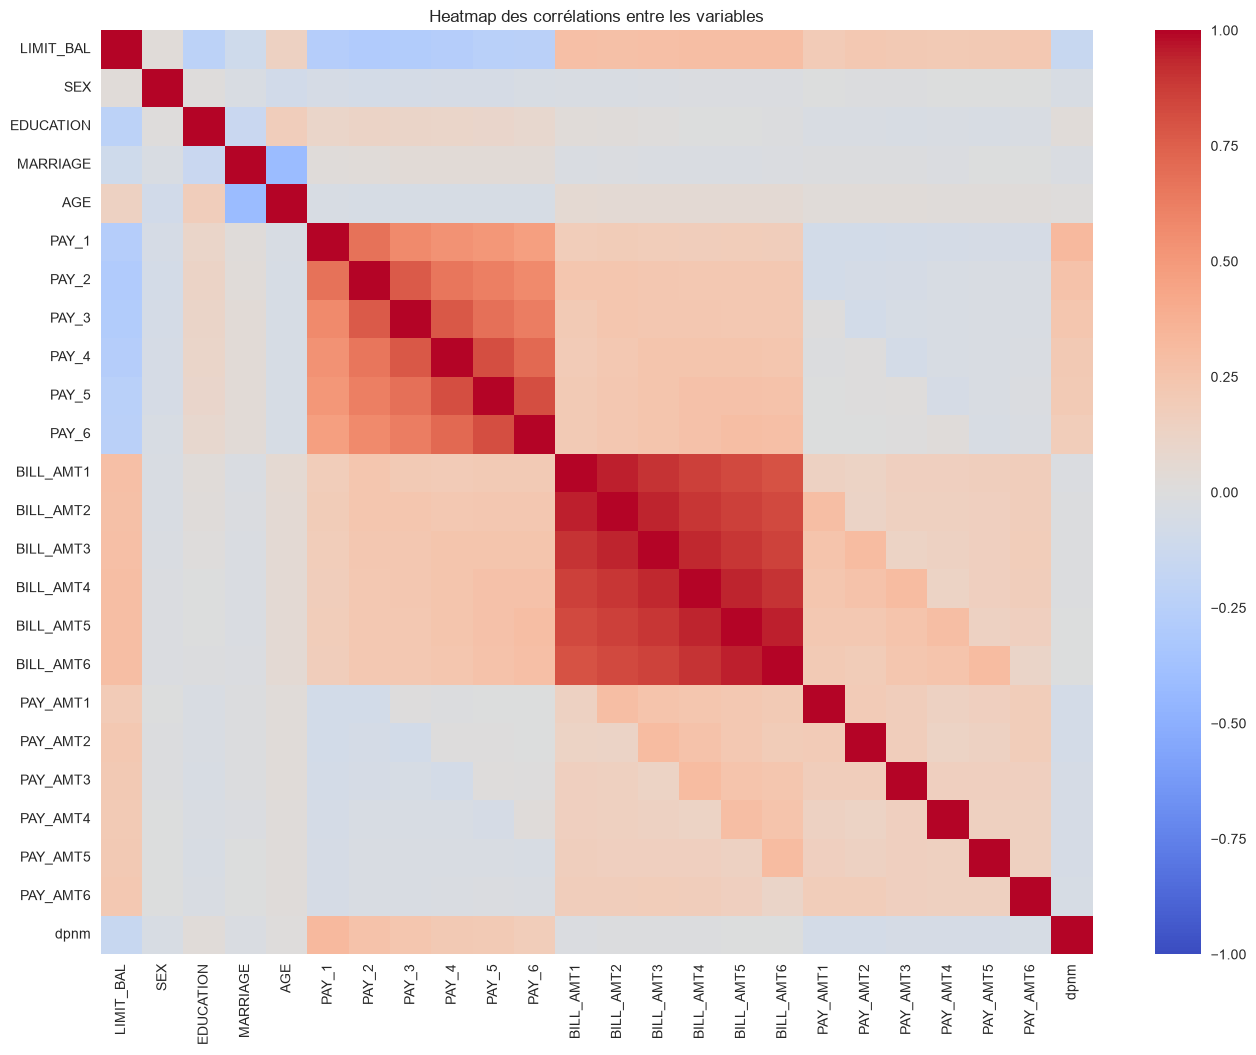

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assurez-vous que 'df' est votre DataFrame contenant les variables mentionnées
# Exemple : df = pd.read_csv('votre_fichier.csv')

# Sélectionner les variables pour la heatmap
variables = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 
             'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 
             'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm']

# Calculer la matrice de corrélation
correlation_matrix = df[variables].corr()

# Créer la heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap des corrélations entre les variables')
plt.show()

on voit des tendances, parfois contre intuitives :
- le défaut de paiement est plus important sur les plus petits plafond de crédit
- le défaut de paiement est directement lié avec le retard d'échéances
- les retards de paiement sont plus importants/fréquents quand l'encours augmente

y a t il un seuil de montant payé ou montant payé / encours à partir duquel la banque considère l'échéance payée ?  
Je commence par regarder si des montants sont payés alors que les encours sont négatifs ou nuls  

Analyse des cas où PAY_AMTn > 0 et BILL_AMTn+1 <= 0 :
Cas où PAY_AMTn > 0 et BILL_AMTn+1 <= 0 :
                         Paire  Nombre d'observations  Moyenne {pay_col}  Moyenne {bill_col}  Ratio moyen
PAY_AMT1 > 0 et BILL_AMT2 <= 0                    144            2264.22            -2187.69      -103.50
PAY_AMT2 > 0 et BILL_AMT3 <= 0                    161            4486.48            -2823.00      -158.93
PAY_AMT3 > 0 et BILL_AMT4 <= 0                    171            3079.34            -2619.60      -117.55
PAY_AMT4 > 0 et BILL_AMT5 <= 0                    178            4942.61            -3026.87      -163.29
PAY_AMT5 > 0 et BILL_AMT6 <= 0                    177            3983.99            -4709.50       -84.59

Analyse globale des conditions :

PAY_AMT1 / BILL_AMT2:
  PAY > 0 et BILL <= 0 : 144
  PAY <= 0 et BILL > 0 : 2220
  PAY > 0 et BILL > 0 : 24603
  PAY <= 0 et BILL <= 0 : 3029

PAY_AMT2 / BILL_AMT3:
  PAY > 0 et BILL <= 0 : 161
  PAY <= 0 et BILL > 0 : 2032
  PAY > 0

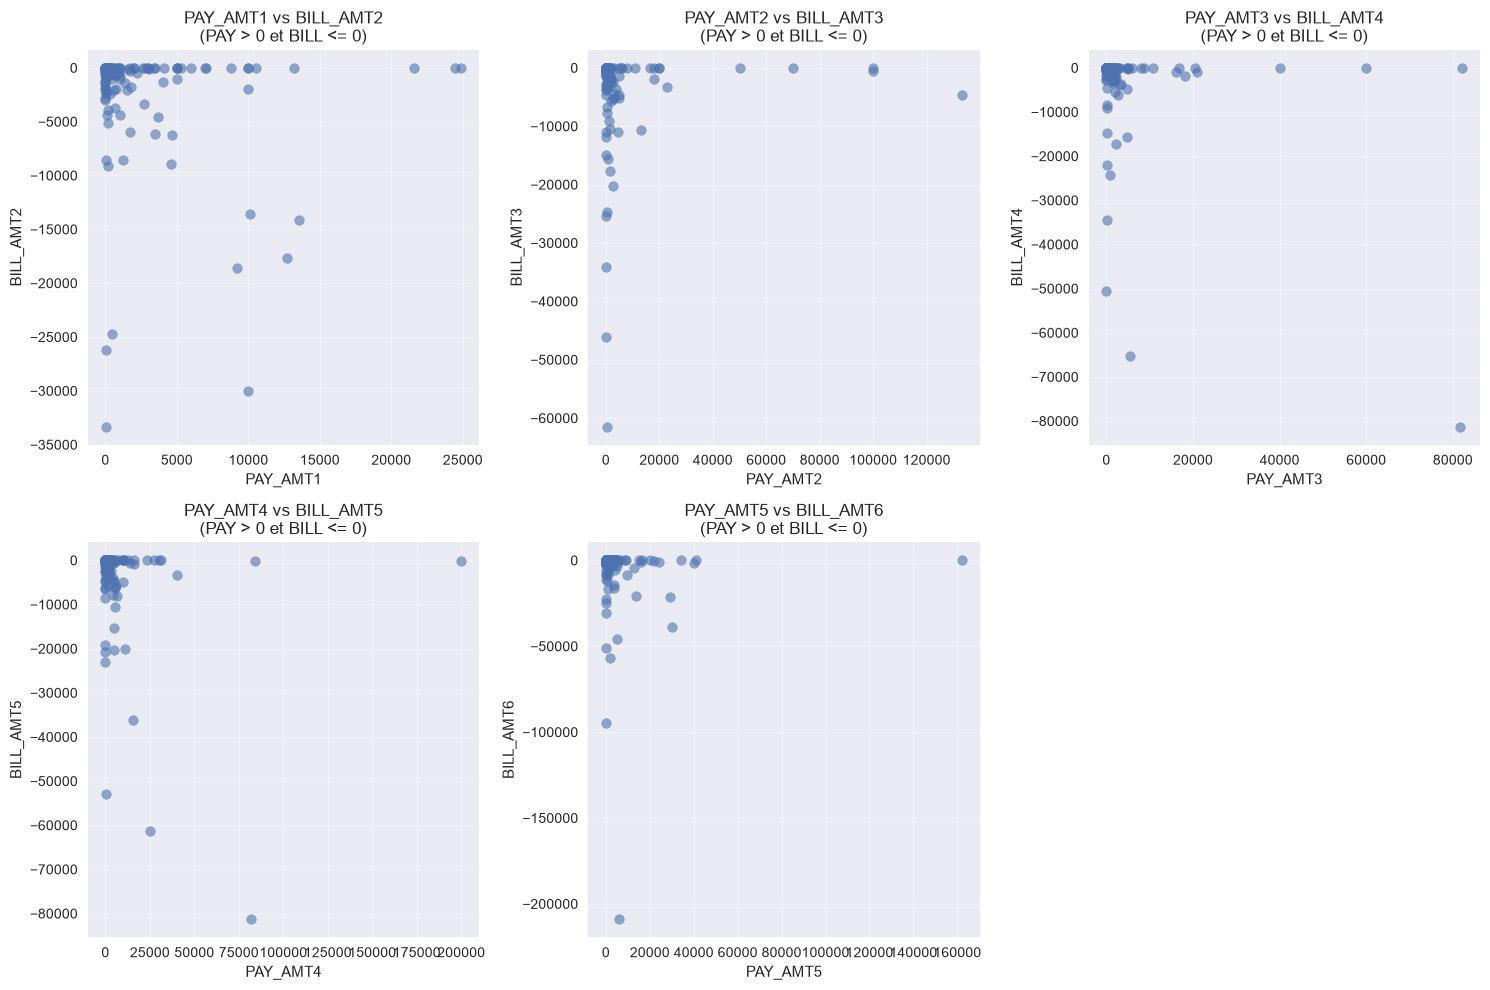


Analyse des cas extrêmes :

PAY_AMT1 / BILL_AMT2:
  Nombre de cas : 144
  PAY max : 24890
  BILL min : -33350

PAY_AMT2 / BILL_AMT3:
  Nombre de cas : 161
  PAY max : 133122
  BILL min : -61506

PAY_AMT3 / BILL_AMT4:
  Nombre de cas : 171
  PAY max : 82150
  BILL min : -81334

PAY_AMT4 / BILL_AMT5:
  Nombre de cas : 178
  PAY max : 200000
  BILL min : -81334

PAY_AMT5 / BILL_AMT6:
  Nombre de cas : 177
  PAY max : 162000
  BILL min : -209051

Résumé global :
Total de cas où PAY_AMTn > 0 et BILL_AMTn+1 <= 0 : 831


In [43]:
import pandas as pd
import numpy as np

# Vérification des cas où PAY_AMTn est positif mais BILL_AMTn+1 <= 0
print("Analyse des cas où PAY_AMTn > 0 et BILL_AMTn+1 <= 0 :")

# Colonnes de paiement et de facturation
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Création d'une liste pour stocker les résultats
results = []

for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    # Identifier les lignes où PAY_AMTn > 0 ET BILL_AMTn+1 <= 0
    condition = (df[pay_col] > 0) & (df[bill_col] <= 0)
    filtered_data = df[condition]
    
    count = len(filtered_data)
    if count > 0:
        # Calcul des statistiques sur ces données
        mean_pay = filtered_data[pay_col].mean()
        mean_bill = filtered_data[bill_col].mean()
        
        results.append({
            'Paire': f'{pay_col} > 0 et {bill_col} <= 0',
            'Nombre d\'observations': count,
            'Moyenne {pay_col}': round(mean_pay, 2),
            'Moyenne {bill_col}': round(mean_bill, 2),
            'Ratio moyen': round(mean_pay / mean_bill * 100, 2) if mean_bill != 0 else None
        })
    else:
        results.append({
            'Paire': f'{pay_col} > 0 et {bill_col} <= 0',
            'Nombre d\'observations': 0,
            'Moyenne {pay_col}': None,
            'Moyenne {bill_col}': None,
            'Ratio moyen': None
        })

# Création du tableau de résultats
results_df = pd.DataFrame(results)
print("Cas où PAY_AMTn > 0 et BILL_AMTn+1 <= 0 :")
print(results_df.to_string(index=False))

# Analyse plus détaillée : compter combien de fois chaque condition est remplie
print("\nAnalyse globale des conditions :")

# Compter les cas pour chaque paire
for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    # Cas 1 : PAY_AMTn > 0 et BILL_AMTn+1 <= 0
    condition1 = (df[pay_col] > 0) & (df[bill_col] <= 0)
    
    # Cas 2 : PAY_AMTn <= 0 et BILL_AMTn+1 > 0  
    condition2 = (df[pay_col] <= 0) & (df[bill_col] > 0)
    
    # Cas 3 : PAY_AMTn > 0 et BILL_AMTn+1 > 0
    condition3 = (df[pay_col] > 0) & (df[bill_col] > 0)
    
    # Cas 4 : PAY_AMTn <= 0 et BILL_AMTn+1 <= 0
    condition4 = (df[pay_col] <= 0) & (df[bill_col] <= 0)
    
    print(f"\n{pay_col} / {bill_col}:")
    print(f"  PAY > 0 et BILL <= 0 : {condition1.sum()}")
    print(f"  PAY <= 0 et BILL > 0 : {condition2.sum()}")
    print(f"  PAY > 0 et BILL > 0 : {condition3.sum()}")
    print(f"  PAY <= 0 et BILL <= 0 : {condition4.sum()}")

# Visualisation de la distribution des paiements et factures
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

# Histogramme pour chaque paire
for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    plt.subplot(2, 3, i+1)
    
    # Filtrer les données pour cette paire
    condition = (df[pay_col] > 0) & (df[bill_col] <= 0)
    data = df[condition]
    
    if len(data) > 0:
        plt.scatter(data[pay_col], data[bill_col], alpha=0.6)
        plt.xlabel(f'{pay_col}')
        plt.ylabel(f'{bill_col}')
        plt.title(f'{pay_col} vs {bill_col}\n(PAY > 0 et BILL <= 0)')
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'Aucune donnée', ha='center', va='center', transform=plt.gca().transAxes)
        plt.title(f'{pay_col} vs {bill_col}\n(PAY > 0 et BILL <= 0)')

plt.tight_layout()
plt.show()

# Analyse des cas extrêmes
print("\nAnalyse des cas extrêmes :")

# Identifier les valeurs maximales et minimales dans chaque colonne
for pay_col, bill_col in zip(payment_columns, bill_columns):
    print(f"\n{pay_col} / {bill_col}:")
    
    # Cas où PAY > 0 et BILL <= 0
    condition = (df[pay_col] > 0) & (df[bill_col] <= 0)
    extreme_data = df[condition]
    
    if len(extreme_data) > 0:
        print(f"  Nombre de cas : {len(extreme_data)}")
        print(f"  PAY max : {extreme_data[pay_col].max()}")
        print(f"  BILL min : {extreme_data[bill_col].min()}")
    else:
        print("  Aucun cas trouvé")

# Résumé global
print("\nRésumé global :")
total_cases = sum([len(df[(df[pay_col] > 0) & (df[bill_col] <= 0)]) 
                   for pay_col, bill_col in zip(payment_columns, bill_columns)])
print(f"Total de cas où PAY_AMTn > 0 et BILL_AMTn+1 <= 0 : {total_cases}")

trouver une mensualité payée sur un encours nul ou négatif est un non-sens métier  
les anomalies sont elles groupées sur 200 lignes ou sont elles 1000 lignes distinctes ?

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. INITIALISATION DES VARIABLES
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Ensemble global pour compter les LIGNES DISTINCTES
unique_problematic_lines = set()

# Dictionnaire pour stocker les indices spécifiques à chaque paire (utile pour l'analyse détaillée)
pairs_indices = {}

print("Analyse des paiements effectués sur un encours <= 0 :\n")

# Itération sur chaque mois pour identifier les conditions
for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    # Condition : Paiement > 0 ET Encours (Facture précédente) <= 0
    condition = (df[pay_col] > 0) & (df[bill_col] <= 0)
    
    # Récupération des indices de lignes pour cette paire spécifique
    current_indices = set(df[condition].index)
    
    # Ajout à l'ensemble global (gère l'unicité automatique)
    unique_problematic_lines.update(current_indices)
    
    print(f"--- {pay_col} vs {bill_col} ---")
    print(f"Lignes spécifiques à cette paire : {len(current_indices)}")
    
    pairs_indices[f"{pay_col} (sur {bill_col})"] = current_indices

# 2. RÉSULTAT PRINCIPAL : NOMBRE DE LIGNES DISTINCTES
print("\n" + "="*50)
print(f"TOTAL DES LIGNES DISTINCTES AVEC AU MOINS UN PAIEMENT SUR ENCOURS <= 0")
print(f"Nombre de clients/lignes concernés : {len(unique_problematic_lines)}")
print(f"Pourcentage du dataset : {len(unique_problematic_lines)/len(df)*100:.2f}%")
print("="*50)

# Récupération des index sous forme de liste pour manipuler le DataFrame
list_unique_lines = list(unique_problematic_lines)

# 3. AFFICHAGE D'UN EXEMPLE DE 10 LIGNES
print("\n--- Exemple de 10 lignes concernées ---")
# On prend les 10 premiers index trouvés
if len(list_unique_lines) > 0:
    sample_indices = list_unique_lines[:10]
    
    # Sélection des colonnes pertinentes pour l'analyse visuelle
    columns_to_show = payment_columns + bill_columns + ['SEX', 'EDUCATION', 'MARRIAGE']
    
    df_sample = df.loc[sample_indices, columns_to_show].copy()
    
    # Pour plus de clarté, on colorie ou indique simplement les données brutes
    print(df_sample.to_string())
else:
    print("Aucune ligne concernée.")

# 4. ANALYSE DE LA RÉCURRENCE (Optionnel mais informatif)
recurrence = {line: 0 for line in unique_problematic_lines}
for indices_set in pairs_indices.values():
    for line in indices_set:
        recurrence[line] += 1

clients_multi_fois = {line: count for line, count in recurrence.items() if count > 1}
print(f"\n--- Analyse de récurrence ---")
print(f"Lignes concernées par PLUSIEURS mois : {len(clients_multi_fois)}")

# 5. TABLEAU RÉCAPITULATIF STATISTIQUE PAR PAIRE (sur l'ensemble unique)
stats_list = []
for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    # Intersection : lignes qui ont payé >0 sur cette facture <=0 ET qui sont dans notre ensemble global
    valid_indices = pairs_indices[f"{pay_col} (sur {bill_col})"].intersection(unique_problematic_lines)
    
    if len(valid_indices) > 0:
        sub_df = df.loc[list(valid_indices)]
        mean_pay = sub_df[pay_col].mean()
        std_pay = sub_df[pay_col].std()
        
        stats_list.append({
            'Paire': f'{pay_col} / {bill_col}',
            'Nb Lignes Distinctes dans ce lot': len(valid_indices),
            'Moyenne Payée': round(mean_pay, 2),
            'Ecart-Type': round(std_pay, 2)
        })

if stats_list:
    df_stats = pd.DataFrame(stats_list)
    print("\n--- Tableau détaillé par paire (sur les lignes distinctes globales) ---")
    print(df_stats.to_string(index=False))

Analyse des paiements effectués sur un encours <= 0 :

--- PAY_AMT1 vs BILL_AMT2 ---
Lignes spécifiques à cette paire : 144
--- PAY_AMT2 vs BILL_AMT3 ---
Lignes spécifiques à cette paire : 161
--- PAY_AMT3 vs BILL_AMT4 ---
Lignes spécifiques à cette paire : 171
--- PAY_AMT4 vs BILL_AMT5 ---
Lignes spécifiques à cette paire : 178
--- PAY_AMT5 vs BILL_AMT6 ---
Lignes spécifiques à cette paire : 177

TOTAL DES LIGNES DISTINCTES AVEC AU MOINS UN PAIEMENT SUR ENCOURS <= 0
Nombre de clients/lignes concernés : 690
Pourcentage du dataset : 2.30%

--- Exemple de 10 lignes concernées ---
       PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  SEX  EDUCATION  MARRIAGE
ID                                                                                                                                      
12293      5000     15066      5007         0      3000     113974     126194      17832      -3000          0    2          2         2
8198

Les 10 lignes montrées en exemple montrent clairement un remboursement trop important qui a mené à un encours négatif.  
Ces lignes atypiques correspondent en grande partie à des situations plausibles.  
Je n'y touche pas

In [45]:
import pandas as pd
import numpy as np

# Définition des colonnes
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

print("Calcul des ratios conditionnels (uniquement si BILL > 0) :\n")

for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    new_col_name = f'ratio_{pay_col}_to_{bill_col}'
    
    # Création de la nouvelle colonne initialisée à NaN
    df[new_col_name] = np.nan
    
    # Sélection des lignes où la facture (dénominateur) est strictement positive
    valid_mask = df[bill_col] > 0
    
    if valid_mask.any():
        # Calcul du ratio uniquement sur les lignes valides
        # On évite ainsi la division par zéro ou par un négatif
        df.loc[valid_mask, new_col_name] = (df.loc[valid_mask, pay_col] / df.loc[valid_mask, bill_col]) * 100
        
        print(f"- {new_col_name}: Calculé sur {valid_mask.sum()} lignes valides")
    else:
        print(f"- {new_col_name}: Aucune facture positive trouvée ({bill_col} <= 0 pour tous), colonne vide (NaN).")

# Affichage des nouvelles colonnes créées
print("\nNouvelles colonnes créées :")
for i, (pay_col, bill_col) in enumerate(zip(payment_columns, bill_columns)):
    new_col_name = f'ratio_{pay_col}_to_{bill_col}'
    print(f"- {new_col_name}")

# Vérification rapide pour voir combien de NaN il y a dans une colonne exemple
example_col = 'ratio_PAY_AMT1_to_BILL_AMT2'
print(f"\nVérification sur '{example_col}':")
print(f" - Valeurs valides (non-NaN) : {df[example_col].notna().sum()}")
print(f" - Valeurs NaN : {df[example_col].isna().sum()}")

Calcul des ratios conditionnels (uniquement si BILL > 0) :

- ratio_PAY_AMT1_to_BILL_AMT2: Calculé sur 26823 lignes valides
- ratio_PAY_AMT2_to_BILL_AMT3: Calculé sur 26471 lignes valides
- ratio_PAY_AMT3_to_BILL_AMT4: Calculé sur 26126 lignes valides
- ratio_PAY_AMT4_to_BILL_AMT5: Calculé sur 25835 lignes valides
- ratio_PAY_AMT5_to_BILL_AMT6: Calculé sur 25288 lignes valides

Nouvelles colonnes créées :
- ratio_PAY_AMT1_to_BILL_AMT2
- ratio_PAY_AMT2_to_BILL_AMT3
- ratio_PAY_AMT3_to_BILL_AMT4
- ratio_PAY_AMT4_to_BILL_AMT5
- ratio_PAY_AMT5_to_BILL_AMT6

Vérification sur 'ratio_PAY_AMT1_to_BILL_AMT2':
 - Valeurs valides (non-NaN) : 26823
 - Valeurs NaN : 3173


In [46]:
import pandas as pd
import numpy as np

# Définition des colonnes de ratio
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

ratio_columns = [f'ratio_{pay}_to_{bill}' for pay, bill in zip(payment_columns, bill_columns)]

# Liste pour stocker les statistiques par colonne
stats_data = []

print("--- Statistiques Descriptives des Ratios ---\n")

for col in ratio_columns:
    # On filtre les valeurs non NaN pour éviter les erreurs de calcul
    clean_values = df[col].dropna()
    
    if len(clean_values) > 0:
        min_val = clean_values.min()
        mean_val = clean_values.mean()
        median_val = clean_values.median()
        max_val = clean_values.max()
        
        stats_data.append({
            'Colonne': col,
            'Min': round(min_val, 2),
            'Moyenne': round(mean_val, 2),
            'Médiane': round(median_val, 2),
            'Max': round(max_val, 2)
        })

# Création du DataFrame de statistiques
df_stats = pd.DataFrame(stats_data)

print(df_stats.to_string(index=False))

# Optionnel : Afficher la distribution globale de toutes ces colonnes combinées
all_ratios = df[ratio_columns].stack().dropna()
print(f"\n--- Statistiques Globales (tous ratios confondus) ---")
print(f"Min Global: {all_ratios.min():.2f}")
print(f"Moyenne Globale: {all_ratios.mean():.2f}")
print(f"Médiane Globale: {all_ratios.median():.2f}")
print(f"Max Global: {all_ratios.max():.2f}")

--- Statistiques Descriptives des Ratios ---

                    Colonne  Min  Moyenne  Médiane       Max
ratio_PAY_AMT1_to_BILL_AMT2  0.0    52.97     7.83 444433.33
ratio_PAY_AMT2_to_BILL_AMT3  0.0    73.52     7.75 500100.00
ratio_PAY_AMT3_to_BILL_AMT4  0.0    52.11     6.17 444433.33
ratio_PAY_AMT4_to_BILL_AMT5  0.0    34.89     5.17  12970.51
ratio_PAY_AMT5_to_BILL_AMT6  0.0    42.18     5.59  69065.52

--- Statistiques Globales (tous ratios confondus) ---
Min Global: 0.00
Moyenne Globale: 51.30
Médiane Globale: 6.57
Max Global: 500100.00


In [47]:
import pandas as pd

# Définition des colonnes de ratio créées précédemment
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

ratio_columns = [f'ratio_{pay}_to_{bill}' for pay, bill in zip(payment_columns, bill_columns)]

# 1. Compter les lignes avec au moins un ratio > 100%
count_high_ratio = df[ratio_columns].gt(100).any(axis=1).sum()

print(f"Nombre de lignes montrant un ratio > 100% : {count_high_ratio}")

# 2. Afficher les détails (optionnel, pour vérifier)
if count_high_ratio > 0:
    df_with_high_ratio = df[df[ratio_columns].gt(100).any(axis=1)]
    print("\n--- Exemple de lignes concernées ---")
    # On montre les ratios concernés surlignés
    cols_display = ratio_columns
    print(df_with_high_ratio[cols_display].head(5).to_string())

Nombre de lignes montrant un ratio > 100% : 5934

--- Exemple de lignes concernées ---
    ratio_PAY_AMT1_to_BILL_AMT2  ratio_PAY_AMT2_to_BILL_AMT3  ratio_PAY_AMT3_to_BILL_AMT4  ratio_PAY_AMT4_to_BILL_AMT5  ratio_PAY_AMT5_to_BILL_AMT6
ID                                                                                                                                                 
5                     35.273369                   102.360820                    47.755492                    47.007208                     3.601485
8                    100.000000                   100.000000                     0.000000                          NaN                   297.530864
11                    23.561868                     0.216802                     1.989654                    16.411379                   100.187617
12                   100.682972                   100.000000                   100.774921                   100.062817                     0.000000
18                     4.

In [48]:
import pandas as pd

# Définition des colonnes de ratio créées précédemment
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

ratio_columns = [f'ratio_{pay}_to_{bill}' for pay, bill in zip(payment_columns, bill_columns)]

# 1. Compter les lignes avec au moins un ratio > 120%
count_high_ratio = df[ratio_columns].gt(120).any(axis=1).sum()

print(f"Nombre de lignes montrant un ratio > 120% : {count_high_ratio}")

# 2. Afficher les détails (optionnel, pour vérifier)
if count_high_ratio > 0:
    df_with_high_ratio = df[df[ratio_columns].gt(120).any(axis=1)]
    print("\n--- Exemple de lignes concernées ---")
    # On montre les ratios concernés surlignés
    cols_display = ratio_columns
    print(df_with_high_ratio[cols_display].head(5).to_string())

Nombre de lignes montrant un ratio > 120% : 1445

--- Exemple de lignes concernées ---
    ratio_PAY_AMT1_to_BILL_AMT2  ratio_PAY_AMT2_to_BILL_AMT3  ratio_PAY_AMT3_to_BILL_AMT4  ratio_PAY_AMT4_to_BILL_AMT5  ratio_PAY_AMT5_to_BILL_AMT6
ID                                                                                                                                                 
8                    100.000000                   100.000000                     0.000000                          NaN                   297.530864
18                     4.201415                     5.137083                   108.371150                   341.530055                   100.000000
27                          NaN                   386.100386                          NaN                   393.700787                          NaN
38                    15.296757                    13.715215                    33.903087                          NaN                   255.471597
62                     5.

In [49]:
import pandas as pd

# Définition des colonnes de ratio créées précédemment
payment_columns = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5']
bill_columns = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

ratio_columns = [f'ratio_{pay}_to_{bill}' for pay, bill in zip(payment_columns, bill_columns)]

# 1. Filtrage des lignes avec au moins un ratio > 1000%
mask_extreme_ratio = df[ratio_columns].gt(1000).any(axis=1)
df_with_high_ratio = df[mask_extreme_ratio]

print(f"Nombre de lignes montrant un ratio > 1000% : {len(df_with_high_ratio)}")

# 2. Affichage des lignes complètes
if len(df_with_high_ratio) > 0:
    print("\n--- Lignes complètes avec Ratio > 1000% ---")
    # On affiche les 5 premières lignes pour l'exemple
    # Tu peux enlever .head(5) si tu veux tout voir (attention à la longueur)
    print(df_with_high_ratio.head(5).to_string())
else:
    print("Aucune ligne trouvée.")

Nombre de lignes montrant un ratio > 1000% : 89

--- Lignes complètes avec Ratio > 1000% ---
     LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  dpnm  ratio_PAY_AMT1_to_BILL_AMT2  ratio_PAY_AMT2_to_BILL_AMT3  ratio_PAY_AMT3_to_BILL_AMT4  ratio_PAY_AMT4_to_BILL_AMT5  ratio_PAY_AMT5_to_BILL_AMT6
ID                                                                                                                                                                                                                                                                                                                                                                          
344     180000    1          1         1   39      0      0     -1      0      0     -1     274731     281713     242063     122295      -1005       1005     11000    145000    

--- Analyse des Valeurs Aberrantes ---

                    Colonne  Min Aberrant  Max Aberrant  Nombre d'aberrations  Borne Basse (Q1-1.5*IQR)  Borne Haute (Q3+1.5*IQR)
ratio_PAY_AMT1_to_BILL_AMT2    248.819876 444433.333333                    78                   -139.29                    243.58
ratio_PAY_AMT2_to_BILL_AMT3    245.766773 500100.000000                    89                   -139.40                    243.64
ratio_PAY_AMT3_to_BILL_AMT4    233.333333 444433.333333                   104                   -134.17                    233.30
ratio_PAY_AMT4_to_BILL_AMT5    201.827676  12970.512821                   132                   -115.26                    201.64
ratio_PAY_AMT5_to_BILL_AMT6    246.366559  69065.517241                    92                   -140.81                    244.49


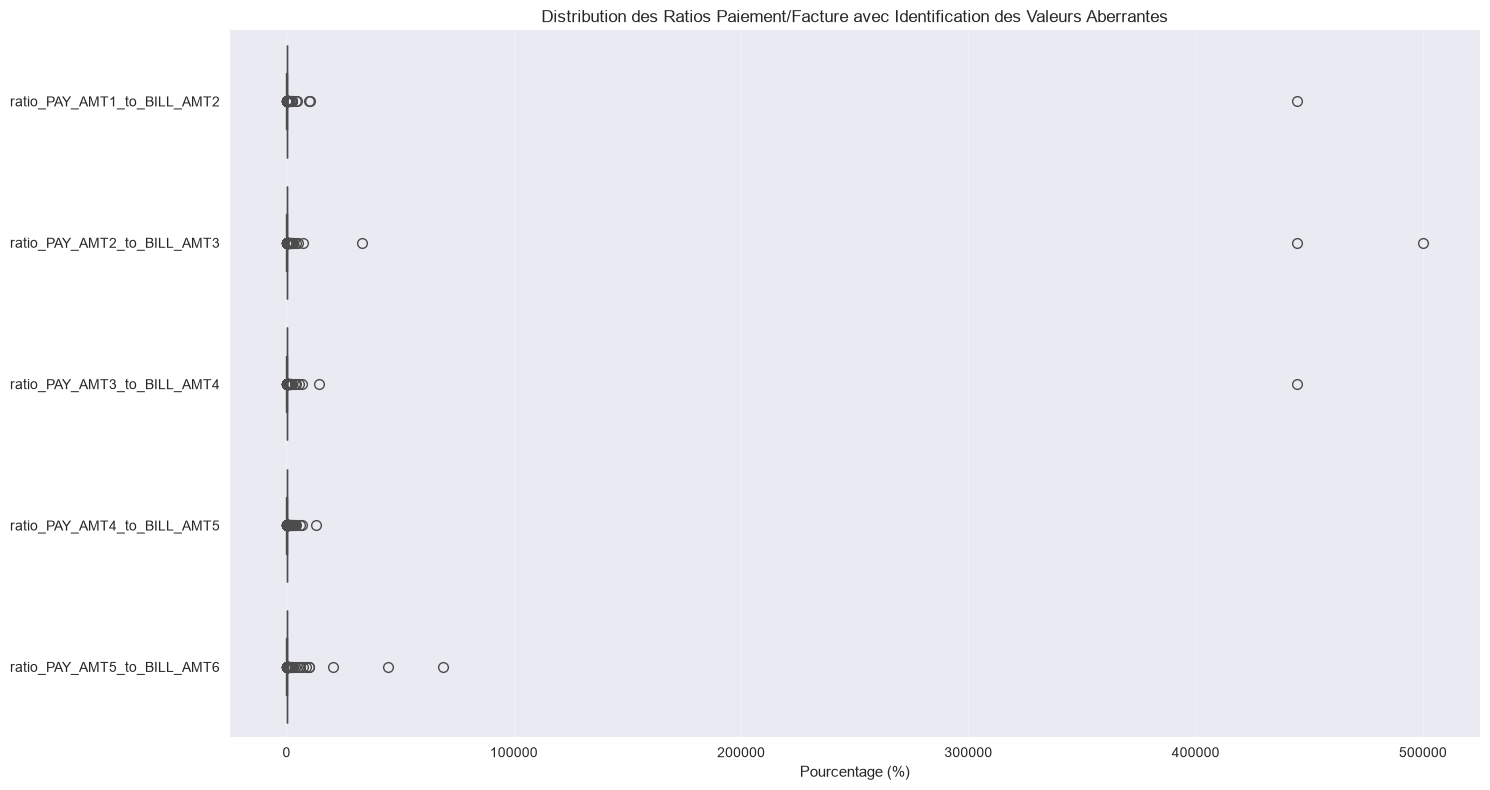

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ratio_columns = [f'ratio_{pay}_to_{bill}' for pay, bill in zip(
    ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5'],
    ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
)]

# 1. DÉFINITION DES VALEURS ABERRANTES (Outliers)
# Une valeur est aberrante si elle est < Q1 - 1.5*IQR ou > Q3 + 1.5*IQR
def find_outliers_stats(df_col):
    """Calcule les bornes d'aberration pour une série de données"""
    q1 = df_col.quantile(0.25)
    q3 = df_col.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound

# Liste pour stocker les résultats statistiques par colonne
outlier_stats = []

print("--- Analyse des Valeurs Aberrantes ---\n")

for col in ratio_columns:
    # On travaille sur les données non nulles/NaN
    clean_data = df[col].dropna()
    
    if len(clean_data) < 10: 
        continue
        
    lower, upper = find_outliers_stats(clean_data)
    
    # Identification des valeurs aberrantes
    outliers = clean_data[(clean_data < lower) | (clean_data > upper)]
    
    outlier_stats.append({
        'Colonne': col,
        'Min Aberrant': min(outliers) if len(outliers) > 0 else None,
        'Max Aberrant': max(outliers) if len(outliers) > 0 else None,
        'Nombre d\'aberrations': len(outliers),
        'Borne Basse (Q1-1.5*IQR)': round(lower, 2),
        'Borne Haute (Q3+1.5*IQR)': round(upper, 2)
    })

# Tableau récapitulatif des aberrations
df_outliers = pd.DataFrame(outlier_stats)
print(df_outliers.to_string(index=False))

# 2. VISUALISATION DES VALEURS ABERRANTES (Boxplots)
plt.figure(figsize=(15, 8))

# On filtre le dataframe pour ne garder que les colonnes de ratio
df_ratios = df[ratio_columns]

# Boxplot global pour voir la distribution et identifier visuellement les points aberrants (losanges)
sns.boxplot(data=df_ratios, patch_artist=True, orient='h')
plt.title('Distribution des Ratios Paiement/Facture avec Identification des Valeurs Aberrantes')
plt.xlabel('Pourcentage (%)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()



pour l'ID 344 on devine une anomalie : la somme due passe de 1005 à -1005 et le client a payé 101005, une coquille s'est probablement glissé dans le paiement.  
Les autres lignes ne présentent pas d'anomalie qui saute aux yeux.  
Corriger des lignes manuellement est impossible.  
Les modes de paiement et habitudes de 2005 suggèrent que les clients payaient parfois avec un peu d'avance ou un peu de retard et créent des distorsions sur certaines période.  De plus, certains paiements pouvaient être saisis à la main dans des bureau de tabac ou des bureaux de poste. Ces features ne sont pas exploitables en tant que tel pour visualisation, comparaison, mais des modèles de ML pourraient y voir les tendances.  
Il faudrait peut etre créer une sorte de feature glissante où on regarde plusieurs mois pour lisser les extremes et les décalages de paiements.  
Appliquons la meme limite de 2,1 que pour les paiements sur plafond pour voir ce qu'on trouve :  

In [51]:
import pandas as pd

# 1. Définition des colonnes cibles
colonnes_ratio = [
    'ratio_PAY_AMT1_to_BILL_AMT2',
    'ratio_PAY_AMT2_to_BILL_AMT3',
    'ratio_PAY_AMT3_to_BILL_AMT4',
    'ratio_PAY_AMT4_to_BILL_AMT5',
    'ratio_PAY_AMT5_to_BILL_AMT6'
]

# Filtrer pour ne garder que celles qui existent dans ton dataframe
colonnes_presentes = [col for col in colonnes_ratio if col in df.columns]

if len(colonnes_presentes) > 0:
    # 2. Identification des lignes où AU MOINS une colonne est > 210
    # On crée un masque (booléen True/False) pour chaque colonne
    masque_anomalies = pd.Series([False] * len(df), index=df.index)
    
    for col in colonnes_presentes:
        # Condition stricte : > 210 (donc plus de 210%)
        masque_anomalies = masque_anomalies | (df[col] > 210)
    
    nb_lignes_totales = len(df)
    nb_anomalies = masque_anomalies.sum()

    print(f"--- Analyse des Ratios de Paiement > 210% ---")
    print(f"Total lignes dans le dataset : {nb_lignes_totales}")
    print(f"Lignes avec AU MOINS un ratio > 210 : {nb_anomalies}")
    
    if nb_anomalies > 0:
        # 3. Extraction et affichage des 10 lignes complètes
        # On trie par la valeur maximale de ces ratios pour voir les cas les plus extrêmes en premier
        df_anomalies = df[masque_anomalies].copy()
        
        # On calcule le max de ces colonnes pour chaque ligne afin de trier
        df_anomalies['Max_Ratio'] = df_anomalies[colonnes_presentes].max(axis=1)
        df_anomalies_sorted = df_anomalies.sort_values(by='Max_Ratio', ascending=False)
        
        # On affiche les 10 premières lignes complètes
        print("\n--- Les 10 cas extrêmes (Raisonnements possibles : Rattrapage de dette ou Erreur) ---")
        print(df_anomalies_sorted.head(10).drop(columns=['Max_Ratio']).to_string())
    else:
        print("\nAucune ligne trouvée avec un ratio > 210.")

else:
    print("Colonnes de ratio non trouvées dans le dataframe.")

--- Analyse des Ratios de Paiement > 210% ---
Total lignes dans le dataset : 29996
Lignes avec AU MOINS un ratio > 210 : 486

--- Les 10 cas extrêmes (Raisonnements possibles : Rattrapage de dette ou Erreur) ---
       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  dpnm  ratio_PAY_AMT1_to_BILL_AMT2  ratio_PAY_AMT2_to_BILL_AMT3  ratio_PAY_AMT3_to_BILL_AMT4  ratio_PAY_AMT4_to_BILL_AMT5  ratio_PAY_AMT5_to_BILL_AMT6
ID                                                                                                                                                                                                                                                                                                                                                                            
21349      70000    1          1         1   67      1

480 lignes présentent un paiement > 210% du montant dû le mois précédent, soit 1.6% du dataset.  
Des anomalies falgrantes apparaissent sur certaines lignes ci dessus (encore des montant multipliés par 100 par exemple).  
On peut retranscrire ce qu'on a dit sur les paiements et leur délai de comptabilisation également pour les utilisations car si un client retire de l'argent à un bureau de poste, il se peut que le montant soit mal saisi, ne soit pas comptabilisé pour le mois en cours...  
Corriger ces lignes aberrantes est impossible.  
Mais on pourrait limiter ces valeurs extrêmes en ne calculant les colonnes ratios qu'à partir non pas de BILL_AMT > 0 mais un autre montant par exemple 100 :  



--- Analyse des Valeurs Aberrantes avec Volumétrie (BILL_AMT >= 100) ---

                    Colonne  Lignes Initiales  Lignes Conservées  Lignes Filtrées (<100) % Filtré  Aberrations (IQR)  Borne Basse  Borne Haute
ratio_PAY_AMT1_to_BILL_AMT2             26823              26758                      65    0.24%                 70      -139.30       243.58
ratio_PAY_AMT2_to_BILL_AMT3             26471              26411                      60    0.23%                 82      -139.40       243.64
ratio_PAY_AMT3_to_BILL_AMT4             26126              26071                      55    0.21%                 99      -131.96       229.62
ratio_PAY_AMT4_to_BILL_AMT5             25835              25761                      74    0.29%                157      -110.86       194.31
ratio_PAY_AMT5_to_BILL_AMT6             25288              25220                      68    0.27%                 84      -140.81       244.49


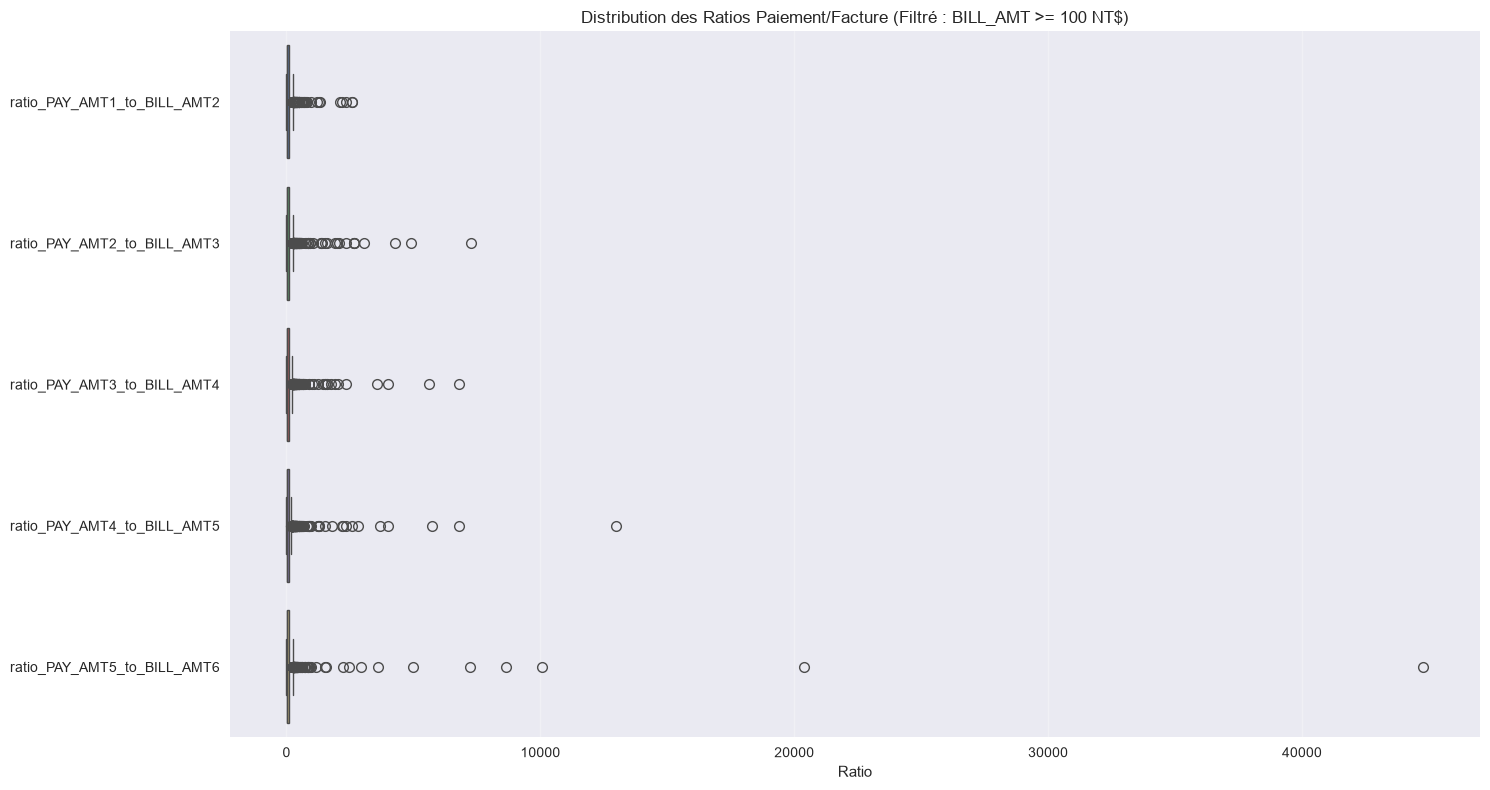

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pairs = [
    ('PAY_AMT1', 'BILL_AMT2'),
    ('PAY_AMT2', 'BILL_AMT3'),
    ('PAY_AMT3', 'BILL_AMT4'),
    ('PAY_AMT4', 'BILL_AMT5'),
    ('PAY_AMT5', 'BILL_AMT6')
]

outlier_stats = []
df_ratios_filtered = pd.DataFrame()

print("--- Analyse des Valeurs Aberrantes avec Volumétrie (BILL_AMT >= 100) ---\n")

for pay_col, bill_col in pairs:
    ratio_col = f'ratio_{pay_col}_to_{bill_col}'
    
    # Masque appliqué à la facture du mois correspondant
    mask = df[bill_col] >= 100
    
    # Population initiale non nulle sur ce ratio
    raw_data = df[ratio_col].dropna()
    n_initial = len(raw_data)
    
    # Population conservée après masque (BILL_AMT >= 100)
    clean_data = df.loc[mask, ratio_col].dropna()
    n_kept = len(clean_data)
    
    # Volumétrie éliminée par le masque
    n_eliminated = n_initial - n_kept
    pct_eliminated = (n_eliminated / n_initial * 100) if n_initial > 0 else 0.0
    
    # Stockage des valeurs filtrées pour la visualisation
    df_ratios_filtered[ratio_col] = df[ratio_col].where(mask)
    
    if n_kept < 10: 
        continue
        
    lower, upper = find_outliers_stats(clean_data)
    
    # Outliers statistiques (IQR) sur la population filtrée
    outliers = clean_data[(clean_data < lower) | (clean_data > upper)]
    
    outlier_stats.append({
        'Colonne': ratio_col,
        'Lignes Initiales': n_initial,
        'Lignes Conservées': n_kept,
        'Lignes Filtrées (<100)': n_eliminated,
        '% Filtré': f"{pct_eliminated:.2f}%",
        'Aberrations (IQR)': len(outliers),
        'Borne Basse': round(lower, 2),
        'Borne Haute': round(upper, 2)
    })

# Tableau récapitulatif
df_outliers = pd.DataFrame(outlier_stats)
print(df_outliers.to_string(index=False))

# Visualisation des Boxplots (sur données filtrées)
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_ratios_filtered, patch_artist=True, orient='h')
plt.title('Distribution des Ratios Paiement/Facture (Filtré : BILL_AMT >= 100 NT$)')
plt.xlabel('Ratio')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Même à 200 de cut off, 2 valeurs sortent du lot à 20 000 et 45 000%.  
Afin de vérifier la cohérence, regardons quelques lignes en détail

In [53]:
import pandas as pd
import numpy as np

# 1. Définition stricte des colonnes de ratio et de leur dénominateur BILL_AMT correspondante
paires = [
    ('ratio_PAY_AMT1_to_BILL_AMT2', 'BILL_AMT2'),
    ('ratio_PAY_AMT2_to_BILL_AMT3', 'BILL_AMT3'),
    ('ratio_PAY_AMT3_to_BILL_AMT4', 'BILL_AMT4'),
    ('ratio_PAY_AMT4_to_BILL_AMT5', 'BILL_AMT5'),
    ('ratio_PAY_AMT5_to_BILL_AMT6', 'BILL_AMT6')
]

lignes_anormales_details = []

print("--- Analyse : Ratios > 1000% avec Facture BILL_AMT >= 100 ---\n")

for col_ratio, col_bill in paires:
    if col_ratio not in df.columns or col_bill not in df.columns:
        continue
    
    # Condition 1 : Le ratio est extrêmement élevé (> 1000)
    condition_ratio = df[col_ratio] > 1000
    
    # Condition 2 : La facture associée est structurante (>= 100)
    condition_facture = df[col_bill] >= 100
    
    # Intersection stricte
    mask_anomalie = condition_ratio & condition_facture
    
    nb_cas = mask_anomalie.sum()
    
    if nb_cas > 0:
        print(f"[{col_ratio}] : {nb_cas} cas trouvés avec BILL_AMT >= 100 ET Ratio > 1000")
        
        df_cas = df[mask_anomalie].copy()
        df_cas['Source_Ratio'] = col_ratio
        df_cas['Facture_Source'] = col_bill
        
        # Tri pour voir les plus extrêmes
        df_cas = df_cas.sort_values(by=col_ratio, ascending=False)
        
        lignes_anormales_details.append(df_cas.head(10))

# 3. Affichage Global
if lignes_anormales_details:
    df_anomalies_final = pd.concat(lignes_anormales_details).drop_duplicates()
    
    print(f"\n--- Résumé Global ---")
    print(f"Total de cas uniques identifiés : {len(df_anomalies_final)}")
    
    print(f"\n--- Les 10 lignes les plus extrêmes (Complètes) ---")
    display_data = df_anomalies_final.head(10).drop(columns=['Source_Ratio', 'Facture_Source'])
    
    # Affichage de toutes les colonnes pour vérification
    print(display_data.to_string())

else:
    print("\n--- RÉSULTAT NÉGATIF ---")
    print("Aucune ligne ne répond à la fois à : Ratio > 1000 ET BILL_AMT >= 100.")
    print("Conclusion : Les ratios > 1000% sont exclusivement liés à des factures < 100€ (micro-dettes).")
    
    # Vérification complémentaire : combien de ratios > 1000 existent sans filtre de facture ?
    total_extremes = 0
    for col_ratio, _ in paires:
        if col_ratio in df.columns:
            total_extremes += (df[col_ratio] > 1000).sum()
    
    print(f"\nTotal de ratios > 1000 sur tout le dataset (sans filtre facture) : {total_extremes}")

--- Analyse : Ratios > 1000% avec Facture BILL_AMT >= 100 ---

[ratio_PAY_AMT1_to_BILL_AMT2] : 8 cas trouvés avec BILL_AMT >= 100 ET Ratio > 1000
[ratio_PAY_AMT2_to_BILL_AMT3] : 17 cas trouvés avec BILL_AMT >= 100 ET Ratio > 1000
[ratio_PAY_AMT3_to_BILL_AMT4] : 16 cas trouvés avec BILL_AMT >= 100 ET Ratio > 1000
[ratio_PAY_AMT4_to_BILL_AMT5] : 16 cas trouvés avec BILL_AMT >= 100 ET Ratio > 1000
[ratio_PAY_AMT5_to_BILL_AMT6] : 13 cas trouvés avec BILL_AMT >= 100 ET Ratio > 1000

--- Résumé Global ---
Total de cas uniques identifiés : 48

--- Les 10 lignes les plus extrêmes (Complètes) ---
       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  dpnm  ratio_PAY_AMT1_to_BILL_AMT2  ratio_PAY_AMT2_to_BILL_AMT3  ratio_PAY_AMT3_to_BILL_AMT4  ratio_PAY_AMT4_to_BILL_AMT5  ratio_PAY_AMT5_to_BILL_AMT6
ID                                    

pas d'anomalie visible en terme métier => aucune modification à faire.  
**solution pour exploiter ces statistiques**
Appliquer un masque pour les graphiques du type BILL_AMTn >= 100
calculer la colonne de ratio_PAY_AMT_to_BILL_AMT(n+1) en appliquant cette limite à 100 et non plus 0  
Il faudra trouver une solution pour exploiter ces colonnes pour le ML : éviter les valeurs aberrantes et les NaN

Analyse des ratios avec PAY_n <= 0 :
Statistiques pour les valeurs où PAY_n <= 0 :
                    Colonne  Moyenne (PAY_n <= 0)  Minimum (PAY_n <= 0)  Médiane (PAY_n <= 0)  Maximum (PAY_n <= 0)  Nombre d'observations
ratio_PAY_AMT1_to_BILL_AMT2                 60.39                   0.0                  9.67             444433.33                  23178
ratio_PAY_AMT2_to_BILL_AMT3                 84.65                   0.0                  8.96             500100.00                  25558
ratio_PAY_AMT3_to_BILL_AMT4                 58.92                   0.0                  7.07             444433.33                  25783
ratio_PAY_AMT4_to_BILL_AMT5                 38.33                   0.0                  5.77              12970.51                  26486
ratio_PAY_AMT5_to_BILL_AMT6                 46.40                   0.0                  6.36              69065.52                  27028


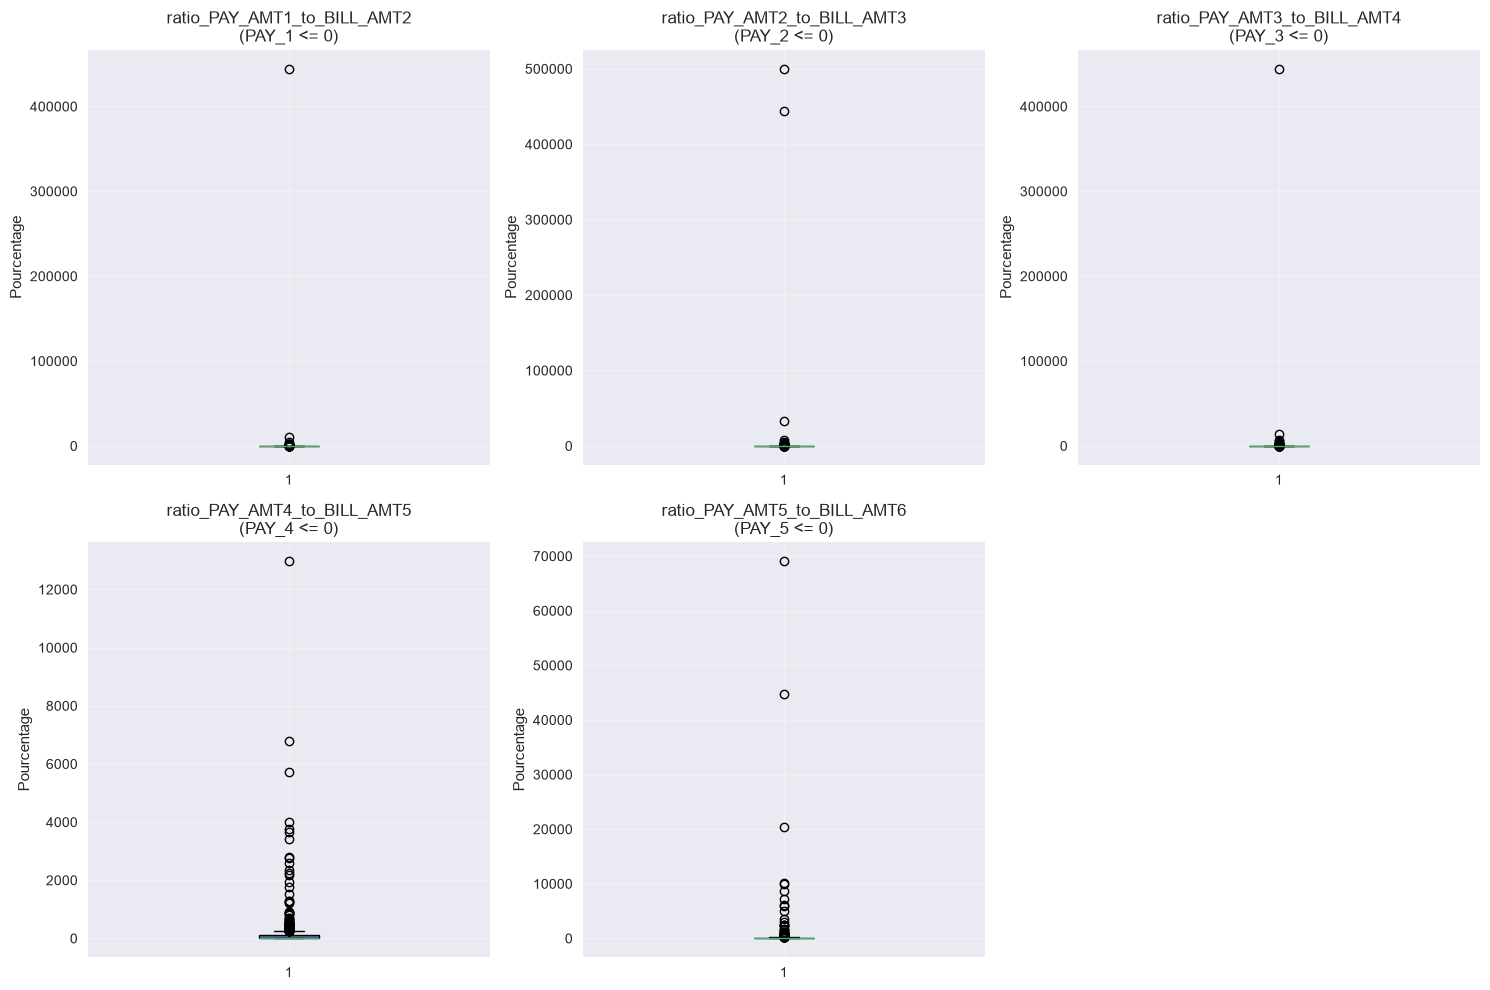

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Supposons que les colonnes ratio_PAY_AMT1_to_BILL_AMT2, etc. existent déjà
# Création de la liste des colonnes ratio existantes
ratio_columns = ['ratio_PAY_AMT1_to_BILL_AMT2', 'ratio_PAY_AMT2_to_BILL_AMT3', 
                 'ratio_PAY_AMT3_to_BILL_AMT4', 'ratio_PAY_AMT4_to_BILL_AMT5', 
                 'ratio_PAY_AMT5_to_BILL_AMT6']

# Analyse statistique pour les valeurs où PAY_n <= 0
print("Analyse des ratios avec PAY_n <= 0 :")

# Création d'une liste pour stocker les résultats
results = []

for col in ratio_columns:
    # Pour chaque colonne ratio, je dois identifier la colonne PAY_n correspondante
    # Exemple : ratio_PAY_AMT1_to_BILL_AMT2 -> PAY_n = PAY_1
    # On extrait le numéro de la colonne PAY
    pay_col_name = col.split('_to_')[0]  # Ex: 'ratio_PAY_AMT1_to_BILL_AMT2' -> 'ratio_PAY_AMT1'
    pay_n_col = f"PAY_{pay_col_name.split('PAY_AMT')[1]}"  # Ex: 'PAY_1'
    
    # Filtrer les données où PAY_n <= 0
    filtered_data = df[df[pay_n_col] <= 0][col]
    
    if len(filtered_data) > 0:
        mean_val = filtered_data.mean()
        min_val = filtered_data.min()
        median_val = filtered_data.median()
        max_val = filtered_data.max()
        count = len(filtered_data)
        
        results.append({
            'Colonne': col,
            'Moyenne (PAY_n <= 0)': round(mean_val, 2) if not pd.isna(mean_val) else None,
            'Minimum (PAY_n <= 0)': round(min_val, 2) if not pd.isna(min_val) else None,
            'Médiane (PAY_n <= 0)': round(median_val, 2) if not pd.isna(median_val) else None,
            'Maximum (PAY_n <= 0)': round(max_val, 2) if not pd.isna(max_val) else None,
            'Nombre d\'observations': count
        })
    else:
        results.append({
            'Colonne': col,
            'Moyenne (PAY_n <= 0)': None,
            'Minimum (PAY_n <= 0)': None,
            'Médiane (PAY_n <= 0)': None,
            'Maximum (PAY_n <= 0)': None,
            'Nombre d\'observations': 0
        })

# Création du tableau de résultats
results_df = pd.DataFrame(results)
print("Statistiques pour les valeurs où PAY_n <= 0 :")
print(results_df.to_string(index=False))

# Boxplot individuel pour chaque colonne
plt.figure(figsize=(15, 10))

for i, col in enumerate(ratio_columns):
    plt.subplot(2, 3, i+1)
    
    # Identifier la colonne PAY_n correspondante
    pay_col_name = col.split('_to_')[0]  # Ex: 'ratio_PAY_AMT1_to_BILL_AMT2' -> 'ratio_PAY_AMT1'
    pay_n_col = f"PAY_{pay_col_name.split('PAY_AMT')[1]}"  # Ex: 'PAY_1'
    
    # Filtrer les données où PAY_n <= 0
    filtered_data = df[df[pay_n_col] <= 0][col].dropna()
    
    if len(filtered_data) > 0:
        plt.boxplot(filtered_data, patch_artist=True)
        plt.title(f'{col}\n(PAY_{pay_n_col.split("_")[1]} <= 0)')
        plt.ylabel('Pourcentage')
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'Pas de données\n(PAY_n > 0)', ha='center', va='center', transform=plt.gca().transAxes)
        plt.title(f'{col}\n(PAY_{pay_n_col.split("_")[1]} <= 0)')

plt.tight_layout()
plt.show()



Ces mesures nous apprennent qu'il n'est pas possible de trouver un seuil de remboursement à partir duquel la banque considère que le client est à jour

Analyse des ratios avec PAY_n > 0 :

Statistiques pour les valeurs où PAY_n > 0 :
                    Colonne  Moyenne (PAY_n > 0)  Minimum (PAY_n > 0)  Médiane (PAY_n > 0)  Maximum (PAY_n > 0)  Nombre d'observations
ratio_PAY_AMT1_to_BILL_AMT2                24.73                  0.0                 4.51             10101.01                   6818
ratio_PAY_AMT2_to_BILL_AMT3                15.26                  0.0                 4.52              1975.00                   4438
ratio_PAY_AMT3_to_BILL_AMT4                14.92                  0.0                 3.92              1527.78                   4213
ratio_PAY_AMT4_to_BILL_AMT5                12.16                  0.0                 3.76               952.38                   3510
ratio_PAY_AMT5_to_BILL_AMT6                 9.71                  0.0                 3.87               722.33                   2968


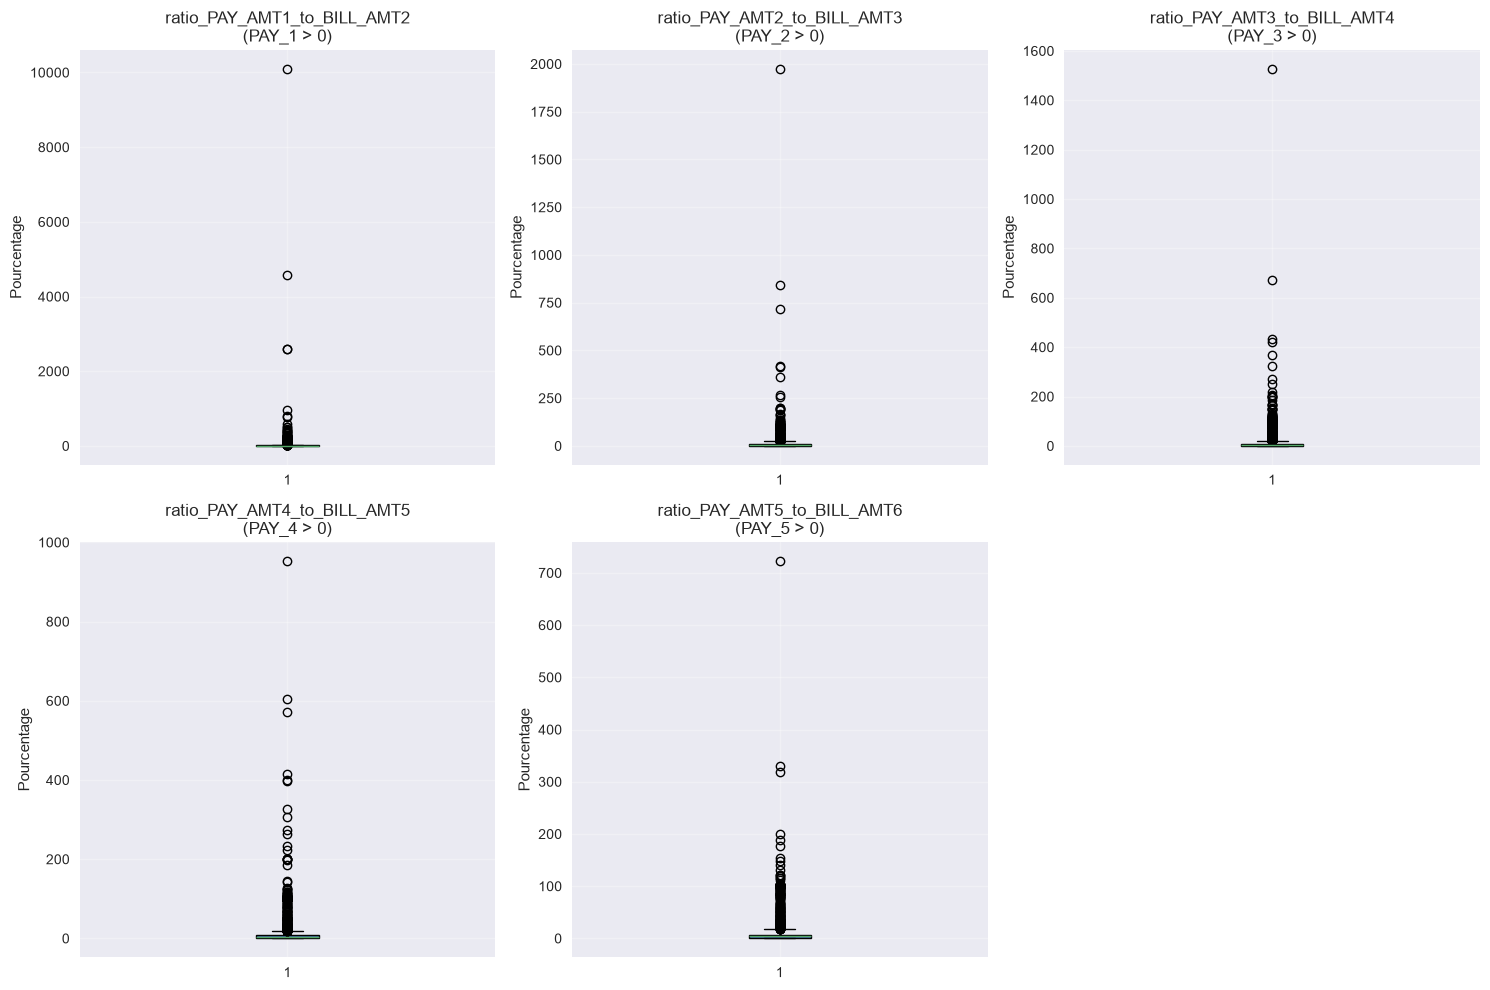

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Définition des colonnes ratio existantes
ratio_columns = ['ratio_PAY_AMT1_to_BILL_AMT2', 'ratio_PAY_AMT2_to_BILL_AMT3', 
                 'ratio_PAY_AMT3_to_BILL_AMT4', 'ratio_PAY_AMT4_to_BILL_AMT5', 
                 'ratio_PAY_AMT5_to_BILL_AMT6']

# Analyse statistique pour les valeurs où PAY_n > 0
print("Analyse des ratios avec PAY_n > 0 :\n")

results = []

for col in ratio_columns:
    # Identification de la colonne PAY_n correspondante (ex: PAY_1, PAY_2...)
    pay_col_name = col.split('_to_')[0] 
    pay_n_col = f"PAY_{pay_col_name.split('PAY_AMT')[1]}" 
    
    # Filtrer les données où PAY_n > 0 (Attention à l'espace dans '> 0')
    filtered_data = df[df[pay_n_col] > 0][col]
    
    if len(filtered_data) > 0:
        mean_val = filtered_data.mean()
        min_val = filtered_data.min()
        median_val = filtered_data.median()
        max_val = filtered_data.max()
        count = len(filtered_data)
        
        results.append({
            'Colonne': col,
            'Moyenne (PAY_n > 0)': round(mean_val, 2) if not pd.isna(mean_val) else None,
            'Minimum (PAY_n > 0)': round(min_val, 2) if not pd.isna(min_val) else None,
            'Médiane (PAY_n > 0)': round(median_val, 2) if not pd.isna(median_val) else None,
            'Maximum (PAY_n > 0)': round(max_val, 2) if not pd.isna(max_val) else None,
            'Nombre d\'observations': count
        })
    else:
        results.append({
            'Colonne': col,
            'Moyenne (PAY_n > 0)': None,
            'Minimum (PAY_n > 0)': None,
            'Médiane (PAY_n > 0)': None,
            'Maximum (PAY_n > 0)': None,
            'Nombre d\'observations': 0
        })

# Création du tableau de résultats
results_df = pd.DataFrame(results)
print("Statistiques pour les valeurs où PAY_n > 0 :")
print(results_df.to_string(index=False))

# Boxplot individuel pour chaque colonne
plt.figure(figsize=(15, 10))

for i, col in enumerate(ratio_columns):
    plt.subplot(2, 3, i+1)
    
    # Identifier la colonne PAY_n correspondante
    pay_col_name = col.split('_to_')[0] 
    pay_n_col = f"PAY_{pay_col_name.split('PAY_AMT')[1]}" 
    
    # Filtrer les données où PAY_n > 0 et retirer les NaN du ratio
    filtered_data = df[df[pay_n_col] > 0][col].dropna()
    
    if len(filtered_data) > 0:
        plt.boxplot(filtered_data, patch_artist=True)
        plt.title(f'{col}\n(PAY_{pay_n_col.split("_")[1]} > 0)')
        plt.ylabel('Pourcentage')
        plt.grid(True, alpha=0.3)
    else:
        # Correction du texte affiché quand il n'y a pas de données
        plt.text(0.5, 0.5, 'Pas de données\n(PAY_n <= 0)', ha='center', va='center', transform=plt.gca().transAxes)
        plt.title(f'{col}\n(PAY_{pay_n_col.split("_")[1]} > 0)')

plt.tight_layout()
plt.show()

Le ratio de remboursement baisse drastiquement pour les dossiers toppés avec incidents

--- Analyse Focus Zone 0-20% ---
Distribution par Bucket (0-20%) :

Condition  PAY <= 0  PAY > 0
Bucket                      
[0, 1)         5625     6765
[1, 2)          568      150
[2, 3)         2913      343
[3, 4)        19840     2605
[4, 5)        13843     2389
[5, 6)         6650     1015
[6, 7)         3756      645
[7, 8)         3351      870
[8, 9)         2533      732
[9, 10)        1873      421
[10, 11)       1703      306
[11, 12)       1354      277
[12, 13)       1129      215
[13, 14)        942      177
[14, 15)        870      161


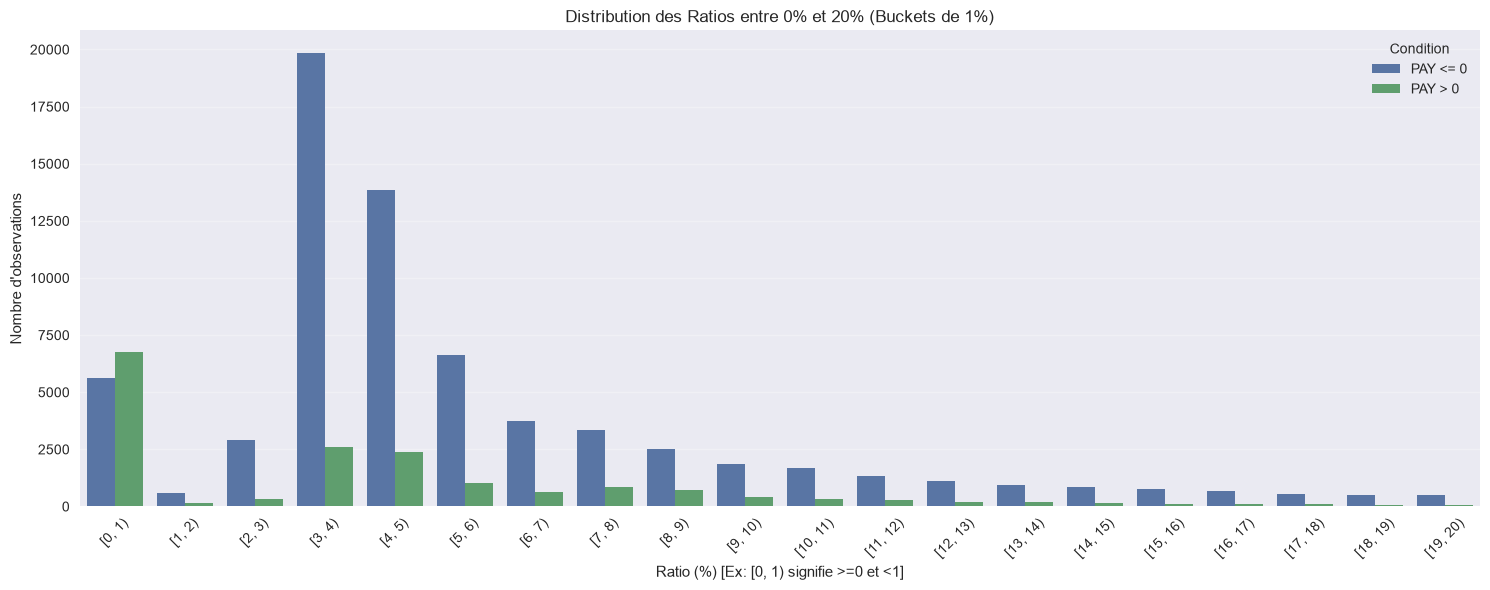


Pourcentage global PAY > 0 avec Ratio >= 20% : 13.11%
Pourcentage global PAY <= 0 avec Ratio >= 20% : 36.64%
Pas de données dans le groupe PAY <= 0 pour afficher le graphique.
Pas de données dans le groupe PAY > 0 pour afficher le graphique.


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tes colonnes définies
ratio_columns = [
    'ratio_PAY_AMT1_to_BILL_AMT2', 
    'ratio_PAY_AMT2_to_BILL_AMT3', 
    'ratio_PAY_AMT3_to_BILL_AMT4', 
    'ratio_PAY_AMT4_to_BILL_AMT5', 
    'ratio_PAY_AMT5_to_BILL_AMT6'
]

# On prépare une liste plate pour stocker toutes les lignes de données
data_all = []
print("--- Analyse Focus Zone 0-20% ---")

for col_ratio in ratio_columns:
    # 1. Identifier la colonne PAY associée
    pay_part = col_ratio.split('_to_')[0] 
    base_pay = pay_part.replace('ratio_', '') 
    n = base_pay.replace('PAY_AMT', '') 
    
    # On construit le nom de la colonne PAY correspondante (ex: 'PAY1')
    col_pay = f"PAY_{n}" 
    
    # Vérification de sécurité avec fallback
    if col_pay not in df.columns:
        col_pay_fallback = f"PAY_AMT{n}"
        if col_pay_fallback in df.columns:
            col_pay = col_pay_fallback
        else:
            print(f"Avertissement: Colonne {col_pay} et {col_pay_fallback} non trouvées pour {col_ratio}")
            continue

    # 2. Extraction des données
    bill_col_target = f'BILL_AMT{int(n)+1}'
    
    # On considère le ratio valide si Bill > 0
    mask_valid = df[col_ratio].notna() & (df[bill_col_target] > 0)
    valid_ratios = df.loc[mask_valid, col_ratio].dropna()
    
    if len(valid_ratios) == 0:
        continue

    # 3. Filtre de la zone d'intérêt (0% à 20%)
    mask_zone = (valid_ratios >= 0) & (valid_ratios < 20)
    ratios_in_zone = valid_ratios[mask_zone]
    
    if len(ratios_in_zone) == 0:
        continue
        
    # 4. Condition sur le paiement PAY_n
    pay_values = df.loc[valid_ratios.index, col_pay]
    
    for is_positive in [True, False]:
        if is_positive:
            cond_name = "PAY > 0"
            cond_mask = pay_values > 0
        else:
            cond_name = "PAY <= 0"
            cond_mask = pay_values <= 0
            
        data_cond = ratios_in_zone[cond_mask]
        
        if len(data_cond) > 0:
            # Création des buckets de 1%
            bins_edges = np.arange(0, 21, 1) 
            buckets = pd.cut(data_cond, bins=bins_edges, right=False, include_lowest=True)
            
            df_temp = pd.DataFrame({
                'Ratio_Value': data_cond.values,
                'Bucket': buckets.astype(str),
                'Condition': cond_name
            })
            data_all.append(df_temp)

# --- Traitement Global et Premier Graphique (Non modifié) ---
if not data_all:
    print("Aucune donnée trouvée dans la zone 0-20%.")
else:
    df_all_buckets = pd.concat(data_all, ignore_index=True)
    
    # Définition de l'ordre explicite des catégories
    levels = [f"[{i}, {i+1})" for i in range(0, 20)]
    df_all_buckets['Bucket'] = pd.Categorical(df_all_buckets['Bucket'], categories=levels, ordered=True)

    # Tableau récapitulatif
    df_counts = df_all_buckets.groupby(['Bucket', 'Condition']).size().unstack(fill_value=0)
    print("Distribution par Bucket (0-20%) :\n")
    print(df_counts.head(15)) 

    # --- GRAPHIQUE 1 : Barplot global 0-20% (PAY > 0 ET PAY <= 0 confondus) ---
    plt.figure(figsize=(15, 6))
    counts = df_all_buckets.value_counts(['Bucket', 'Condition'])
    
    sns.barplot(
        x=counts.index.get_level_values('Bucket'), 
        y=counts.values, 
        hue=counts.index.get_level_values('Condition')
    )
    
    plt.title('Distribution des Ratios entre 0% et 20% (Buckets de 1%)')
    plt.xlabel('Ratio (%) [Ex: [0, 1) signifie >=0 et <1]')
    plt.ylabel('Nombre d\'observations')
    plt.xticks(ticks=range(len(levels)), labels=levels, rotation=45) 
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- GRAPHIQUES 2 & 3 : Séparés par Condition avec Statistiques > 20% ---
    
    # On calcule le nombre total d'observations valides dans df_all_buckets pour les pourcentages
    # Note: df_all_buckets ne contient QUE les ratios entre 0 et 20%.
    # Pour avoir le % au dessus de 20%, on doit regarder l'ensemble des données valides initiales.
    
    total_valid_ratios_list = []
    for col_ratio in ratio_columns:
        pay_part = col_ratio.split('_to_')[0] 
        base_pay = pay_part.replace('ratio_', '') 
        n_str = base_pay.replace('PAY_AMT', '') 
        
        # Tentative nom colonne PAY
        col_pay_name = f"PAY_{n_str}"
        if col_pay_name not in df.columns:
            col_pay_name = f"PAY_AMT_{n_str}"
            
        if col_pay_name in df.columns:
            bill_col_target = f'BILL_AMT{int(n_str)+1}'
            mask_valid_total = df[col_ratio].notna() & (df[bill_col_target] > 0)
            valid_ratios_all = df.loc[mask_valid_total, col_ratio].dropna()
            
            if len(valid_ratios_all) > 0:
                # On stocke aussi la condition PAY pour pouvoir calculer le % global par groupe
                pay_vals = df.loc[valid_ratios_all.index, col_pay_name]
                
                for is_positive in [True, False]:
                    if is_positive:
                        sub_mask = pay_vals > 0
                    else:
                        sub_mask = pay_vals <= 0
                    
                    # On garde les ratios > 20 pour ce groupe spécifique
                    high_ratios = valid_ratios_all[sub_mask][(valid_ratios_all[sub_mask] >= 20)]
                    
                    # On stocke le nombre de "hautes" valeurs et le total du groupe dans des dicts temporaires
                    key = "PAY > 0" if is_positive else "PAY <= 0"
                    total_valid_ratios_list.append({
                        'group': key,
                        'count_high': len(high_ratios),
                        'count_in_zone': len(valid_ratios_all[sub_mask][(valid_ratios_all[sub_mask] < 20)]) # Utile si on veut % local, mais ici on veut % global
                    })

    # Calculs des pourcentages globaux par groupe
    total_counts_by_group = {'PAY > 0': 0, 'PAY <= 0': 0}
    high_counts_by_group = {'PAY > 0': 0, 'PAY <= 0': 0}
    
    for item in total_valid_ratios_list:
        g = item['group']
        # On recalule le total global de ce groupe (tous ratios confondus)
        # Plus simple : on refait le compte direct sur df
    
    # Calcul propre du % > 20% par groupe
    pct_high_pay_pos = 0
    pct_high_pay_neg = 0
    
    for col_ratio in ratio_columns:
        pay_part = col_ratio.split('_to_')[0] 
        base_pay = pay_part.replace('ratio_', '') 
        n_str = base_pay.replace('PAY_AMT', '') 
        col_pay_name = f"PAY_{n_str}"
        if col_pay_name not in df.columns:
            col_pay_name = f"PAY_AMT_{n_str}"
            
        if col_pay_name in df.columns:
            bill_col_target = f'BILL_AMT{int(n_str)+1}'
            mask_valid_total = df[col_ratio].notna() & (df[bill_col_target] > 0)
            valid_ratios_all = df.loc[mask_valid_total, col_ratio]
            
            pay_vals = df.loc[valid_ratios_all.index, col_pay_name]
            
            # Groupe PAY > 0
            mask_pos = pay_vals > 0
            total_pos = mask_pos.sum()
            high_pos = valid_ratios_all[mask_pos][(valid_ratios_all[mask_pos] >= 20)].notna().sum() # .notna() car si on prend un sous-ensemble
            if total_pos > 0:
                pct_high_pay_pos += (high_pos / total_pos) * (1/len(ratio_columns)) # Moyenne pondérée simple ou somme directe ? 
                # Mieux : On accumule les comptes bruts
            
    # Réinitialisation pour cumul brut
    cum_high_pos = 0
    cum_total_pos = 0
    cum_high_neg = 0
    cum_total_neg = 0

    for col_ratio in ratio_columns:
        pay_part = col_ratio.split('_to_')[0] 
        base_pay = pay_part.replace('ratio_', '') 
        n_str = base_pay.replace('PAY_AMT', '') 
        col_pay_name = f"PAY_{n_str}"
        if col_pay_name not in df.columns:
            col_pay_name = f"PAY_AMT_{n_str}"
            
        if col_pay_name in df.columns:
            bill_col_target = f'BILL_AMT{int(n_str)+1}'
            mask_valid_total = df[col_ratio].notna() & (df[bill_col_target] > 0)
            valid_ratios_all = df.loc[mask_valid_total, col_ratio]
            pay_vals = df.loc[valid_ratios_all.index, col_pay_name]
            
            # Groupe PAY > 0
            mask_pos = pay_vals > 0
            cum_total_pos += mask_pos.sum()
            # On compte ceux qui sont >= 20
            vals_pos = valid_ratios_all[mask_pos]
            cum_high_pos += vals_pos[(vals_pos >= 20)].notna().sum()

            # Groupe PAY <= 0
            mask_neg = pay_vals <= 0
            cum_total_neg += mask_neg.sum()
            vals_neg = valid_ratios_all[mask_neg]
            cum_high_neg += vals_neg[(vals_neg >= 20)].notna().sum()

    # Pourcentages finaux
    final_pct_high_pos = (cum_high_pos / cum_total_pos * 100) if cum_total_pos > 0 else 0
    final_pct_high_neg = (cum_high_neg / cum_total_neg * 100) if cum_total_neg > 0 else 0

    print(f"\nPourcentage global PAY > 0 avec Ratio >= 20% : {final_pct_high_pos:.2f}%")
    print(f"Pourcentage global PAY <= 0 avec Ratio >= 20% : {final_pct_high_neg:.2f}%")

    # --- GRAPHIQUE 2 : Zoom pour PAY <= 0 ---
    if 'data_neg_only' in locals() and len(data_neg_only) > 0:
        df_neg = pd.concat(data_neg_only, ignore_index=True)
        levels = [f"[{i}, {i+1})" for i in range(0, 20)]
        df_neg['Bucket'] = pd.Categorical(df_neg['Bucket'], categories=levels, ordered=True)

        plt.figure(figsize=(12, 6))
        
        # Histogramme des buckets 0-20%
        counts_neg = df_neg.value_counts(['Bucket', 'Condition'])
        sns.barplot(
            x=counts_neg.index.get_level_values('Bucket'), 
            y=counts_neg.values, 
            color='#d62728' # Rouge
        )
        
        # Courbe KDE sur les données brutes du groupe
        if len(df_neg) > 0:
            sns.kdeplot(data=df_neg[df_neg['Ratio_Value'] < 20], x='Ratio_Value', color='red')

        plt.title(f'Distribution des Ratios 0-20% (Groupe PAY <= 0)\n> {final_pct_high_neg:.1f}% de la population a un ratio >= 20%')
        plt.xlabel('Ratio (%) [Bucket de 1%)')
        plt.ylabel('Nombre d\'observations / Densité')
        plt.xticks(ticks=range(len(levels)), labels=levels, rotation=45)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Pas de données dans le groupe PAY <= 0 pour afficher le graphique.")

    # --- GRAPHIQUE 3 : Zoom pour PAY > 0 ---
    if 'data_pos_only' in locals() and len(data_pos_only) > 0:
        df_pos = pd.concat(data_pos_only, ignore_index=True)
        levels = [f"[{i}, {i+1})" for i in range(0, 20)]
        df_pos['Bucket'] = pd.Categorical(df_pos['Bucket'], categories=levels, ordered=True)

        plt.figure(figsize=(12, 6))
        
        # Histogramme des buckets 0-20%
        counts_pos = df_pos.value_counts(['Bucket', 'Condition'])
        sns.barplot(
            x=counts_pos.index.get_level_values('Bucket'), 
            y=counts_pos.values, 
            color='#1f77b4' # Bleu
        )
        
        # Courbe KDE sur les données brutes du groupe
        if len(df_pos) > 0:
            sns.kdeplot(data=df_pos[df_pos['Ratio_Value'] < 20], x='Ratio_Value', color='blue')

        plt.title(f'Distribution des Ratios 0-20% (Groupe PAY > 0)\n> {final_pct_high_pos:.1f}% de la population a un ratio >= 20%')
        plt.xlabel('Ratio (%) [Bucket de 1%)')
        plt.ylabel('Nombre d\'observations / Densité')
        plt.xticks(ticks=range(len(levels)), labels=levels, rotation=45)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Pas de données dans le groupe PAY > 0 pour afficher le graphique.")

J'exclue ratio_PAY_AMT1_to_BILL_AMT2 car la codification 1 pollue cette colonne

--- Analyse Focus Zone 0-20% ---
Distribution par Bucket (0-20%) :

Condition  PAY <= 0  PAY > 0
Bucket                      
[0, 1)         5221     4739
[1, 2)          560      105
[2, 3)         2723      267
[3, 4)        17222     2300
[4, 5)        10541     1699
[5, 6)         5073      686
[6, 7)         2869      453
[7, 8)         2628      691
[8, 9)         1932      576
[9, 10)        1389      301
[10, 11)       1313      236
[11, 12)       1021      200
[12, 13)        853      148
[13, 14)        720      133
[14, 15)        650      116


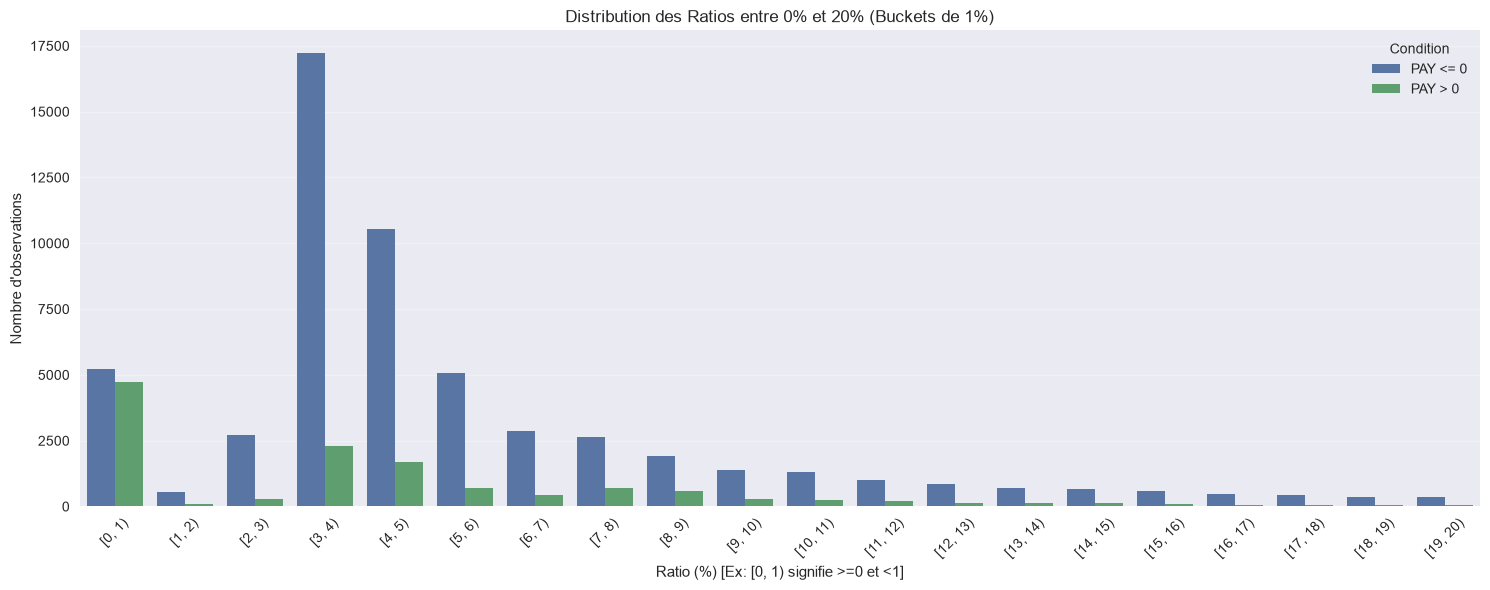


Pourcentage global PAY > 0 avec Ratio >= 20% : 11.15%
Pourcentage global PAY <= 0 avec Ratio >= 20% : 36.14%


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tes colonnes définies
ratio_columns = [
    'ratio_PAY_AMT2_to_BILL_AMT3', 
    'ratio_PAY_AMT3_to_BILL_AMT4', 
    'ratio_PAY_AMT4_to_BILL_AMT5', 
    'ratio_PAY_AMT5_to_BILL_AMT6'
]

# On prépare une liste plate pour stocker toutes les lignes de données
data_all = []
print("--- Analyse Focus Zone 0-20% ---")

for col_ratio in ratio_columns:
    # 1. Identifier la colonne PAY associée
    pay_part = col_ratio.split('_to_')[0] 
    base_pay = pay_part.replace('ratio_', '') 
    n = base_pay.replace('PAY_AMT', '') 
    
    # On construit le nom de la colonne PAY correspondante (ex: 'PAY1')
    col_pay = f"PAY_{n}" 
    
    # Vérification de sécurité avec fallback
    if col_pay not in df.columns:
        col_pay_fallback = f"PAY_AMT{n}"
        if col_pay_fallback in df.columns:
            col_pay = col_pay_fallback
        else:
            print(f"Avertissement: Colonne {col_pay} et {col_pay_fallback} non trouvées pour {col_ratio}")
            continue

    # 2. Extraction des données
    bill_col_target = f'BILL_AMT{int(n)+1}'
    
    # On considère le ratio valide si Bill > 0
    mask_valid = df[col_ratio].notna() & (df[bill_col_target] > 0)
    valid_ratios = df.loc[mask_valid, col_ratio].dropna()
    
    if len(valid_ratios) == 0:
        continue

    # 3. Filtre de la zone d'intérêt (0% à 20%)
    mask_zone = (valid_ratios >= 0) & (valid_ratios < 20)
    ratios_in_zone = valid_ratios[mask_zone]
    
    if len(ratios_in_zone) == 0:
        continue
        
    # 4. Condition sur le paiement PAY_n
    pay_values = df.loc[valid_ratios.index, col_pay]
    
    for is_positive in [True, False]:
        if is_positive:
            cond_name = "PAY > 0"
            cond_mask = pay_values > 0
        else:
            cond_name = "PAY <= 0"
            cond_mask = pay_values <= 0
            
        data_cond = ratios_in_zone[cond_mask]
        
        if len(data_cond) > 0:
            # Création des buckets de 1%
            bins_edges = np.arange(0, 21, 1) 
            buckets = pd.cut(data_cond, bins=bins_edges, right=False, include_lowest=True)
            
            df_temp = pd.DataFrame({
                'Ratio_Value': data_cond.values,
                'Bucket': buckets.astype(str),
                'Condition': cond_name
            })
            data_all.append(df_temp)

# --- Traitement Global et Premier Graphique (Non modifié) ---
if not data_all:
    print("Aucune donnée trouvée dans la zone 0-20%.")
else:
    df_all_buckets = pd.concat(data_all, ignore_index=True)
    
    # Définition de l'ordre explicite des catégories
    levels = [f"[{i}, {i+1})" for i in range(0, 20)]
    df_all_buckets['Bucket'] = pd.Categorical(df_all_buckets['Bucket'], categories=levels, ordered=True)

    # Tableau récapitulatif
    df_counts = df_all_buckets.groupby(['Bucket', 'Condition']).size().unstack(fill_value=0)
    print("Distribution par Bucket (0-20%) :\n")
    print(df_counts.head(15)) 

    # --- GRAPHIQUE 1 : Barplot global 0-20% (PAY > 0 ET PAY <= 0 confondus) ---
    plt.figure(figsize=(15, 6))
    counts = df_all_buckets.value_counts(['Bucket', 'Condition'])
    
    sns.barplot(
        x=counts.index.get_level_values('Bucket'), 
        y=counts.values, 
        hue=counts.index.get_level_values('Condition')
    )
    
    plt.title('Distribution des Ratios entre 0% et 20% (Buckets de 1%)')
    plt.xlabel('Ratio (%) [Ex: [0, 1) signifie >=0 et <1]')
    plt.ylabel('Nombre d\'observations')
    plt.xticks(ticks=range(len(levels)), labels=levels, rotation=45) 
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- GRAPHIQUES 2 & 3 : Séparés par Condition avec Statistiques > 20% ---
    
    # On calcule le nombre total d'observations valides dans df_all_buckets pour les pourcentages
    # Note: df_all_buckets ne contient QUE les ratios entre 0 et 20%.
    # Pour avoir le % au dessus de 20%, on doit regarder l'ensemble des données valides initiales.
    
    total_valid_ratios_list = []
    for col_ratio in ratio_columns:
        pay_part = col_ratio.split('_to_')[0] 
        base_pay = pay_part.replace('ratio_', '') 
        n_str = base_pay.replace('PAY_AMT', '') 
        
        # Tentative nom colonne PAY
        col_pay_name = f"PAY_{n_str}"
        if col_pay_name not in df.columns:
            col_pay_name = f"PAY_AMT_{n_str}"
            
        if col_pay_name in df.columns:
            bill_col_target = f'BILL_AMT{int(n_str)+1}'
            mask_valid_total = df[col_ratio].notna() & (df[bill_col_target] > 0)
            valid_ratios_all = df.loc[mask_valid_total, col_ratio].dropna()
            
            if len(valid_ratios_all) > 0:
                # On stocke aussi la condition PAY pour pouvoir calculer le % global par groupe
                pay_vals = df.loc[valid_ratios_all.index, col_pay_name]
                
                for is_positive in [True, False]:
                    if is_positive:
                        sub_mask = pay_vals > 0
                    else:
                        sub_mask = pay_vals <= 0
                    
                    # On garde les ratios > 20 pour ce groupe spécifique
                    high_ratios = valid_ratios_all[sub_mask][(valid_ratios_all[sub_mask] >= 20)]
                    
                    # On stocke le nombre de "hautes" valeurs et le total du groupe dans des dicts temporaires
                    key = "PAY > 0" if is_positive else "PAY <= 0"
                    total_valid_ratios_list.append({
                        'group': key,
                        'count_high': len(high_ratios),
                        'count_in_zone': len(valid_ratios_all[sub_mask][(valid_ratios_all[sub_mask] < 20)]) # Utile si on veut % local, mais ici on veut % global
                    })

    # Calculs des pourcentages globaux par groupe
    total_counts_by_group = {'PAY > 0': 0, 'PAY <= 0': 0}
    high_counts_by_group = {'PAY > 0': 0, 'PAY <= 0': 0}
    
    for item in total_valid_ratios_list:
        g = item['group']
        # On recalule le total global de ce groupe (tous ratios confondus)
        # Plus simple : on refait le compte direct sur df
    
    # Calcul propre du % > 20% par groupe
    pct_high_pay_pos = 0
    pct_high_pay_neg = 0
    
    for col_ratio in ratio_columns:
        pay_part = col_ratio.split('_to_')[0] 
        base_pay = pay_part.replace('ratio_', '') 
        n_str = base_pay.replace('PAY_AMT', '') 
        col_pay_name = f"PAY_{n_str}"
        if col_pay_name not in df.columns:
            col_pay_name = f"PAY_AMT_{n_str}"
            
        if col_pay_name in df.columns:
            bill_col_target = f'BILL_AMT{int(n_str)+1}'
            mask_valid_total = df[col_ratio].notna() & (df[bill_col_target] > 0)
            valid_ratios_all = df.loc[mask_valid_total, col_ratio]
            
            pay_vals = df.loc[valid_ratios_all.index, col_pay_name]
            
            # Groupe PAY > 0
            mask_pos = pay_vals > 0
            total_pos = mask_pos.sum()
            high_pos = valid_ratios_all[mask_pos][(valid_ratios_all[mask_pos] >= 20)].notna().sum() # .notna() car si on prend un sous-ensemble
            if total_pos > 0:
                pct_high_pay_pos += (high_pos / total_pos) * (1/len(ratio_columns)) # Moyenne pondérée simple ou somme directe ? 
                # Mieux : On accumule les comptes bruts
            
    # Réinitialisation pour cumul brut
    cum_high_pos = 0
    cum_total_pos = 0
    cum_high_neg = 0
    cum_total_neg = 0

    for col_ratio in ratio_columns:
        pay_part = col_ratio.split('_to_')[0] 
        base_pay = pay_part.replace('ratio_', '') 
        n_str = base_pay.replace('PAY_AMT', '') 
        col_pay_name = f"PAY_{n_str}"
        if col_pay_name not in df.columns:
            col_pay_name = f"PAY_AMT_{n_str}"
            
        if col_pay_name in df.columns:
            bill_col_target = f'BILL_AMT{int(n_str)+1}'
            mask_valid_total = df[col_ratio].notna() & (df[bill_col_target] > 0)
            valid_ratios_all = df.loc[mask_valid_total, col_ratio]
            pay_vals = df.loc[valid_ratios_all.index, col_pay_name]
            
            # Groupe PAY > 0
            mask_pos = pay_vals > 0
            cum_total_pos += mask_pos.sum()
            # On compte ceux qui sont >= 20
            vals_pos = valid_ratios_all[mask_pos]
            cum_high_pos += vals_pos[(vals_pos >= 20)].notna().sum()

            # Groupe PAY <= 0
            mask_neg = pay_vals <= 0
            cum_total_neg += mask_neg.sum()
            vals_neg = valid_ratios_all[mask_neg]
            cum_high_neg += vals_neg[(vals_neg >= 20)].notna().sum()

    # Pourcentages finaux
    final_pct_high_pos = (cum_high_pos / cum_total_pos * 100) if cum_total_pos > 0 else 0
    final_pct_high_neg = (cum_high_neg / cum_total_neg * 100) if cum_total_neg > 0 else 0

    print(f"\nPourcentage global PAY > 0 avec Ratio >= 20% : {final_pct_high_pos:.2f}%")
    print(f"Pourcentage global PAY <= 0 avec Ratio >= 20% : {final_pct_high_neg:.2f}%")

    # --- GRAPHIQUE 2 : Zoom pour PAY <= 0 ---
    if 'data_neg_only' in locals() and len(data_neg_only) > 0:
        df_neg = pd.concat(data_neg_only, ignore_index=True)
        levels = [f"[{i}, {i+1})" for i in range(0, 20)]
        df_neg['Bucket'] = pd.Categorical(df_neg['Bucket'], categories=levels, ordered=True)

        plt.figure(figsize=(12, 6))
        
        # Histogramme des buckets 0-20%
        counts_neg = df_neg.value_counts(['Bucket', 'Condition'])
        sns.barplot(
            x=counts_neg.index.get_level_values('Bucket'), 
            y=counts_neg.values, 
            color='#d62728' # Rouge
        )
        
    # --- GRAPHIQUE 3 : Zoom pour PAY > 0 ---
    if 'data_pos_only' in locals() and len(data_pos_only) > 0:
        df_pos = pd.concat(data_pos_only, ignore_index=True)
        levels = [f"[{i}, {i+1})" for i in range(0, 20)]
        df_pos['Bucket'] = pd.Categorical(df_pos['Bucket'], categories=levels, ordered=True)

        plt.figure(figsize=(12, 6))
        
        # Histogramme des buckets 0-20%
        counts_pos = df_pos.value_counts(['Bucket', 'Condition'])
        sns.barplot(
            x=counts_pos.index.get_level_values('Bucket'), 
            y=counts_pos.values, 
            color='#1f77b4' # Bleu
        )


C'est intéressant mais on regarde également le ratio payé par des gens qui sont suceptibles d'agraver ou de diminuer leur retard.  
Tentons de regarder le ratio selon que les gens n'agravent pas leur retard ou l'agravent

--- Analyse Focus Zone 0-20% (Comparaison PAY_n vs PAY_{n+1}) ---

% Global Groupe 'Stagnant/Baisse' >= 20% : 33.37%
% Global Groupe 'Hausse' >= 20%           : 20.70%


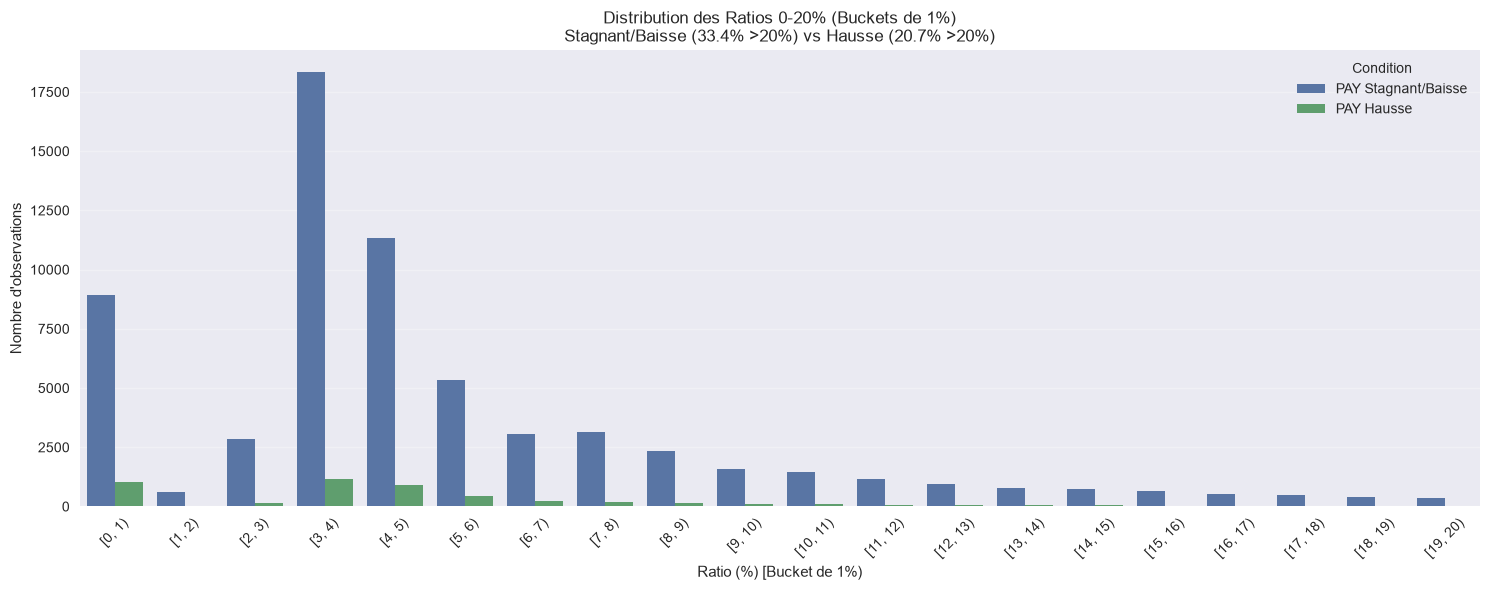

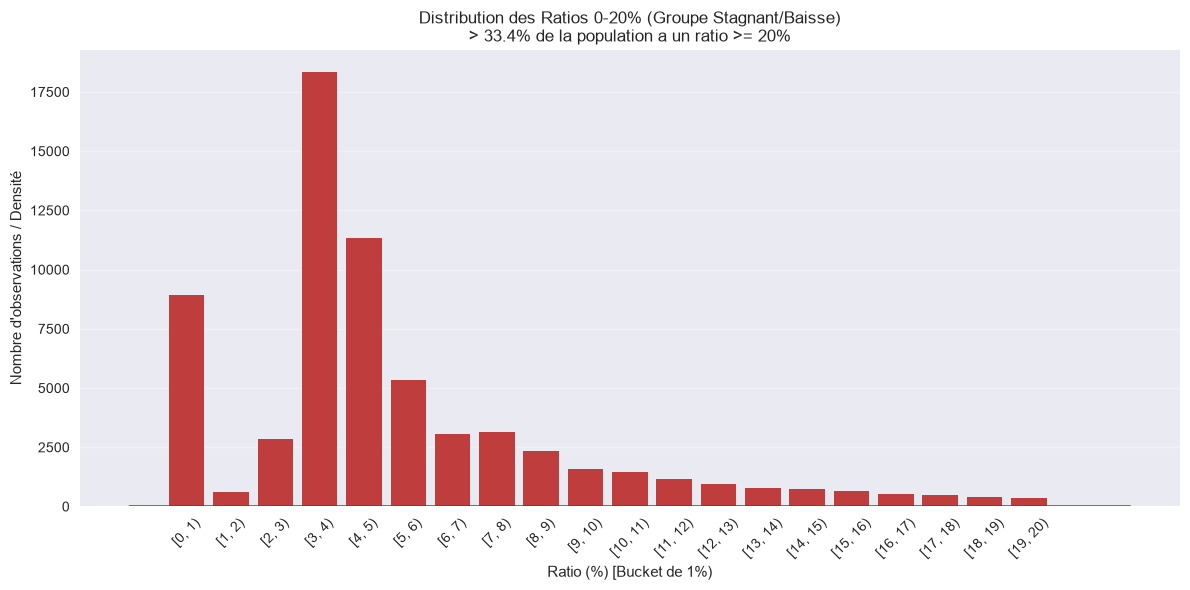

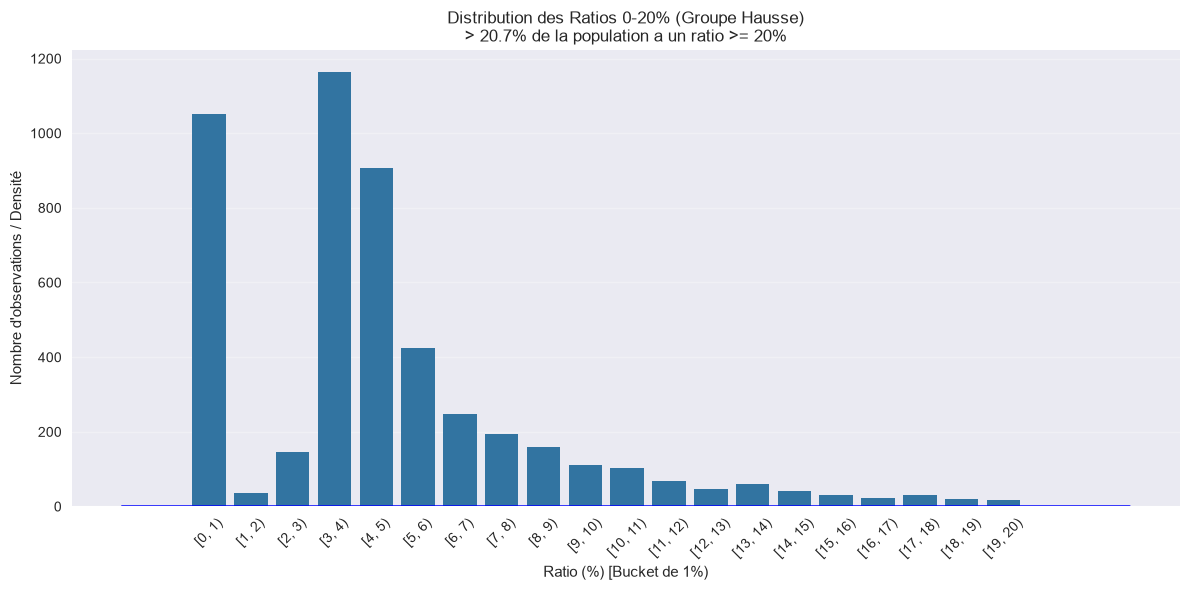

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tes colonnes définies
ratio_columns = [
    'ratio_PAY_AMT2_to_BILL_AMT3', 
    'ratio_PAY_AMT3_to_BILL_AMT4', 
    'ratio_PAY_AMT4_to_BILL_AMT5', 
    'ratio_PAY_AMT5_to_BILL_AMT6'
]

data_all = []
print("--- Analyse Focus Zone 0-20% (Comparaison PAY_n vs PAY_{n+1}) ---")

# Pour calculer le % global > 20% par groupe à la fin
stats_globales = {
    'PAY Stagnant/Baisse': {'total': 0, 'high': 0},
    'PAY Hausse': {'total': 0, 'high': 0}
}

for col_ratio in ratio_columns:
    # 1. Identifier la colonne PAY associée (PAY_n)
    pay_part = col_ratio.split('_to_')[0] 
    base_pay = pay_part.replace('ratio_', '') 
    n_str = base_pay.replace('PAY_AMT', '') 
    
    col_pay_n = f"PAY_{n_str}"
    if col_pay_n not in df.columns:
        col_pay_n = f"PAY_AMT{n_str}" # Fallback
    
    if col_pay_n not in df.columns:
        continue

    # 2. Identifier la colonne PAY_{n+1}
    n_next = int(n_str) + 1
    col_pay_next = f"PAY_{n_next}"
    
    if col_pay_next not in df.columns:
        col_pay_next_fallback = f"PAY_AMT{n_next}"
        if col_pay_next_fallback in df.columns:
            col_pay_next = col_pay_next_fallback
        else:
            continue # Si la colonne suivante n'existe pas, on passe cette boucle

    # 3. Extraction : On ne garde que les ratios qui existent (non-NaN)
    mask_valid = df[col_ratio].notna()
    df_subset = df[mask_valid]
    
    if len(df_subset) == 0:
        continue

    ratios = df_subset[col_ratio]
    pay_n_vals = df_subset[col_pay_n]
    pay_next_vals = df_subset[col_pay_next]

    # --- Logique de groupement dynamique ---
    # On ne compare que si PAY_{n+1} existe aussi (sinon pas de comparaison possible)
    valid_dynamic_mask = pay_next_vals.notna()
    
    pay_n_comp = pay_n_vals[valid_dynamic_mask]
    pay_next_comp = pay_next_vals[valid_dynamic_mask]
    ratios_comp = ratios[valid_dynamic_mask]

    # Groupe A : STAGNANT / BAISSE (PAY_n <= 0 OU PAY_n <= PAY_{n+1})
    mask_stagnant = (pay_n_comp <= 0) | (pay_n_comp <= pay_next_comp)
    
    # Groupe B : HAUSSE (PAY_n > 0 ET PAY_n > PAY_{n+1})
    mask_hausse = (pay_n_comp > 0) & (pay_n_comp > pay_next_comp)

    # --- Stats Globales pour le % > 20% (sur tout le groupe, pas juste < 20%) ---
    stats_globales['PAY Stagnant/Baisse']['total'] += mask_stagnant.sum()
    stats_globales['PAY Stagnant/Baisse']['high'] += ratios_comp[mask_stagnant][ratios_comp[mask_stagnant] >= 20].notna().sum()
    
    stats_globales['PAY Hausse']['total'] += mask_hausse.sum()
    stats_globales['PAY Hausse']['high'] += ratios_comp[mask_hausse][ratios_comp[mask_hausse] >= 20].notna().sum()

    # --- Filtrage Zone [0, 20%) pour les graphiques ---
    
    def process_group(ratios_grp, cond_name):
        if len(ratios_grp) == 0:
            return None
        
        # Filtre zone 0-20
        mask_zone = (ratios_grp >= 0) & (ratios_grp < 20)
        vals_in_zone = ratios_grp[mask_zone]
        
        if len(vals_in_zone) == 0:
            return None
        
        bins_edges = np.arange(0, 21, 1) 
        buckets = pd.cut(vals_in_zone, bins=bins_edges, right=False, include_lowest=True)
        
        # On retourne un dataframe propre pour que seaborn soit content
        df_res = pd.DataFrame({
            'Bucket': buckets.astype(str),
            'Condition': cond_name,
            'Ratio_Value': vals_in_zone.values
        })
        return df_res

    df_stag = process_group(ratios_comp[mask_stagnant], "PAY Stagnant/Baisse")
    if df_stag is not None:
        data_all.append(df_stag)

    df_haut = process_group(ratios_comp[mask_hausse], "PAY Hausse")
    if df_haut is not None:
        data_all.append(df_haut)

# --- Calculs finaux des % > 20% ---
pct_stag_gt_20 = (stats_globales['PAY Stagnant/Baisse']['high'] / stats_globales['PAY Stagnant/Baisse']['total'] * 100) if stats_globales['PAY Stagnant/Baisse']['total'] > 0 else 0
pct_haut_gt_20 = (stats_globales['PAY Hausse']['high'] / stats_globales['PAY Hausse']['total'] * 100) if stats_globales['PAY Hausse']['total'] > 0 else 0

print(f"\n% Global Groupe 'Stagnant/Baisse' >= 20% : {pct_stag_gt_20:.2f}%")
print(f"% Global Groupe 'Hausse' >= 20%           : {pct_haut_gt_20:.2f}%")

# --- Graphiques ---

if not data_all:
    print("Aucune donnée dans la zone 0-20%.")
else:
    df_all_buckets = pd.concat(data_all, ignore_index=True)
    levels = [f"[{i}, {i+1})" for i in range(0, 20)]
    df_all_buckets['Bucket'] = pd.Categorical(df_all_buckets['Bucket'], categories=levels, ordered=True)

    # GRAPHIQUE 1 : Global (Les deux groupes comparés)
    plt.figure(figsize=(15, 6))
    
    # On utilise value_counts pour avoir un comptage propre par bucket et condition
    counts = df_all_buckets.value_counts(['Bucket', 'Condition'])
    
    sns.barplot(
        x=counts.index.get_level_values('Bucket'), 
        y=counts.values, 
        hue=counts.index.get_level_values('Condition') # Ici c'est OK car on passe le dataframe complet via index
    )
    plt.title(f'Distribution des Ratios 0-20% (Buckets de 1%)\nStagnant/Baisse ({pct_stag_gt_20:.1f}% >20%) vs Hausse ({pct_haut_gt_20:.1f}% >20%)')
    plt.xlabel('Ratio (%) [Bucket de 1%)')
    plt.ylabel('Nombre d\'observations')
    plt.xticks(ticks=range(len(levels)), labels=levels, rotation=45) 
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # GRAPHIQUE 2 : Zoom Stagnant/Baisse
    df_stag_only = df_all_buckets[df_all_buckets['Condition'] == "PAY Stagnant/Baisse"]
    
    if len(df_stag_only) > 0:
        levels = [f"[{i}, {i+1})" for i in range(0, 20)]
        df_stag_only['Bucket'] = pd.Categorical(df_stag_only['Bucket'], categories=levels, ordered=True)
        
        plt.figure(figsize=(12, 6))
        
        # Comptage propre pour le barplot
        counts_neg = df_stag_only.value_counts(['Bucket', 'Condition'])
        sns.barplot(
            x=counts_neg.index.get_level_values('Bucket'), 
            y=counts_neg.values, 
            color='#d62728'
        )
        
        # KDE sur les valeurs brutes de ce groupe (fibrées à < 20)
        sns.kdeplot(data=df_stag_only[df_stag_only['Ratio_Value'] < 20], x='Ratio_Value', color='red')
        
        plt.title(f'Distribution des Ratios 0-20% (Groupe Stagnant/Baisse)\n> {pct_stag_gt_20:.1f}% de la population a un ratio >= 20%')
        plt.xlabel('Ratio (%) [Bucket de 1%)')
        plt.ylabel('Nombre d\'observations / Densité')
        plt.xticks(ticks=range(len(levels)), labels=levels, rotation=45)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

    # GRAPHIQUE 3 : Zoom Hausse
    df_haut_only = df_all_buckets[df_all_buckets['Condition'] == "PAY Hausse"]
    
    if len(df_haut_only) > 0:
        levels = [f"[{i}, {i+1})" for i in range(0, 20)]
        df_haut_only['Bucket'] = pd.Categorical(df_haut_only['Bucket'], categories=levels, ordered=True)
        
        plt.figure(figsize=(12, 6))
        
        # Comptage propre pour le barplot
        counts_pos = df_haut_only.value_counts(['Bucket', 'Condition'])
        sns.barplot(
            x=counts_pos.index.get_level_values('Bucket'), 
            y=counts_pos.values, 
            color='#1f77b4'
        )
        
        # KDE sur les valeurs brutes de ce groupe (filtrées à < 20)
        sns.kdeplot(data=df_haut_only[df_haut_only['Ratio_Value'] < 20], x='Ratio_Value', color='blue')
        
        plt.title(f'Distribution des Ratios 0-20% (Groupe Hausse)\n> {pct_haut_gt_20:.1f}% de la population a un ratio >= 20%')
        plt.xlabel('Ratio (%) [Bucket de 1%)')
        plt.ylabel('Nombre d\'observations / Densité')
        plt.xticks(ticks=range(len(levels)), labels=levels, rotation=45)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

Même en essayant de filter les clients qui n'augmentent pas leur retard / restent à jour de ceux qui augmentent leur retard, la tendance est la même mais pas de fracture nette de paiement ou de non paiement.  
Autre constat : un groupe important de clients paient entre 3 et 5% de la somme due comme mensualité.  
Le graphe conforte un point : le client ne tombe pas en incident codifié dans PAY_n quand il n'a pas payé sur un seul mois.  
Y a-t-il une codification spécifique pour les clients qui ont payé en retard ou que la banque a comptabilisé tardivement le paiement ?

--- Analyse : Notes PAY_n pour Double Ratio == 0 (Consécutif) ---

Nombre d'observations avec double ratio == 0 : 1411

Répartition des notes PAY_n pour ces clients :
Note_Pay
-2      6
-1    231
 0    188
 2    539
 3    101
 4    148
 5     64
 6     30
 7     99
 8      5
Name: count, dtype: int64


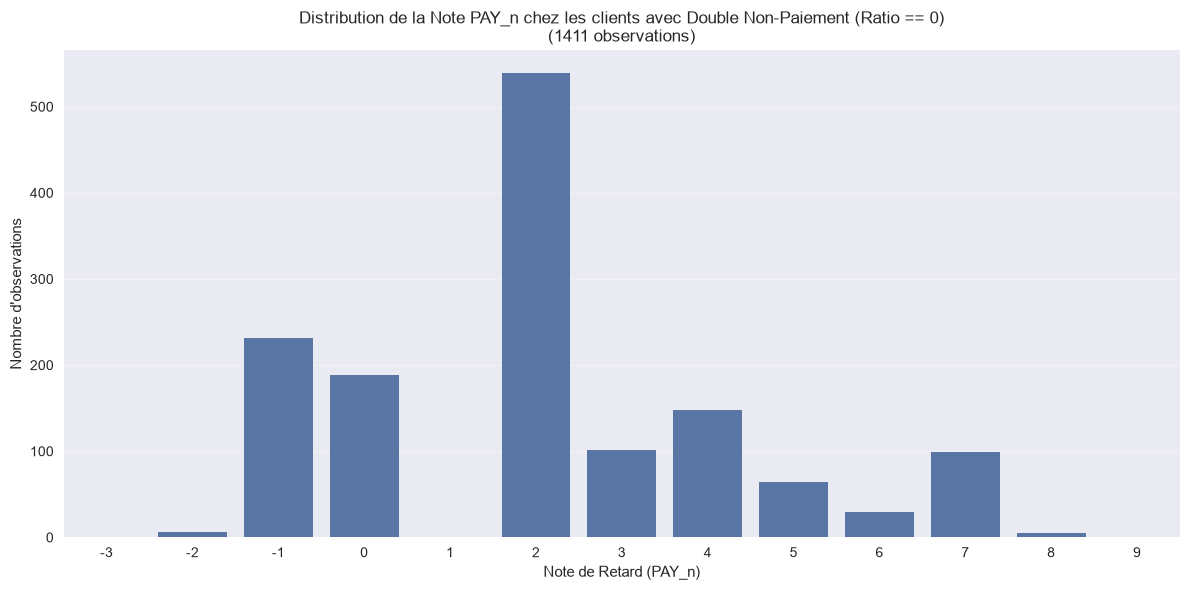

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tes colonnes de ratio définies
ratio_columns = [
    'ratio_PAY_AMT2_to_BILL_AMT3', 
    'ratio_PAY_AMT3_to_BILL_AMT4', 
    'ratio_PAY_AMT4_to_BILL_AMT5', 
    'ratio_PAY_AMT5_to_BILL_AMT6'
]

# Liste pour stocker les notes PAY_n des clients en double non-paiement
notes_double_zero = []

print("--- Analyse : Notes PAY_n pour Double Ratio == 0 (Consécutif) ---")

# On boucle sur les paires de colonnes adjacentes
for i in range(len(ratio_columns) - 1):
    col_r1 = ratio_columns[i]      # Ratio du mois n (ex: ...PAY_AMT2...)
    col_r2 = ratio_columns[i+1]    # Ratio du mois n+1 (ex: ...PAY_AMT3...)

    # Identification de la colonne PAY_n associée au premier ratio
    pay_part = col_r1.split('_to_')[0] 
    n_str = pay_part.replace('ratio_', '').replace('PAY_AMT', '')
    col_pay_n = f"PAY_{n_str}"  # Ex: PAY_2
    
    if col_pay_n not in df.columns:
        continue

    # Condition : Les deux ratios consécutifs sont égaux à 0 (ou quasi-nul)
    # On utilise une petite marge de tolérance pour les flottants
    mask_double_zero = np.logical_and(
        np.abs(df[col_r1]) < 0.01, 
        np.abs(df[col_r2]) < 0.01
    )

    if mask_double_zero.sum() == 0:
        continue

    # On extrait la note PAY_n pour toutes les lignes qui satisfont cette condition
    notes_double_zero.extend(df.loc[mask_double_zero, col_pay_n].tolist())

# --- Analyse et Visualisation ---
if len(notes_double_zero) > 0:
    df_res = pd.DataFrame({'Note_Pay': notes_double_zero})
    
    print(f"\nNombre d'observations avec double ratio == 0 : {len(df_res)}")
    print("\nRépartition des notes PAY_n pour ces clients :")
    print(df_res['Note_Pay'].value_counts().sort_index())

    # Graphique de la distribution
    plt.figure(figsize=(12, 6))
    
    # On s'assure que l'axe X est bien ordonné même si certaines notes sont absentes
    min_note = df_res['Note_Pay'].min() if not df_res.empty else -6
    max_note = df_res['Note_Pay'].max() if not df_res.empty else 8
    
    sns.countplot(data=df_res, x='Note_Pay', order=range(int(min_note)-1, int(max_note)+2))
    
    plt.title(f'Distribution de la Note PAY_n chez les clients avec Double Non-Paiement (Ratio == 0)\n({len(df_res)} observations)')
    plt.xlabel('Note de Retard (PAY_n)')
    plt.ylabel('Nombre d\'observations')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("Aucun client trouvé avec un double ratio == 0 consécutif.")

**Interprétation**  
Pour un encours strictement positif, si un client ne paie rien pendant 2 mois consécutifs, PAY_n est plutot codifié en retard. Mais 400 clients sur 1400 ont toujours une note saine après 2 échéances impayées.  
C'est évidemment incohérent d'un point de vue métier.  
Ce sera problématique pour entraîner les modèles si la note des incidents est fortement faussée.  
Attention : un client peut apparaitre plusieurs fois dans le graphes s'il a plus de 2 ratios de paiement consécutifs impayés

--- Décompte des clients par nombre d'occurrences de Ratio == 0 ---
Nombre de clients avec exactement 0 fois un ratio nul : 22437
Nombre de clients avec exactement 1 fois un ratio nul : 5016
Nombre de clients avec exactement 2 fois un ratio nul : 1849
Nombre de clients avec exactement 3 fois un ratio nul : 407
Nombre de clients avec exactement 4 fois un ratio nul : 113
Nombre de clients avec exactement 5 fois un ratio nul : 174
Nombre de clients avec 6 ou plus de ratios nuls : 0


C:\Users\johan\AppData\Local\Temp\ipykernel_2236\2511925414.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels_plot, y=values_plot, palette='viridis')


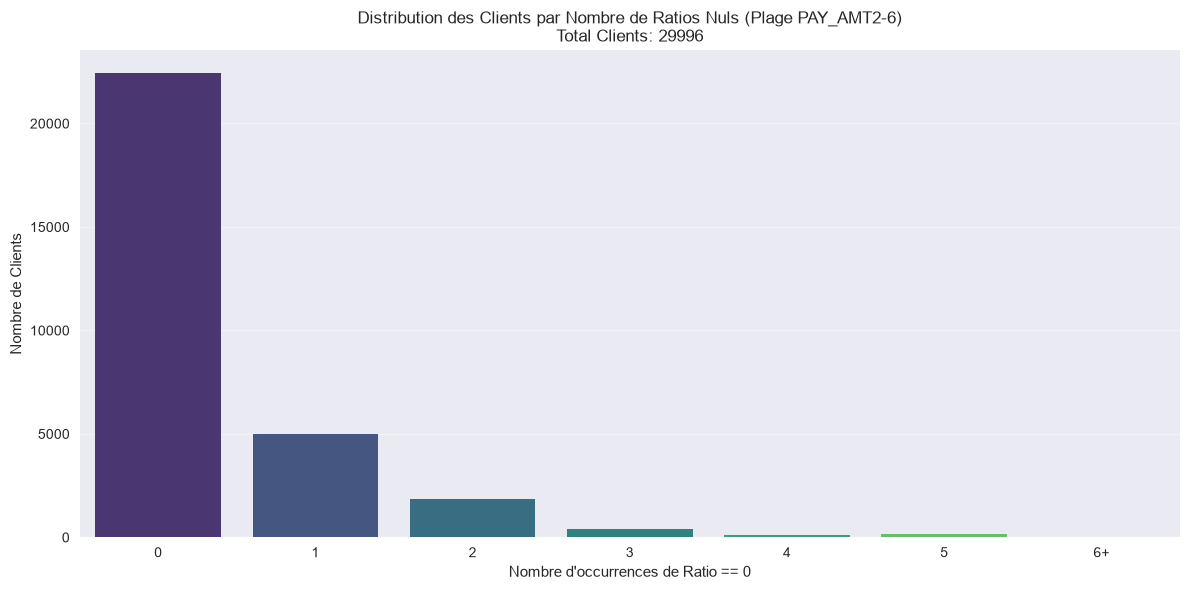

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cols_ciblees = [
    'ratio_PAY_AMT1_to_BILL_AMT2',
    'ratio_PAY_AMT2_to_BILL_AMT3', 
    'ratio_PAY_AMT3_to_BILL_AMT4', 
    'ratio_PAY_AMT4_to_BILL_AMT5', 
    'ratio_PAY_AMT5_to_BILL_AMT6'
]

    
# 2. Création d'un masque booléen : True si le ratio est ~0, False sinon
# On utilise une tolérance très faible (< 0.01) pour éviter les problèmes d'arrondi float
mask_zeros = np.abs(df_ratios) < 0.01

# 3. Comptage des occurrences de zéro PAR CLIENT (par ligne)
# sum(axis=1) additionne les True (valeur 1) pour chaque ligne
zero_counts_per_client = mask_zeros.sum(axis=1)

# 4. Filtrage et Décompte pour les cas spécifiques (0, 1, ..., 5 fois)
# On filtre pour ne garder que les clients qui ont eu au moins un zero, 
# ou on garde tout si tu veux voir ceux à 0 aussi.
# Ici, je vais compter l'histogramme complet de 0 à max(zeros).

# Comptage des effectifs : combien de clients ont eu X occurrences ?
freq_distribution = zero_counts_per_client.value_counts().sort_index()



print("--- Décompte des clients par nombre d'occurrences de Ratio == 0 ---")

for i in range(6): # De 0 à 5
    count_clients = freq_distribution.get(i, 0)
    print(f"Nombre de clients avec exactement {i} fois un ratio nul : {count_clients}")
    
# Pour les cas > 5 (6, 7...)
clients_plus_5 = zero_counts_per_client[zero_counts_per_client >= 6].shape[0]
print(f"Nombre de clients avec 6 ou plus de ratios nuls : {clients_plus_5}")

# --- Visualisation Graphique ---
# On prépare les données pour le graphique en ne gardant que 0 à 5, et on regroupe >5 dans une catégorie "6+"
labels_plot = []
values_plot = []

for i in range(6):
    if i in freq_distribution.index:
        labels_plot.append(str(i))
        values_plot.append(freq_distribution[i])
    else:
        labels_plot.append(str(i))
        values_plot.append(0) # Si aucune donnée pour cette case
        
# Ajout du cas "6+"
labels_plot.append("6+")
values_plot.append(clients_plus_5)

plt.figure(figsize=(12, 6))
sns.barplot(x=labels_plot, y=values_plot, palette='viridis')
plt.title(f'Distribution des Clients par Nombre de Ratios Nuls (Plage PAY_AMT2-6)\nTotal Clients: {len(zero_counts_per_client)}')
plt.xlabel('Nombre d\'occurrences de Ratio == 0')
plt.ylabel('Nombre de Clients')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
import pandas as pd
import numpy as np

# Tes colonnes définies pour le calcul
cols_ciblees = [
    'ratio_PAY_AMT1_to_BILL_AMT2',
    'ratio_PAY_AMT2_to_BILL_AMT3', 
    'ratio_PAY_AMT3_to_BILL_AMT4', 
    'ratio_PAY_AMT4_to_BILL_AMT5', 
    'ratio_PAY_AMT5_to_BILL_AMT6'
]

# 1. Calcul du nombre de zéros par client (ligne)
df_ratios = df[cols_ciblees]
# Masque : True si abs(ratio) < tolérance (pour gérer les flottants proches de 0)
mask_zeros = np.abs(df_ratios) < 0.01

# Somme par ligne -> nombre de colonnes ciblées qui sont ~0 pour ce client
counts_zeros_per_client = mask_zeros.sum(axis=1)

# --- BOUCLE SUR LES CAS DEMANDÉS (3, 4 et 5 fois) ---
cas_cibles = [3, 4, 5]

for nb_zeros in cas_cibles:
    print("\n" + "="*60)
    print(f"--- GROUPE : Clients avec EXACTEMENT {nb_zeros} Ratios Nuls ---")
    print("="*60)
    
    # On filtre l'index original pour le nombre exact de zéros
    idx_groupe = counts_zeros_per_client[counts_zeros_per_client == nb_zeros].index
    
    if len(idx_groupe) > 0:
        print(f"Nombre total de clients dans ce groupe : {len(idx_groupe)}")
        
        # On prend les 10 premières lignes COMPLETES du dataframe original
        df_head = df.loc[idx_groupe].head(10)
        
        print(f"\n--- APERÇU DES 10 PREMIÈRES LIGNES (LIGNES COMPLÈTES) ---")
        # pd.set_option pour afficher toutes les colonnes sans troncature si possible
        with pd.option_context('display.max_columns', None, 'display.width', 1000):
            print(df_head)
        
    else:
        print(f"Aucun client trouvé avec exactement {nb_zeros} ratios nuls.")

# --- RÉCAPITULATIF GLOBAL (pour info) ---
print("\n" + "="*60)
print("--- RÉCAPITULATIF DU NOMBRE DE CLIENTS PAR NOMBRE DE ZEROS ---")
print("="*60)

dist_zeros = counts_zeros_per_client.value_counts().sort_index()

for i in range(0, 6): # De 0 à 5
    count = dist_zeros.get(i, 0)
    print(f"Nombre de clients avec exactement {i} ratio(s) nul(s) : {count}")




--- GROUPE : Clients avec EXACTEMENT 3 Ratios Nuls ---
Nombre total de clients dans ce groupe : 407

--- APERÇU DES 10 PREMIÈRES LIGNES (LIGNES COMPLÈTES) ---
     LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  dpnm  ratio_PAY_AMT1_to_BILL_AMT2  ratio_PAY_AMT2_to_BILL_AMT3  ratio_PAY_AMT3_to_BILL_AMT4  ratio_PAY_AMT4_to_BILL_AMT5  ratio_PAY_AMT5_to_BILL_AMT6
ID                                                                                                                                                                                                                                                                                                                                                                          
59      200000    2          1         2   34     -1      3      2      2      2      2       1587       1098 

Quand on regarde le détail de quelques lignes, des incohérentes flagrantes sont visibles dans la codification des colonnes 'PAY_n'.  
On observe un changement de codification en PAY_2 avec des incidents qui redescendent à 2 sans payement de la part des clients, et pour lesquels l'encours est stable sur les 6 mois.  
Pour les modèles et pour la visualisation ces changements de codification sont problématiques

Je crée une feature 'ratio_BILL_LIMITn' pour voir l'utilisation par rapport au plafond chaque mois

In [62]:
import pandas as pd
import numpy as np

# Vérification rapide des colonnes BILL_AMT existantes
bill_cols = [col for col in df.columns if col.startswith('BILL_AMT')]
print(f"Colonnes BILL_AMT trouvées : {bill_cols}")

# Boucle pour créer les 6 nouvelles colonnes de ratio
for i, bill_col in enumerate(bill_cols):
    # Nom de la nouvelle colonne (ex: ratio_BILL_LIMIT1, ratio_BILL_LIMIT2, etc.)
    ratio_col = f'ratio_BILL_LIMIT{i+1}'
    
    # Application de la formule conditionnelle
    # Si BILL_AMTn > 0 alors (BILL_AMTn / LIMIT_BAL) * 100, sinon NaN
    df[ratio_col] = np.where(
        df[bill_col] >= 0, 
        (df[bill_col] / df['LIMIT_BAL']) * 100, 
        np.nan
    )
    
    print(f"Création de {ratio_col} terminée.")

# Affichage des premières lignes pour inspection
# On filtre pour ne voir que les colonnes BILL_AMT et ratio_BILL_LIMIT concernées
cols_to_show = bill_cols + [f'ratio_BILL_LIMIT{n}' for n in range(1, 7)]
pd.option_context('display.max_columns', None, 'display.width', 1000)

print("\n--- Aperçu des nouveaux ratios ---")
df[cols_to_show].head(10)

Colonnes BILL_AMT trouvées : ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
Création de ratio_BILL_LIMIT1 terminée.
Création de ratio_BILL_LIMIT2 terminée.
Création de ratio_BILL_LIMIT3 terminée.
Création de ratio_BILL_LIMIT4 terminée.
Création de ratio_BILL_LIMIT5 terminée.
Création de ratio_BILL_LIMIT6 terminée.

--- Aperçu des nouveaux ratios ---


,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,ratio_BILL_LIMIT1,ratio_BILL_LIMIT2,ratio_BILL_LIMIT3,ratio_BILL_LIMIT4,ratio_BILL_LIMIT5,ratio_BILL_LIMIT6
ID,,,,,,,,,,,,
1,3913,3102,689,0,0,0,19.565000,15.510000,3.445000,0.000000,0.000000,0.000000
2,2682,1725,2682,3272,3455,3261,2.235000,1.437500,2.235000,2.726667,2.879167,2.717500
3,29239,14027,13559,14331,14948,15549,32.487778,15.585556,15.065556,15.923333,16.608889,17.276667
4,46990,48233,49291,28314,28959,29547,93.980000,96.466000,98.582000,56.628000,57.918000,59.094000
5,8617,5670,35835,20940,19146,19131,17.234000,11.340000,71.670000,41.880000,38.292000,38.262000
6,64400,57069,57608,19394,19619,20024,128.800000,114.138000,115.216000,38.788000,39.238000,40.048000
7,367965,412023,445007,542653,483003,473944,73.593000,82.404600,89.001400,108.530600,96.600600,94.788800
8,11876,380,601,221,-159,567,11.876000,0.380000,0.601000,0.221000,NaN,0.567000
9,11285,14096,12108,12211,11793,3719,8.060714,10.068571,8.648571,8.722143,8.423571,2.656429


In [63]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm',
       'ratio_PAY_AMT1_to_BILL_AMT2', 'ratio_PAY_AMT2_to_BILL_AMT3',
       'ratio_PAY_AMT3_to_BILL_AMT4', 'ratio_PAY_AMT4_to_BILL_AMT5',
       'ratio_PAY_AMT5_to_BILL_AMT6', 'ratio_BILL_LIMIT1', 'ratio_BILL_LIMIT2',
       'ratio_BILL_LIMIT3', 'ratio_BILL_LIMIT4', 'ratio_BILL_LIMIT5',
       'ratio_BILL_LIMIT6'],
      dtype='str')

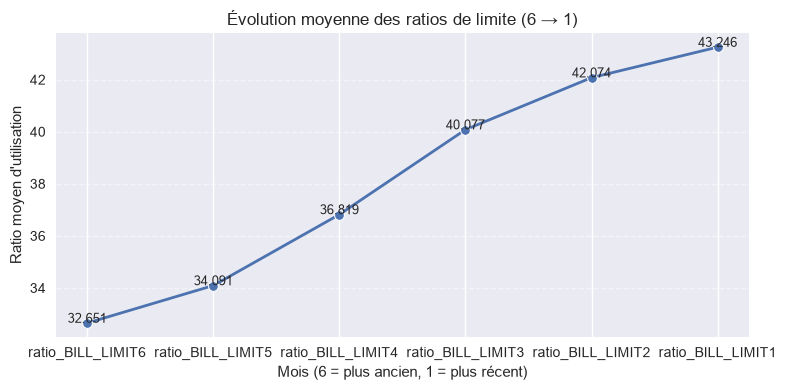

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Liste des colonnes dans l'ordre souhaité (6 -> 1)
colonnes = [
    'ratio_BILL_LIMIT6', 
    'ratio_BILL_LIMIT5', 
    'ratio_BILL_LIMIT4', 
    'ratio_BILL_LIMIT3', 
    'ratio_BILL_LIMIT2', 
    'ratio_BILL_LIMIT1'
]

# Filtrer pour ne garder que celles qui existent dans ton dataframe
colonnes_presentes = [c for c in colonnes if c in df.columns]

if colonnes_presentes:
    # 2. Calcul de la moyenne par colonne
    moyennes = df[colonnes_presentes].mean()

    # 3. Visualisation simple (courbe linéaire pour voir l'évolution)
    plt.figure(figsize=(8, 4))
    
    # On utilise les index (6,5,4...) pour l'axe X et les valeurs moyennes pour l'axe Y
    sns.lineplot(x=moyennes.index, y=moyennes.values, marker='o', linewidth=2)
    
    plt.title('Évolution moyenne des ratios de limite (6 → 1)')
    plt.xlabel('Mois (6 = plus ancien, 1 = plus récent)')
    plt.ylabel('Ratio moyen d\'utilisation')
    
    # Ajouter les valeurs sur les points pour plus de clarté
    for i, v in enumerate(moyennes.values):
        plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Vérifie les noms des colonnes dans ton dataframe.")

**Interprétation**
Sur les 6 mois, le taux d'utilisation des cartes actives a bondi de 10 points en moyenne

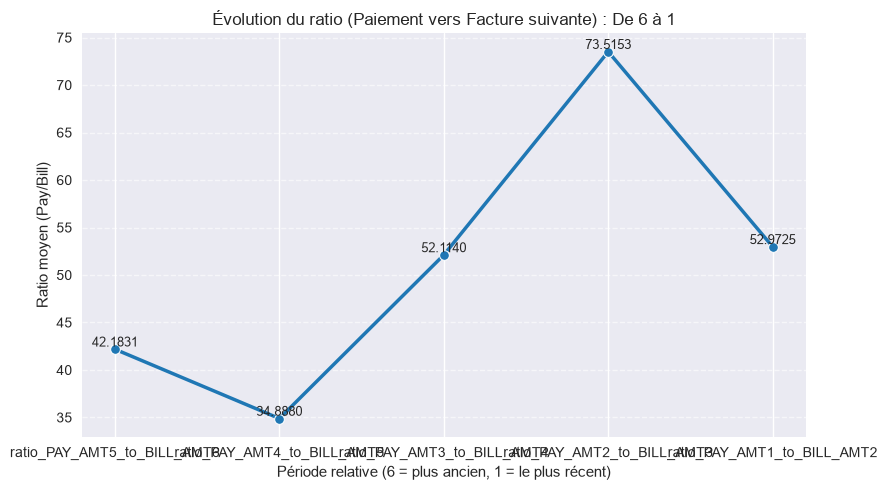

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Définition de l'ordre d'affichage souhaité (de 6 à 1)
# On construit la liste en partant du suffixe 6 jusqu'à 1
ordre_souhaite = [f'ratio_PAY_AMT{i}_to_BILL_AMT{i+1}' for i in range(6, 0, -1)]

# Filtrer pour ne garder que les colonnes réellement présentes dans le dataframe
colonnes_actives = [col for col in ordre_souhaite if col in df.columns]

if len(colonnes_actives) > 0:
    # 2. Extraction des données et calcul de la moyenne par mois
    # On prend les colonnes dans l'ordre du graphique (6 -> 1)
    df_temp = df[colonnes_actives]
    
    # Calcul des moyennes
    moyennes = df_temp.mean()

    # 3. Visualisation
    plt.figure(figsize=(9, 5))
    
    # sns.lineplot prend les index (6,5,4...) comme axe X et les valeurs moyennes en Y
    sns.lineplot(
        x=moyennes.index, 
        y=moyennes.values, 
        marker='o', 
        linewidth=2.5,
        color='#1f77b4'  # Bleu standard pour la clarté
    )

    plt.title('Évolution du ratio (Paiement vers Facture suivante) : De 6 à 1')
    plt.xlabel('Période relative (6 = plus ancien, 1 = le plus récent)')
    plt.ylabel('Ratio moyen (Pay/Bill)')
    
    # Ajout des valeurs textuelles pour précision
    for i, val in enumerate(moyennes.values):
        plt.text(i, val + 0.005, f'{val:.4f}', ha='center', va='bottom', fontsize=9)

    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print(f"Attention : Aucune des colonnes de la liste '{ordre_souhaite}' n'a été trouvée.")

**Interprétation**  
pas de tendance

C:\Users\johan\AppData\Local\Temp\ipykernel_2236\407454231.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=proportions_pct.index, y=proportions_pct.values, palette='viridis')


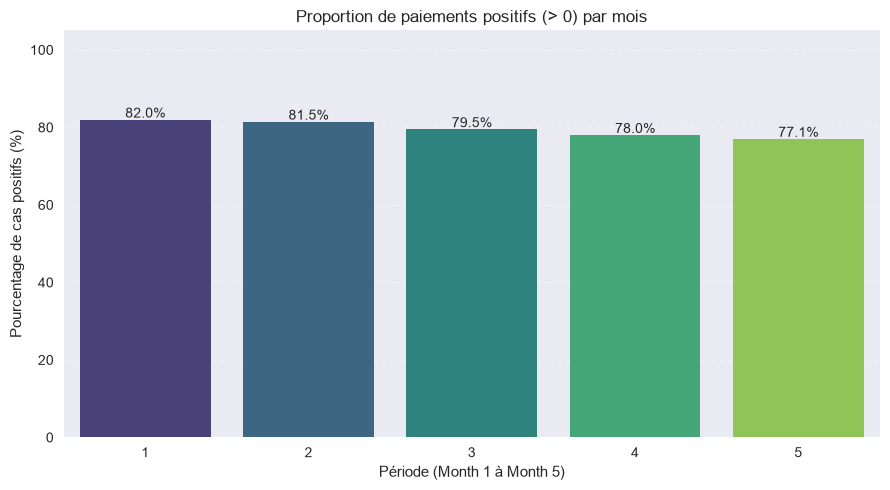

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Définition des colonnes dans l'ordre "1 vers 5" (comme demandé : Month 1 à Month 5)
# Note: Month 1 est le plus récent, Month 5 est le plus ancien de cet ensemble
colonnes = [
    'ratio_PAY_AMT1_to_BILL_AMT2',  # Month 1
    'ratio_PAY_AMT2_to_BILL_AMT3',  # Month 2
    'ratio_PAY_AMT3_to_BILL_AMT4',  # Month 3
    'ratio_PAY_AMT4_to_BILL_AMT5',  # Month 4
    'ratio_PAY_AMT5_to_BILL_AMT6'   # Month 5
]

# Filtrer pour ne garder que les colonnes présentes
colonnes_actives = [c for c in colonnes if c in df.columns]

if len(colonnes_actives) >= 2:
    # 2. Calcul de la proportion de valeurs > 0 pour chaque colonne
    # .mean() sur un booléen (condition > 0) donne la fraction de True (positifs)
    proportions = df[colonnes_actives].apply(lambda x: (x > 0).mean())

    # Normalisation en pourcentage pour l'affichage
    proportions_pct = proportions * 100

    # 3. Visualisation en histogramme (bar chart)
    plt.figure(figsize=(9, 5))
    
    sns.barplot(x=proportions_pct.index, y=proportions_pct.values, palette='viridis')
    
    # Ajouter les valeurs sur les barres pour plus de clarté
    for i, val in enumerate(proportions_pct.values):
        plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10)

    plt.title('Proportion de paiements positifs (> 0) par mois')
    plt.xlabel('Période (Month 1 à Month 5)')
    plt.ylabel('Pourcentage de cas positifs (%)')
    
    # Personnalisation de l'axe X pour être très clair
    labels = [c.split('_to_')[0].split('PAY_AMT')[1] for c in proportions_pct.index]
    plt.xticks(range(len(proportions_pct.index)), labels)

    plt.ylim(0, 105) # Petit marge au dessus
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Il manque des colonnes pour réaliser l'analyse.")

**Interprétation**  
La proportion de clients qui paient tout ou partie de leur échéance augmente.  
Il faut aussi y voir que 20% des échéances ne sont pas honorées dans les 30 jours !

C:\Users\johan\AppData\Local\Temp\ipykernel_2236\365951633.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=proportions_pct.index, y=proportions_pct.values, palette='viridis')


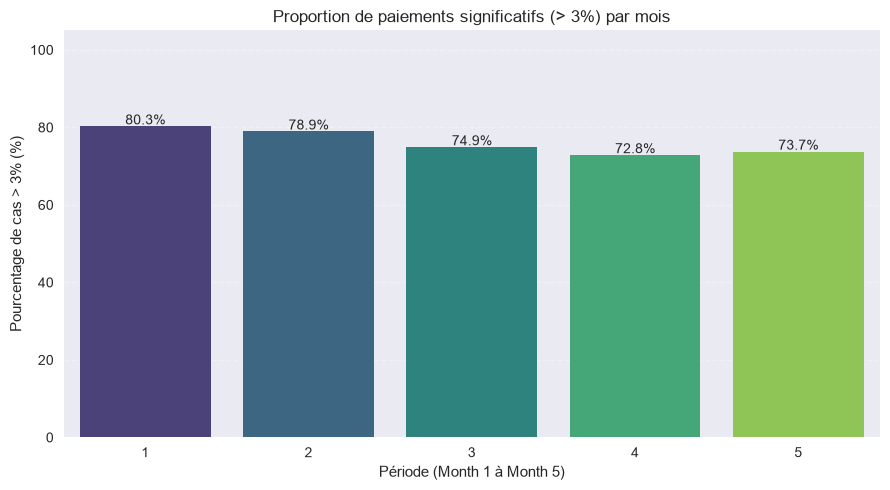

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Définition des colonnes (Month 1 à Month 5)
colonnes = [
    'ratio_PAY_AMT1_to_BILL_AMT2',
    'ratio_PAY_AMT2_to_BILL_AMT3',
    'ratio_PAY_AMT3_to_BILL_AMT4',
    'ratio_PAY_AMT4_to_BILL_AMT5',
    'ratio_PAY_AMT5_to_BILL_AMT6'
]

# Filtrer pour ne garder que les colonnes présentes
colonnes_actives = [c for c in colonnes if c in df.columns]

if len(colonnes_actives) >= 2:
    # 2. Calcul de la proportion où le ratio est STRICTEMENT SUPÉRIEUR à 0.03 (3%)
    # On applique la condition > 0.03 colonne par colonne
    proportions = df[colonnes_actives].apply(lambda x: (x > 3).mean())

    # En pourcentage
    proportions_pct = proportions * 100

    # 3. Visualisation en histogramme
    plt.figure(figsize=(9, 5))
    
    # On garde la même palette ou on change selon ta préférence (ici 'viridis' reste lisible)
    sns.barplot(x=proportions_pct.index, y=proportions_pct.values, palette='viridis')
    
    # Ajout des valeurs sur les barres
    for i, val in enumerate(proportions_pct.values):
        plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10)

    plt.title('Proportion de paiements significatifs (> 3%) par mois')
    plt.xlabel('Période (Month 1 à Month 5)')
    plt.ylabel('Pourcentage de cas > 3% (%)')
    
    # Labels X clairs (1, 2, 3, 4, 5)
    labels = [c.split('_to_')[0].split('PAY_AMT')[1] for c in proportions_pct.index]
    plt.xticks(range(len(proportions_pct.index)), labels)

    plt.ylim(0, 105) 
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Colonnes manquantes pour l'analyse.")

**Interprétation**  
Même tendance, mais on voit qu'une part des clients (2 à 5% selon les mois) paient partiellement leur échéance

C:\Users\johan\AppData\Local\Temp\ipykernel_2236\2196768509.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels_x, y=taux_activation_globale, palette='coolwarm')


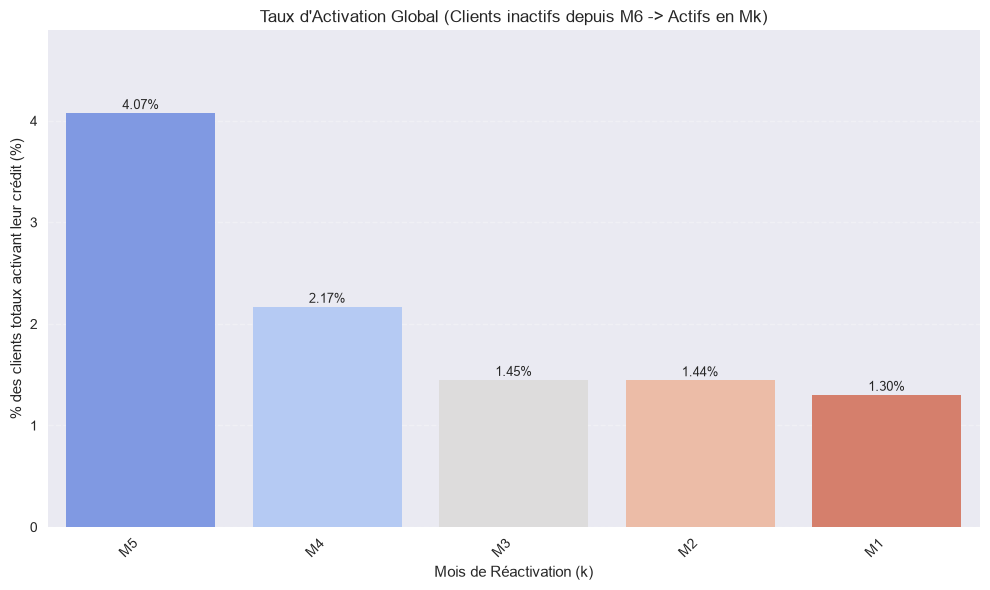

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Préparation des colonnes BILL_AMT
colonnes_bill = [f'BILL_AMT{i}' for i in range(6, 0, -1)]
cols_existantes = [c for c in colonnes_bill if c in df.columns]

if len(cols_existantes) < 2:
    print("Pas assez de colonnes BILL_AMT disponibles.")
else:
    taux_activation_globale = []
    labels_x = []
    n_total_clients = len(df)

    # On calcule pour chaque mois k (de 5 down to 1) la probabilité qu'un client :
    # 1. Ait BILL_AMT == 0 pour tous les mois de 6 à k+1 (inactivité prolongée)
    # 2. Aie BILL_AMT > 0 en mois k (réactivation)
    
    for k in range(5, 0, -1):
        col_activ = f'BILL_AMT{k}'
        
        if col_activ not in df.columns:
            taux_activation_globale.append(0)
            labels_x.append(f'M{k} (missing)')
            continue

        # Masque d'inactivité prolongée : 0 pour tous les mois [6, k+1]
        mask_inactif = pd.Series([True] * n_total_clients, index=df.index)
        
        for m in range(6, k, -1):
            col_m = f'BILL_AMT{m}'
            if col_m in df.columns:
                # On applique la condition stricte : solde nul
                mask_inactif &= (df[col_m] == 0)
        
        # Masque de réactivation : > 0 en mois k
        mask_reactivation = df[col_activ] > 0
        
        # Intersection : Les deux conditions doivent être vraies
        # Note: Si un client n'a pas de données pour l'un des mois (NaN), 
        # il ne sera pas compté comme "inactif avec certitude" ni "réactivé". 
        # C'est la méthode stricte.
        
        mask_total = mask_inactif & mask_reactivation
        
        # Calcul du taux par rapport à l'ENSEMBLE du dataset
        count_activation = mask_total.sum()
        taux_global = (count_activation / n_total_clients) * 100
        
        taux_activation_globale.append(taux_global)
        labels_x.append(f'M{k}')

    # 2. Visualisation
    plt.figure(figsize=(10, 6))
    
    sns.barplot(x=labels_x, y=taux_activation_globale, palette='coolwarm')
    
    # Ajout des valeurs
    for i, val in enumerate(taux_activation_globale):
        if val > 0: # Afficher seulement si > 0 pour éviter le bruit
            plt.text(i, val + (max(taux_activation_globale)*0.01 if max(taux_activation_globale)>0 else 0.1), 
                     f'{val:.2f}%', ha='center', fontsize=9)

    plt.title('Taux d\'Activation Global (Clients inactifs depuis M6 -> Actifs en Mk)')
    plt.xlabel('Mois de Réactivation (k)')
    plt.ylabel('% des clients totaux activant leur crédit (%)')
    
    # Ajustement Y
    max_val = max(taux_activation_globale) if taux_activation_globale else 1
    plt.ylim(0, max_val * 1.2 if max_val > 0 else 5)
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

**Interprétation**
Le taux d'activation ou réactivation de comptes diminue fortement entre M-5 et M-3 pour atteindre un taux de 1.3% sur le mois le plus récent.  
Attention, la statistique de M-5 peut être augmentée par une non utilisation succinte en M-6.  
On peut aussi interpréter cette statistiques comme : moins de compte sortent de recouvrement/contentieux s'il s'agit ici de compte gelés pour défaut de paiement excessif

C:\Users\johan\AppData\Local\Temp\ipykernel_2236\2306945408.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels_x, y=taux_decongestion, palette='Reds')


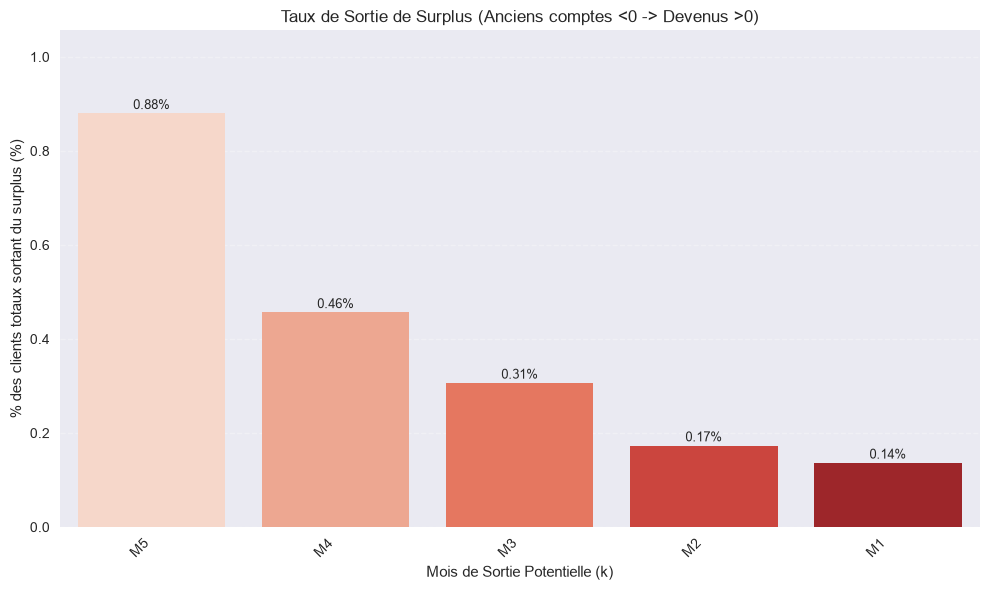

Taux de 'décongestion' calculé : passage de solde négatif vers positif.


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Préparation des colonnes BILL_AMT (6 à 1)
colonnes_bill = [f'BILL_AMT{i}' for i in range(6, 0, -1)]
cols_existantes = [c for c in colonnes_bill if c in df.columns]

if len(cols_existantes) < 2:
    print("Pas assez de colonnes BILL_AMT disponibles.")
else:
    taux_decongestion = []
    labels_x = []
    n_total_clients = len(df)

    # On cherche la sortie de l'état "< 0" vers "> 0"
    # Le "gel" ou surplus commence à M6.
    
    for k in range(5, 0, -1):
        col_sortie = f'BILL_AMT{k}'       # Mois où on espère un retour à > 0
        
        if col_sortie not in df.columns:
            taux_decongestion.append(0)
            labels_x.append(f'M{k} (missing)')
            continue

        # Masque d'inactivité en surplus : < 0 pour tous les mois [6, k+1]
        # Note: On traite les NaN comme "pas de donnée", donc on exclut ceux qui ont des trous.
        mask_surplus = pd.Series([True] * n_total_clients, index=df.index)
        
        for m in range(6, k, -1):
            col_m = f'BILL_AMT{m}'
            if col_m in df.columns:
                # Condition stricte : Solde négatif (débit versé > dette)
                mask_surplus &= (df[col_m] < 0)
        
        # Masque de sortie de surplus : > 0 en mois k
        mask_sortie = df[col_sortie] > 0
        
        # Intersection : Étaient tous en négatif ET sont maintenant en positif
        mask_total = mask_surplus & mask_sortie
        
        # Calcul du taux par rapport à l'ENSEMBLE du dataset
        count_decongeste = mask_total.sum()
        taux_global = (count_decongeste / n_total_clients) * 100
        
        taux_decongestion.append(taux_global)
        labels_x.append(f'M{k}')

    # 2. Visualisation
    plt.figure(figsize=(10, 6))
    
    # Palette différente pour marquer le contraste (ex: rouge/orange pour le "décongé")
    sns.barplot(x=labels_x, y=taux_decongestion, palette='Reds')
    
    # Ajout des valeurs
    for i, val in enumerate(taux_decongestion):
        if val > 0:
            plt.text(i, val + (max(taux_decongestion)*0.01 if max(taux_decongestion)>0 else 0.1), 
                     f'{val:.2f}%', ha='center', fontsize=9)

    plt.title('Taux de Sortie de Surplus (Anciens comptes <0 -> Devenus >0)')
    plt.xlabel('Mois de Sortie Potentielle (k)')
    plt.ylabel('% des clients totaux sortant du surplus (%)')
    
    # Ajustement Y
    max_val = max(taux_decongestion) if taux_decongestion else 1
    plt.ylim(0, max_val * 1.2 if max_val > 0 else 5)
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("Taux de 'décongestion' calculé : passage de solde négatif vers positif.")

**Interpétation**  
Ici aussi 2 inteprétations possibles selon que le compte est réellement en état de surpaiement du client ou géré dans une autre phase.  
Taux globalement très faible mais on remarque que comme pour les comptes à 0, le taux de sortie des comptes en négatifs diminue fortement entre M-5 et M-3.  
2 possibilités face aux 2 précédents constats :
- la banque régularise moins de comptes, les clients ont moins la possibilités de régulariser un défaut important à mesure que les banques restreignent l'accès au crédit
- la banque autorise moins d'ouvertures de comptes à mesure que les défaillances se font sentir

In [70]:
import pandas as pd
import numpy as np

# 1. Définition des colonnes BILL_AMT de 1 à 6
cols_bill = [f'BILL_AMT{i}' for i in range(1, 7)]
cols_presentes = [c for c in cols_bill if c in df.columns]

if len(cols_presentes) == 6:
    # On prend uniquement les colonnes d'intérêt pour le calcul
    df_bill = df[cols_presentes]
    
    # 2. Identification des lignes où BILL_AMT est constant sur les 6 mois
    # Si l'écart-type (std) est nul, toutes les valeurs sont identiques.
    std_per_row = df_bill.std(axis=1)
    mask_constant = std_per_row == 0
    
    nb_total_constantes = mask_constant.sum()
    
    if nb_total_constantes > 0:
        # On extrait ces lignes spécifiques pour analyse
        df_constants = df.loc[mask_constant].copy()
        
        # Puisque std=0, la valeur est identique sur les 6 mois.
        # On peut se baser sur n'importe quelle colonne (ex: BILL_AMT1) pour classer la ligne.
        val_constante = df_constants['BILL_AMT1']
        
        # Catégorisation
        mask_negatif = val_constante < 0
        mask_nul = val_constante == 0
        mask_positif = val_constante > 0
        
        nb_negatif = mask_negatif.sum()
        nb_nul = mask_nul.sum()
        nb_positif = mask_positif.sum()
        
        # Vérification de la cohérence (somme des parties = tout)
        if nb_negatif + nb_nul + nb_positif == nb_total_constantes:
            print("--- Analyse des Soldes BILL_AMT Constants sur 6 Mois ---")
            print(f"Total lignes avec BILL_AMT constant : {nb_total_constantes}")
            print(f"  - Strictement Nuls (== 0) : {nb_nul} ({(nb_nul/nb_total_constantes)*100:.2f}%)")
            print(f"  - Positifs (> 0) : {nb_positif} ({(nb_positif/nb_total_constantes)*100:.2f}%)")
            print(f"  - Négatifs (< 0) : {nb_negatif} ({(nb_negatif/nb_total_constantes)*100:.2f}%)")
            
        else:
            print("Erreur de cohérence dans le comptage.")

else:
    print(f"Impossible : Seules {len(cols_presentes)} colonnes BILL_AMT sur 6 sont présentes.")

--- Analyse des Soldes BILL_AMT Constants sur 6 Mois ---
Total lignes avec BILL_AMT constant : 1227
  - Strictement Nuls (== 0) : 866 (70.58%)
  - Positifs (> 0) : 298 (24.29%)
  - Négatifs (< 0) : 63 (5.13%)


In [71]:
import pandas as pd

cols_bill = [f'BILL_AMT{i}' for i in range(1, 7)]
cols_pay = [f'PAY_AMT{i}' for i in range(1, 7)]

# 1. Condition : tous les PAY_AMTn sont égaux à 0 sur les 6 mois
mask_pay_zero = (df[cols_pay] == 0).all(axis=1)

# 2. Condition : BILL_AMTn est strictement constant sur les 6 mois
mask_bill_const = df[cols_bill].std(axis=1) == 0

# 3. Intersection des deux règles
mask_target = mask_bill_const & mask_pay_zero
df_filtered = df[mask_target]

# 4. Ventilation selon la valeur du solde constant (BILL_AMT1 sert de référence)
val_bill = df_filtered['BILL_AMT1']

nb_positif = (val_bill > 0).sum()
nb_nul = (val_bill == 0).sum()
nb_negatif = (val_bill < 0).sum()
total = len(df_filtered)

print("--- DÉCOMPTE : BILL_AMT constant ET PAY_AMT == 0 sur 6 mois ---")
print(f"Total clients concernés : {total}")
if total > 0:
    print(f"  • Facture constante > 0 : {nb_positif} ({nb_positif / total * 100:.2f} %)")
    print(f"  • Facture constante == 0 : {nb_nul} ({nb_nul / total * 100:.2f} %)")
    print(f"  • Facture constante < 0 : {nb_negatif} ({nb_negatif / total * 100:.2f} %)")

--- DÉCOMPTE : BILL_AMT constant ET PAY_AMT == 0 sur 6 mois ---
Total clients concernés : 954
  • Facture constante > 0 : 111 (11.64 %)
  • Facture constante == 0 : 795 (83.33 %)
  • Facture constante < 0 : 48 (5.03 %)


795 clients sont clairement dormants au sens bancaire du terme : aucune opération créditrice ou débitrice sur les 6 mois. Ou selon le SI et ses artéfacts, ils peuvent être en gestion contentieuse.  
**=> Au pire, on les supprime du jeu de données pour ne s'intéresser qu'aux clients actifs en gestion normale, au mieux on masque ces lignes lors des graphiques et de l'apprentissage automatique.**
Il faut creuser sur les autres catégories

In [72]:
import pandas as pd
import numpy as np

# 1. Colonnes concernées
cols_bill = [f'BILL_AMT{i}' for i in range(1, 7)]
cols_pay = [f'PAY_AMT{i}' for i in range(1, 7)]
cols_presentes = [c for c in cols_bill + cols_pay if c in df.columns]

if len(cols_presentes) == 12:
    # Condition globale : TOUT est constant (BILL et PAY) ET PAY est partout à 0
    mask_constant_pay_zero = (df[cols_pay].apply(lambda x: (x == 0).all(), axis=1)) & \
                             (df[cols_bill].std(axis=1) == 0)
    
    df_cibles = df[mask_constant_pay_zero]
    
    if len(df_cibles) > 0:
        # On utilise BILL_AMT1 pour classifier
        val_bill = df_cibles['BILL_AMT1']
        
        # --- CAS 1 : NÉGATIF (< 0) ---
        mask_negatif = val_bill < 0
        if mask_negatif.any():
            print("--- Aperçu : BILL Constant Négatif & PAY Toujours 0 (Top 10) ---")
            display_neg = df_cibles.loc[mask_negatif].head(10)
            # Affichage des colonnes clés + les 6 BILL + les 6 PAY pour voir la constance
            cols_affichage = ['LIMIT_BAL'] + [c for c in df.columns if 'PAY' in c or 'BILL' in c]
            cols_affichage = [c for c in cols_affichage if c in display_neg.columns]
            print(display_neg[cols_affichage].to_string())
            
        # --- CAS 2 : POSITIF (> 0) ---
        mask_positif = val_bill > 0
        if mask_positif.any():
            print("\n--- Aperçu : BILL Constant Positif & PAY Toujours 0 (Top 10) ---")
            display_pos = df_cibles.loc[mask_positif].head(10)
            cols_affichage = ['LIMIT_BAL'] + [c for c in df.columns if 'PAY' in c or 'BILL' in c]
            cols_affichage = [c for c in cols_affichage if c in display_pos.columns]
            print(display_pos[cols_affichage].to_string())

    else:
        print("Aucune ligne avec PAY=0 et BILL constant trouvé.")
else:
    print("Colonnes manquantes.")

--- Aperçu : BILL Constant Négatif & PAY Toujours 0 (Top 10) ---
      LIMIT_BAL  PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  ratio_PAY_AMT1_to_BILL_AMT2  ratio_PAY_AMT2_to_BILL_AMT3  ratio_PAY_AMT3_to_BILL_AMT4  ratio_PAY_AMT4_to_BILL_AMT5  ratio_PAY_AMT5_to_BILL_AMT6  ratio_BILL_LIMIT1  ratio_BILL_LIMIT2  ratio_BILL_LIMIT3  ratio_BILL_LIMIT4  ratio_BILL_LIMIT5  ratio_BILL_LIMIT6
ID                                                                                                                                                                                                                                                                                                                                                                                                                                                        
110      360000      1     -2     -2     -2     -

Les 2 cas de figure sont très intéressants.  
1. Dans le cas des encours négatifs constants sans paiement, le compte est considéré comme sain et inactif (codification -2). Pas de dette au sens métier du terme envers la banque. La codification de PAY_1 à '1' interpelle et est de toute évidence une anomalie temporaire que le SI aurait corrigé à '-2' le mois suivant.
On a trouvé une petite correction ici pour la codification PAY_1 =1 : si compte inactif avec encours négatifs stable et PAYn antérieurs à '-2' alors on corrige par '-2'.  
Ces lignes sont clairement des clients inactifs sans dette ou une anomalie du SI.  
**=> je classe des clients en inactifs qu'il faut retirer des analyses et apprentissages automatiques**  
2. Dans le cas des non payeurs avec dette constante, leur retard semble figé dans les colonnes PAY_n (sauf PAY_2 qui contient des anomalies déjà vues).  
J'ai besoin d'analyser plus en détail la population des non payeurs pour voir si cette confirguration spécifique est isolée, cohérente, standard

In [73]:
import pandas as pd
import numpy as np

# 1. Définition des colonnes
cols_pay = [f'PAY_AMT{i}' for i in range(1, 7)]
cols_bill = [f'BILL_AMT{i}' for i in range(1, 7)]
cols_presentes_pay = [c for c in cols_pay if c in df.columns]
cols_presentes_bill = [c for c in cols_bill if c in df.columns]

if len(cols_presentes_pay) == 6 and len(cols_presentes_bill) == 6:
    # --- Étape 1 : Identifier les non-payeurs sur 6 mois (PAY=0 partout) ---
    mask_no_payment = df[cols_presentes_pay].apply(lambda x: (x == 0).all(), axis=1)
    
    nb_non_payeurs = mask_no_payment.sum()
    
    if nb_non_payeurs > 0:
        # On isole les lignes concernées
        df_non_payeurs = df[mask_no_payment].copy()
        
        # --- Étape 2 : Analyser la stabilité de BILL_AMT ---
        std_bill = df_non_payeurs[cols_presentes_bill].std(axis=1)
        
        mask_stable = std_bill == 0
        mask_instable = std_bill != 0
        
        # --- Étape 3 : Appliquer la condition STRICTE sur la stabilité (BILL > 0) ---
        # Pour les stables : on veut que BILL soit > 0
        # On vérifie si toutes les valeurs de BILL sont > 0 pour ces lignes stables
        mask_stable_positif = False
        if mask_stable.any():
            # On prend les sous-ensemble stable et on teste (>0) partout
            df_stable_part = df_non_payeurs.loc[mask_stable]
            # Si une ligne a au moins un BILL <= 0, elle n'est pas "strictement positive"
            # Donc on garde uniquement celles où TOUTES les colonnes BILL > 0
            mask_stable_positif = (df_stable_part[cols_presentes_bill] > 0).all(axis=1)
            
        # --- Comptage et Affichage ---
        nb_stable_total = mask_stable.sum()
        nb_stable_positif = mask_stable_positif.sum() if mask_stable.any() else 0
        
        # Pour les instables, on garde tout ce qui est stable != 0 (comme avant)
        nb_instable = mask_instable.sum()

        print("--- Analyse des clients sans paiement (PAY=0) ---")
        print(f"Total non-payeurs : {nb_non_payeurs}")
        print(f"  - Dette STABLE ET STRICTEMENT POSITIVE (>0) : {nb_stable_positif} ({(nb_stable_positif/nb_non_payeurs)*100:.2f}%)")
        print(f"  - Dette INSTABLE (variable) : {nb_instable} ({(nb_instable/nb_non_payeurs)*100:.2f}%)")
        
        # Optionnel : Affichage des instables (comme demandé précédemment)
        if nb_instable > 0:
            print(f"\n--- Aperçu des cas INSTABLES (10 lignes) ---")
            df_instables = df.loc[mask_no_payment & mask_instable].head(10)
            cols_affichage = [c for c in df_instables.columns if 'BILL' in c or 'PAY' in c]
            print(df_instables[cols_affichage].to_string())

else:
    print("Colonnes manquantes.")

--- Analyse des clients sans paiement (PAY=0) ---
Total non-payeurs : 1432
  - Dette STABLE ET STRICTEMENT POSITIVE (>0) : 111 (7.75%)
  - Dette INSTABLE (variable) : 478 (33.38%)

--- Aperçu des cas INSTABLES (10 lignes) ---
     PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  ratio_PAY_AMT1_to_BILL_AMT2  ratio_PAY_AMT2_to_BILL_AMT3  ratio_PAY_AMT3_to_BILL_AMT4  ratio_PAY_AMT4_to_BILL_AMT5  ratio_PAY_AMT5_to_BILL_AMT6  ratio_BILL_LIMIT1  ratio_BILL_LIMIT2  ratio_BILL_LIMIT3  ratio_BILL_LIMIT4  ratio_BILL_LIMIT5  ratio_BILL_LIMIT6
ID                                                                                                                                                                                                                                                                                                                                                     

On a des encours négatifs qui varient : ces cas seront exclus des prédictions de facto, mais ce sont des clients actifs à maintenir dans les analyses et l'apprentissage.  
Néanmoins on voit que ces dossier sont topés PAY_1 = 1 alors que encours négatif  
**=> on trouve ici une correction élargie par rapport à la règle trouvée plus haut : si PAY_1 = 1 et encours négatifs avec des PAY_n antérieurs à -2 alors on corrige PAY_1 = -2**  
On a de nombreux clients inactifs jusque M-2 qui deviennent actifs en M-1. Ce sont des clients sans historique de paiement, nous n'avons donc aucun historique du comportement
**=> pour le ML, on pourra tester la création d'une feature 'client_récent'**  
Ce ne sont pas ici des clients non payeurs contrairement à ceux dont on a vus la dette figée et existante sur les 6 mois.  
Nous avons environ 390 nouveaux clients actifs sur le dernier mois, ils représentent donc la majorité des clients sans paiement avec un encours qui évolue.  

J'ai besoin de voir de vrais clients en incidents sur la période pour comparer avec ceux dont la dette est figée

In [74]:
import pandas as pd
import numpy as np

# 1. Définition des colonnes
cols_pay = [f'PAY_AMT{i}' for i in range(1, 7)]
cols_bill = [f'BILL_AMT{i}' for i in range(1, 7)]
cols_presentes_pay = [c for c in cols_pay if c in df.columns]
cols_presentes_bill = [c for c in cols_bill if c in df.columns]

if len(cols_presentes_pay) == 6 and len(cols_presentes_bill) == 6:
    # --- Étape 1 : Identifier les non-payeurs sur 6 mois (PAY=0 partout) ---
    mask_no_payment = df[cols_presentes_pay].apply(lambda x: (x == 0).all(), axis=1)
    
    if mask_no_payment.any():
        df_non_payeurs = df[mask_no_payment].copy()
        
        # --- Étape 2 : Filtrer les dettes positives sur AU MOINS 2 mois ---
        # On compte combien de mois ont une dette > 0 pour chaque client
        nb_mois_dettes_positives = (df_non_payeurs[cols_presentes_bill] > 0).sum(axis=1)
        
        # Condition : Au moins 2 mois avec dettes positives
        mask_dette_partielle = nb_mois_dettes_positives >= 2
        
        if mask_dette_partielle.any():
            df_cibles = df.loc[mask_no_payment & mask_dette_partielle].copy()
            
            # Statistiques sur les mois de dette positive
            print("--- Analyse : Sans paiement, mais dette > 0 sur ≥ 2 mois ---")
            print(f"Total non-payeurs ayant une dette > 0 sur au moins 2 mois : {len(df_cibles)}")
            
            # Distribution du nombre de mois avec dette positive
            mois_dist = nb_mois_dettes_positives.loc[mask_dette_partielle].value_counts().sort_index()
            print("\nRépartition du nombre de mois avec dette > 0 :")
            for mois, count in mois_dist.items():
                print(f"  - {mois} mois : {count} clients ({(count/len(df_cibles))*100:.1f}%)")

            # --- Visualisation des 10 premiers cas (Top par nombre de mois de dette) ---
            print(f"\n--- Exemples de ces profils (Top 10) ---")
            
            # Tri pour voir ceux qui ont le plus de dettes en premier
            df_cibles_sorted = df_cibles.loc[mask_dette_partielle & nb_mois_dettes_positives.sort_values(ascending=False).index] if len(df_cibles) > 0 else pd.DataFrame()

            if not df_cibles.empty:
                # On affiche les colonnes clés pour voir l'évolution de la dette sans paiement
                cols_affichage = [c for c in df_cibles_sorted.columns if 'BILL' in c or 'PAY' in c]
                print(df_cibles_sorted.head(10)[cols_affichage].to_string())

        else:
            print("Aucun non-payeur avec une dette > 0 sur au moins 2 mois.")

else:
    print("Colonnes manquantes.")

--- Analyse : Sans paiement, mais dette > 0 sur ≥ 2 mois ---
Total non-payeurs ayant une dette > 0 sur au moins 2 mois : 206

Répartition du nombre de mois avec dette > 0 :
  - 2 mois : 43 clients (20.9%)
  - 3 mois : 4 clients (1.9%)
  - 4 mois : 3 clients (1.5%)
  - 5 mois : 5 clients (2.4%)
  - 6 mois : 151 clients (73.3%)

--- Exemples de ces profils (Top 10) ---
      PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  ratio_PAY_AMT1_to_BILL_AMT2  ratio_PAY_AMT2_to_BILL_AMT3  ratio_PAY_AMT3_to_BILL_AMT4  ratio_PAY_AMT4_to_BILL_AMT5  ratio_PAY_AMT5_to_BILL_AMT6  ratio_BILL_LIMIT1  ratio_BILL_LIMIT2  ratio_BILL_LIMIT3  ratio_BILL_LIMIT4  ratio_BILL_LIMIT5  ratio_BILL_LIMIT6
ID                                                                                                                                                                                                    

2 comportements de colonne PAY_n sur les 6 mois :
- soit elle évolue de 1 par mois non payé et la dette accumule des agios et des frais de retard
- soit elle est stable et passe à 2 en PAY_2 quand la dette est stable, comme si le client était sorti du circuit
C'est indéniablement un problème pour l'apprentissage, les analyses, on a des clients potentiellement sortis du circuit, des notes de retard décorrélés de la réalité qui vont présenter un profil de risque et un taux de défaillance, que les prédictions incluront également car on a une dette réelle.  
Volontairement, je n'affiche plus le dpnm pour ne pas être moi-meme influencé dans mes stratégies.  
On pourrait mettre en place un filtre complexe pour sortir ces clients présumés en recouvrement, mais je n'ai qu'une intuition de par mon expérience bancaire et l'analyse fine de certaines lignes pour lesquelles on détecte 2 comportements d'évolution d'encours de PAY_n. Pas de preuve scientifique, pas de preuve statistique, pas d'info sur la nomenclature du dataset donc cela sera compliqué de nettoyer.
Par contre, je peux prendre en compte cette intuition dans la classification que je peux donner à PAY_n = 2